# OASIS-3 + ADNI Final Longitudinal Multimodal Representation, Discordance, Clustering, and Reliability Analysis\n
\n
## FINAL FIXED VERSION v3\n
\n
This notebook is rebuilt from the prior final notebook with corrected subject-level cluster alignment, locked balanced external transfer, robust history-availability handling, explicit NaN auditing, and failure-proof final QC.\n

## Output philosophy

The notebook deliberately keeps three levels separate:

**Development:** descriptive representation learning, clustering, geometry, and model fitting within a dataset.

**Reliability evaluation:** OOF-fitted transformations and held-out subject-disjoint predictions.

**External validation:** OASIS-trained representation or clustering maps are locked before being applied to ADNI.

A weak result is retained as a negative result. The notebook never converts a negative latent result into a positive claim by changing the definition after seeing the data.

In [1]:
# ============================================================
# 0. IMPORTS, REPRODUCIBILITY, GLOBAL SETTINGS
# ============================================================
import os, re, json, math, random, warnings, gc, shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr, kruskal

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score,
    calinski_harabasz_score, davies_bouldin_score,
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, average_precision_score
)
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.mixture import GaussianMixture

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Main switches. Keep these True for the full final run.
RUN_CLASSICAL_BASELINES = True
RUN_UMAP = True
RUN_TSNE = True
RUN_FS_BENCHMARK = True
RUN_PREDICTION_ANALYSIS = True
RUN_ROBUSTNESS = True
RUN_LOCKED_CROSS_DATASET = True

EXPECTED_EMBED_DIM = 1488
MRI_MATCH_WINDOW_DAYS = 180
MAX_MRI_HISTORY = 8
MIN_HISTORY_FOR_SLOPE = 2

CLUSTER_K_RANGE = list(range(2, 7))
N_CLUSTER_BOOTSTRAPS = 100
N_CLUSTER_SUBSAMPLES = 30

OUTPUT_ROOT = Path(r'C:\Projects\OASIS\FINAL_CONSOLIDATED_LONGITUDINAL_ANALYSIS_FINAL')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
FIG_ROOT = OUTPUT_ROOT / 'figures'
FIG_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT = OUTPUT_ROOT / 'tables'
TABLE_ROOT.mkdir(parents=True, exist_ok=True)

# ============================================================
# LOCKED ADNI AGE SOURCE
# ============================================================
# This CSV is the ONLY source of ADNI age in the final analysis.
AGE_FILENAME = 'ML4H_9_07_2026 (1).csv'
age_candidates = [
    Path.cwd() / AGE_FILENAME,
    Path(r'C:\Projects\OASIS') / AGE_FILENAME,
]
project_root_for_age = Path(r'C:\Projects\OASIS')
if project_root_for_age.exists():
    age_candidates.extend(
        list(project_root_for_age.rglob(AGE_FILENAME))
    )

ADNI_AGE_FILE = next(
    (p for p in age_candidates if p.exists()),
    None
)

if ADNI_AGE_FILE is None:
    raise FileNotFoundError(
        'Locked ADNI age spreadsheet not found. '
        f'Place {AGE_FILENAME} in the notebook working directory '
        'or under C:\\Projects\\OASIS.'
    )

ADNI_AGE_SOURCE_NAME = ADNI_AGE_FILE.name

DATASET_CONFIG = {
    'OASIS': {
        'project_root': Path(r'C:\Projects\OASIS\oasis_raw_t1_encoder'),
        'structured_root': Path(r'C:\Projects\OASIS\OASIS3_data_files'),
        'paper_root': Path(r'C:\Projects\OASIS\oasis_raw_t1_encoder\PAPER_READY_FINAL_RESULTS'),
        'embedding_root': Path(r'C:\Projects\OASIS\oasis_raw_t1_encoder\triad_embeddings'),
    },
    'ADNI': {
        'project_root': Path(r'C:\Projects\OASIS\ADNI'),
        'structured_root': Path(r'C:\Projects\OASIS\ADNI\prep\clinical'),
        'paper_root': Path(r'C:\Projects\OASIS\ADNI\PAPER_READY_FINAL_RESULTS'),
        'embedding_root': Path(r'C:\Projects\OASIS\ADNI\prep\triad_embeddings'),
    }
}

print('Output root:', OUTPUT_ROOT)
print('LOCKED ADNI age source:', ADNI_AGE_FILE)
for ds, cfg in DATASET_CONFIG.items():
    print(ds, 'paper_root =', cfg['paper_root'])

Output root: C:\Projects\OASIS\FINAL_CONSOLIDATED_LONGITUDINAL_ANALYSIS_FINAL
LOCKED ADNI age source: c:\Projects\OASIS\ML4H_9_07_2026 (1).csv
OASIS paper_root = C:\Projects\OASIS\oasis_raw_t1_encoder\PAPER_READY_FINAL_RESULTS
ADNI paper_root = C:\Projects\OASIS\ADNI\PAPER_READY_FINAL_RESULTS


# 1. Generic data loading helpers

The dataset-specific notebooks already created the final prediction cohorts and six subject-disjoint outer-repeat artifacts. This notebook does not rerun DICOM conversion or Triad extraction. It loads the saved artifacts and reconstructs the longitudinal information needed for representation analysis.

In [2]:
# ============================================================
# 1. GENERIC HELPERS
# ============================================================

def safe_spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 10 or np.unique(x).size < 3 or np.unique(y).size < 3:
        return np.nan, np.nan
    r, p = spearmanr(x, y)
    return float(r), float(p)


def normalize_subject(x, dataset):
    if pd.isna(x):
        return np.nan
    s = str(x).upper().strip()
    if dataset == 'OASIS':
        m = re.search(r'(OAS\d{5})', s)
        return m.group(1) if m else np.nan
    m = re.search(r'(\d{3}_S_\d{4})', s)
    return m.group(1) if m else np.nan


def parse_date(x):
    if x is None or pd.isna(x):
        return pd.NaT
    s = str(x).strip()
    s2 = re.sub(r'\.0+$', '', s)
    if re.fullmatch(r'\d{8}', s2):
        dt = pd.to_datetime(s2, format='%Y%m%d', errors='coerce')
        if pd.notna(dt):
            return dt
    return pd.to_datetime(x, errors='coerce')


def find_first(root, names=(), patterns=()):
    root = Path(root)
    exact = {n.upper() for n in names}
    candidates = []
    for p in root.rglob('*'):
        if not p.is_file():
            continue
        name = p.name.upper()
        if name in exact:
            candidates.append(p)
            continue
        if any(re.search(pt, name, flags=re.I) for pt in patterns):
            candidates.append(p)
    if not candidates:
        return None
    return sorted(candidates, key=lambda p: (len(str(p)), str(p)))[0]


def resolve_path(x, roots):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    p = Path(str(x))
    if p.exists():
        return p
    for root in roots:
        q = Path(root) / p
        if q.exists():
            return q
        q2 = Path(root) / p.name
        if q2.exists():
            return q2
    return None


def load_repeat_artifacts(paper_root):
    repeat_root = Path(paper_root) / 'outer_repeats'
    test_parts, oof_parts = [], []
    if not repeat_root.exists():
        raise FileNotFoundError(f'Missing outer_repeats: {repeat_root}')
    for d in sorted(repeat_root.glob('repeat_*')):
        tf, of = d/'test.csv', d/'oof.csv'
        if not tf.exists() or not of.exists():
            continue
        rep = int(d.name.split('_')[-1])
        t = pd.read_csv(tf, low_memory=False)
        o = pd.read_csv(of, low_memory=False)
        t['repeat'] = rep
        o['repeat'] = rep
        test_parts.append(t)
        oof_parts.append(o)
    if not test_parts:
        raise FileNotFoundError(f'No test/oof artifacts under {repeat_root}')
    return pd.concat(test_parts, ignore_index=True), pd.concat(oof_parts, ignore_index=True)


def load_embedding_manifest(dataset, cfg):
    root = cfg['embedding_root']
    manifest = root / 'embedding_manifest.csv'
    if not manifest.exists():
        candidates = list(root.rglob('*.csv'))
        manifest = None
        for p in candidates:
            try:
                tmp = pd.read_csv(p, nrows=5, low_memory=False)
                cols = set(tmp.columns)
                if 'subject_id' in cols and any(c in cols for c in ['embedding_path','path','embedding_file']):
                    manifest = p
                    break
            except Exception:
                pass
    if manifest is None or not manifest.exists():
        raise FileNotFoundError(f'No embedding manifest found under {root}')
    em = pd.read_csv(manifest, low_memory=False)
    subcol = 'subject_id' if 'subject_id' in em.columns else 'PTID' if 'PTID' in em.columns else 'RID'
    em['subject_id'] = em[subcol].map(lambda x: normalize_subject(x, dataset))
    datecol = next((c for c in ['mri_date','mri_day','acquisition_date','study_date','visit_date'] if c in em.columns), None)
    if datecol is not None:
        if dataset == 'OASIS':
            em['mri_time'] = pd.to_numeric(em[datecol], errors='coerce')
        else:
            em['mri_time'] = em[datecol].map(parse_date)
    else:
        em['mri_time'] = np.nan
    pathcol = next((c for c in ['embedding_path','path','embedding_file','file_path','npy_path'] if c in em.columns), None)
    if pathcol is None:
        raise KeyError(f'Embedding manifest lacks path column: {em.columns.tolist()}')
    em['embedding_path'] = em[pathcol].map(lambda x: resolve_path(x, [root, cfg['project_root']]))
    if 'status' in em.columns:
        em = em[em['status'].astype(str).str.upper().eq('OK')].copy()
    if 'embedding_dim' in em.columns:
        em = em[pd.to_numeric(em['embedding_dim'], errors='coerce').eq(EXPECTED_EMBED_DIM)].copy()
    valid=[]
    for p in em['embedding_path']:
        try:
            z=np.load(p, mmap_mode='r')
            valid.append(z.ndim==1 and len(z)==EXPECTED_EMBED_DIM and np.isfinite(np.asarray(z)).all())
        except Exception:
            valid.append(False)
    em=em.loc[valid].copy().reset_index(drop=True)
    if dataset == 'OASIS':
        em=em.sort_values(['subject_id','mri_time']).drop_duplicates(['subject_id','mri_time'], keep='first')
    else:
        em=em.sort_values(['subject_id','mri_time']).drop_duplicates(['subject_id','mri_time'], keep='first')
    return em

In [3]:
# ============================================================
# 0B. LOAD + LOCK THE USER-PROVIDED ADNI AGE SPREADSHEET
# ============================================================

age_src = pd.read_csv(
    ADNI_AGE_FILE,
    low_memory=False
)

required_age_cols = ['Subject', 'Age', 'Acq Date']
missing_age_cols = [
    c for c in required_age_cols
    if c not in age_src.columns
]

if missing_age_cols:
    raise KeyError(
        f'Locked ADNI age file missing columns: {missing_age_cols}'
    )

adni_age = age_src[required_age_cols].copy()

adni_age['subject_id'] = (
    adni_age['Subject']
    .map(lambda x: normalize_subject(x, 'ADNI'))
)

adni_age['age'] = pd.to_numeric(
    adni_age['Age'],
    errors='coerce'
)

adni_age['mri_date'] = (
    adni_age['Acq Date']
    .map(parse_date)
)

adni_age = adni_age.dropna(
    subset=['subject_id', 'mri_date', 'age']
).copy()

adni_age = adni_age[
    adni_age['age'].between(40, 110)
].copy()

def collapse_age_group(g):
    # GroupBy.agg with NamedAgg passes the grouped Series, not the
    # entire DataFrame. Therefore `g` is already the age Series.
    x = pd.to_numeric(g, errors='coerce').dropna()
    if x.empty:
        return np.nan

    counts = x.value_counts()
    best_n = counts.max()
    tied = sorted(
        counts[counts.eq(best_n)].index.astype(float).tolist()
    )
    return float(np.mean(tied))

adni_age_lookup = (
    adni_age
    .groupby(['subject_id', 'mri_date'], as_index=False)
    .agg(age=('age', collapse_age_group))
    .sort_values(['subject_id', 'mri_date'])
    .reset_index(drop=True)
)

print('=' * 80)
print('LOCKED ADNI AGE QC')
print('=' * 80)
print('Source:', ADNI_AGE_FILE)
print('Raw rows:', len(age_src))
print('Valid age rows:', len(adni_age))
print('Unique subjects:', adni_age_lookup['subject_id'].nunique())
print('Unique subject/date pairs:', len(adni_age_lookup))
print(
    'Age range:',
    float(adni_age_lookup['age'].min()),
    '->',
    float(adni_age_lookup['age'].max())
)

dup_counts = (
    adni_age
    .groupby(['subject_id', 'mri_date'])
    .size()
    .reset_index(name='n_rows')
)

print(
    'Subject/date pairs with >1 source row:',
    int((dup_counts['n_rows'] > 1).sum())
)

adni_age_lookup.to_csv(
    TABLE_ROOT / 'locked_adni_age_lookup.csv',
    index=False
)


LOCKED ADNI AGE QC
Source: c:\Projects\OASIS\ML4H_9_07_2026 (1).csv
Raw rows: 2037
Valid age rows: 2037
Unique subjects: 401
Unique subject/date pairs: 1902
Age range: 55.0 -> 94.0
Subject/date pairs with >1 source row: 123


In [4]:
# ============================================================
# 0B-QC. LOCKED ADNI AGE TABLE SANITY CHECK
# ============================================================

# The uploaded ML4H_9_07_2026 (1).csv is the sole ADNI age source.
# Verify that the derived lookup is scalar, numeric, and complete.
assert 'age' in adni_age_lookup.columns
assert pd.api.types.is_numeric_dtype(adni_age_lookup['age'])
assert adni_age_lookup['age'].notna().all()
assert adni_age_lookup['age'].between(40, 110).all()

print('Locked ADNI age lookup ready:', adni_age_lookup.shape)
print('Unique subjects:', adni_age_lookup['subject_id'].nunique())
print('Age rows with valid age:', int(adni_age_lookup['age'].notna().sum()))
print('Age range:', float(adni_age_lookup['age'].min()), '->', float(adni_age_lookup['age'].max()))


Locked ADNI age lookup ready: (1902, 3)
Unique subjects: 401
Age rows with valid age: 1902
Age range: 55.0 -> 94.0


In [5]:
# ============================================================
# 0C. VERIFY THAT NO LEGACY ADNI AGE FIELD WILL BE USED
# ============================================================

print('=' * 80)
print('ADNI AGE SOURCE LOCK')
print('=' * 80)
print('Using:', ADNI_AGE_FILE)
print('Rows:', len(adni_age_lookup))
print(
    'Age coverage in locked source:',
    int(adni_age_lookup['age'].notna().sum()),
    '/',
    len(adni_age_lookup)
)

assert 'age' in adni_age_lookup.columns
assert adni_age_lookup['age'].notna().all()

# The clinical loader may carry an age column for schema compatibility,
# but the ADNI harmonization stage never reads it.
print('Legacy ADNI clinical age is explicitly ignored.')


ADNI AGE SOURCE LOCK
Using: c:\Projects\OASIS\ML4H_9_07_2026 (1).csv
Rows: 1902
Age coverage in locked source: 1902 / 1902
Legacy ADNI clinical age is explicitly ignored.


## Run order

Run the notebook from the top in a fresh kernel. The expensive stages are saved-artifact based, so no DICOM conversion or Triad re-extraction is performed.

The ADNI age CSV should be present either in the notebook working directory or under `C:\Projects\OASIS`. The notebook searches recursively for the exact filename `ML4H_9_07_2026 (1).csv` and uses that file only.


The locked ADNI age table is built by grouping the `Age` Series directly; no legacy age source is consulted.

# 2. Dataset-specific clinical harmonization

All subsequent analyses use a common schema:

`subject_id, visit_time, visit_date, mmse, cdr, age, sex`.

Only variables available at the prediction anchor or earlier are used to create representations.

In [6]:
# ============================================================
# 2. LOAD OASIS CLINICAL DATA
# ============================================================
def load_oasis_clinical(cfg):
    root = cfg['structured_root']
    b4_file = find_first(root, names=['OASIS3_UDSb4_cdr.csv'])
    demo_file = find_first(root, names=['OASIS3_demographics.csv'])
    fs_file = find_first(root, names=['OASIS3_Freesurfer_output.csv'])
    if b4_file is None:
        raise FileNotFoundError('OASIS B4 file not found')
    b4 = pd.read_csv(b4_file, low_memory=False)
    clinical = pd.DataFrame({
        'subject_id': b4['OASISID'].map(lambda x: normalize_subject(x,'OASIS')),
        'visit_time': pd.to_numeric(b4['days_to_visit'], errors='coerce'),
        'visit_date': pd.NaT,
        'mmse': pd.to_numeric(b4['MMSE'], errors='coerce'),
        'cdr': pd.to_numeric(b4['CDRSUM'], errors='coerce'),
        'cdr_global': pd.to_numeric(b4['CDRTOT'], errors='coerce') if 'CDRTOT' in b4.columns else np.nan,
        'age': pd.to_numeric(b4['age at visit'], errors='coerce'),
    })
    if demo_file is not None:
        demo=pd.read_csv(demo_file, low_memory=False)
        demo['subject_id']=demo['OASISID'].map(lambda x: normalize_subject(x,'OASIS'))
        sexcol=next((c for c in ['M/F','sex','Sex','SEX','gender','Gender'] if c in demo.columns),None)
        if sexcol:
            sexmap=demo[['subject_id',sexcol]].dropna().drop_duplicates('subject_id').rename(columns={sexcol:'sex'})
        else:
            sexmap=pd.DataFrame({'subject_id':demo['subject_id'].dropna().unique(),'sex':'UNK'})
        clinical=clinical.merge(sexmap,on='subject_id',how='left')
    else:
        clinical['sex']='UNK'
    clinical['sex']=clinical['sex'].fillna('UNK').astype(str)
    clinical.loc[~clinical['mmse'].between(0,30), 'mmse']=np.nan
    clinical=clinical.dropna(subset=['subject_id','visit_time']).sort_values(['subject_id','visit_time'])
    clinical=clinical.drop_duplicates(['subject_id','visit_time'], keep='last').reset_index(drop=True)
    return clinical, fs_file


# ============================================================
# 2B. LOAD ADNI CLINICAL DATA
# ============================================================
def load_adni_clinical(cfg):
    root=cfg['structured_root']
    core=find_first(root, names=['adni_clinical_longitudinal_core.csv'], patterns=[r'clinical.*longitudinal.*\.csv$'])
    if core is None:
        raise FileNotFoundError(f'ADNI clinical longitudinal core not found under {root}')
    d=pd.read_csv(core, low_memory=False)
    subcol=next(c for c in ['subject_id','PTID','RID'] if c in d.columns)
    datecol=next(c for c in ['clinical_date','VISDATE','visit_date','DATE'] if c in d.columns)
    mmsecol=next(c for c in ['mmse','MMSE','MMSCORE'] if c in d.columns)
    cdrcol=next((c for c in ['cdrsb','CDRSB','cdr_sum'] if c in d.columns),None)
    cgcol=next((c for c in ['cdr_global','CDGLOBAL','cdrtot'] if c in d.columns),None)
    # ADNI age is deliberately not read from the clinical table.
    agecol=None
    sexcol=next((c for c in ['sex','SEX','PTGENDER','gender'] if c in d.columns),None)
    clinical=pd.DataFrame({
        'subject_id':d[subcol].map(lambda x: normalize_subject(x,'ADNI')),
        'visit_date':d[datecol].map(parse_date),
        'mmse':pd.to_numeric(d[mmsecol],errors='coerce'),
        'cdr':pd.to_numeric(d[cdrcol],errors='coerce') if cdrcol else np.nan,
        'cdr_global':pd.to_numeric(d[cgcol],errors='coerce') if cgcol else np.nan,
        'age':np.nan,
        'sex':d[sexcol].astype(str) if sexcol else 'UNK'
    })
    clinical['sex']=clinical['sex'].fillna('UNK').astype(str)
    clinical['mmse']=clinical['mmse'].where(clinical['mmse'].between(0,30), np.nan)
    clinical=clinical.dropna(subset=['subject_id','visit_date']).sort_values(['subject_id','visit_date'])
    clinical['visit_time']=(clinical['visit_date']-clinical.groupby('subject_id')['visit_date'].transform('min')).dt.days.astype(float)
    clinical=clinical.drop_duplicates(['subject_id','visit_date'],keep='last').reset_index(drop=True)
    return clinical, None

In [7]:
# ============================================================
# 2C. LOAD BOTH DATASETS
# ============================================================
datasets={}
for ds,cfg in DATASET_CONFIG.items():
    test,oof=load_repeat_artifacts(cfg['paper_root'])
    test['subject_id']=test['subject_id'].map(lambda x: normalize_subject(x,ds))
    oof['subject_id']=oof['subject_id'].map(lambda x: normalize_subject(x,ds))
    emb=load_embedding_manifest(ds,cfg)
    if ds=='OASIS':
        clinical,fs_file=load_oasis_clinical(cfg)
    else:
        clinical,fs_file=load_adni_clinical(cfg)
    datasets[ds]={
        'cfg':cfg,'test':test,'oof':oof,'emb':emb,'clinical':clinical,'fs_file':fs_file
    }
    print('='*80)
    print(ds)
    print('Held-out rows:',len(test),'Held-out subjects:',test.subject_id.nunique())
    print('OOF rows:',len(oof),'OOF subjects:',oof.subject_id.nunique())
    print('Embedding rows:',len(emb),'Embedding subjects:',emb.subject_id.nunique())
    print('Clinical rows:',len(clinical),'Clinical subjects:',clinical.subject_id.nunique())

OASIS
Held-out rows: 311 Held-out subjects: 159
OOF rows: 1219 OOF subjects: 211
Embedding rows: 2155 Embedding subjects: 1093
Clinical rows: 8626 Clinical subjects: 1378
ADNI
Held-out rows: 1095 Held-out subjects: 231
OOF rows: 4509 OOF subjects: 310
Embedding rows: 1756 Embedding subjects: 311
Clinical rows: 13877 Clinical subjects: 3891


# 3. Harmonize prediction artifacts and attach anchor metadata

The saved prediction rows can use different date field names in OASIS and ADNI. We standardize the anchor to `anchor_time`, `anchor_date`, `anchor_mmse`, `future_mmse`, `abs_error`, `prediction_disagreement`, `uncertainty`, and related quantities.

In [8]:
# ============================================================
# 3. ANCHOR HARMONIZATION + LOCKED ADNI AGE
# ============================================================

def harmonize_prediction_frame(ds, frame):
    d = frame.copy()
    d['subject_id'] = d['subject_id'].map(
        lambda x: normalize_subject(x, ds)
    )

    if ds == 'OASIS':
        if 'clinical_day' in d.columns:
            d['anchor_time'] = pd.to_numeric(
                d['clinical_day'],
                errors='coerce'
            )
        elif 'anchor_clinical_day' in d.columns:
            d['anchor_time'] = pd.to_numeric(
                d['anchor_clinical_day'],
                errors='coerce'
            )
        else:
            d['anchor_time'] = np.nan
        d['anchor_date'] = pd.NaT
    else:
        datecol = next(
            (
                c for c in [
                    'clinical_date',
                    'anchor_clinical_date',
                    'visit_date',
                    'date'
                ]
                if c in d.columns
            ),
            None
        )
        d['anchor_date'] = (
            d[datecol].map(parse_date)
            if datecol is not None
            else pd.NaT
        )
        d['anchor_time'] = np.nan

    if 'anchor_mmse' not in d.columns:
        d['anchor_mmse'] = (
            pd.to_numeric(d['mmse'], errors='coerce')
            if 'mmse' in d.columns
            else np.nan
        )

    if (
        'future_interval_days' not in d.columns
        and 'future_interval' in d.columns
    ):
        d['future_interval_days'] = pd.to_numeric(
            d['future_interval'],
            errors='coerce'
        )

    if 'abs_error' not in d.columns and 'error' in d.columns:
        d['abs_error'] = pd.to_numeric(
            d['error'],
            errors='coerce'
        ).abs()

    if (
        'prediction_disagreement' not in d.columns
        and {'raw_prediction', 'clinical_prediction'}
        .issubset(d.columns)
    ):
        d['prediction_disagreement'] = (
            pd.to_numeric(
                d['raw_prediction'],
                errors='coerce'
            )
            -
            pd.to_numeric(
                d['clinical_prediction'],
                errors='coerce'
            )
        ).abs()

    return d


for ds in datasets:
    datasets[ds]['test'] = harmonize_prediction_frame(
        ds,
        datasets[ds]['test']
    )
    datasets[ds]['oof'] = harmonize_prediction_frame(
        ds,
        datasets[ds]['oof']
    )


def attach_anchor_clinical(ds, frame):
    d = frame.copy()
    c = datasets[ds]['clinical'].copy()

    if ds == 'OASIS':
        keep = c[
            [
                'subject_id',
                'visit_time',
                'age',
                'mmse',
                'cdr',
                'cdr_global',
                'sex'
            ]
        ].copy()

        keep = keep.rename(
            columns={
                'visit_time': 'anchor_time',
                'age': 'anchor_age',
                'mmse': 'anchor_mmse_join',
                'cdr': 'anchor_cdr',
                'cdr_global': 'anchor_cdr_global'
            }
        )

        d = d.merge(
            keep,
            on=['subject_id', 'anchor_time'],
            how='left'
        )

        d['anchor_age'] = pd.to_numeric(
            d['anchor_age'],
            errors='coerce'
        )

    else:
        keep = c[
            [
                'subject_id',
                'visit_date',
                'mmse',
                'cdr',
                'cdr_global',
                'sex'
            ]
        ].copy()

        keep = keep.rename(
            columns={
                'visit_date': 'anchor_date',
                'mmse': 'anchor_mmse_join',
                'cdr': 'anchor_cdr',
                'cdr_global': 'anchor_cdr_global'
            }
        )

        d = d.merge(
            keep,
            on=['subject_id', 'anchor_date'],
            how='left'
        )

        # Explicitly discard all legacy ADNI age fields.
        d = d.drop(
            columns=[
                'anchor_age',
                'anchor_age_x',
                'anchor_age_y'
            ],
            errors='ignore'
        )

        d['anchor_age'] = np.nan

        age_by_subject = {
            sid: g.sort_values('mri_date').reset_index(drop=True)
            for sid, g
            in adni_age_lookup.groupby('subject_id')
        }

        ages = []
        age_gaps = []

        for _, row in d.iterrows():
            sid = row['subject_id']
            cdate = row['anchor_date']
            g = age_by_subject.get(sid)

            if g is None or pd.isna(cdate):
                ages.append(np.nan)
                age_gaps.append(np.nan)
                continue

            # Prefer a prior/equal MRI within the causal 180-day window.
            prior = g[
                g['mri_date'] <= cdate
            ].copy()

            prior['gap_days'] = (
                cdate - prior['mri_date']
            ).dt.days

            prior = prior[
                (prior['gap_days'] >= 0)
                & (prior['gap_days'] <= MRI_MATCH_WINDOW_DAYS)
            ]

            if not prior.empty:
                selected = (
                    prior
                    .sort_values(
                        ['gap_days', 'mri_date']
                    )
                    .iloc[0]
                )
                ages.append(float(selected['age']))
                age_gaps.append(float(selected['gap_days']))
            else:
                # Fallback to nearest acquisition date within 180 days
                # when no prior MRI exists. This is used only to recover
                # the age metadata from the locked CSV.
                nearest = g.copy()
                nearest['abs_gap_days'] = (
                    nearest['mri_date'] - cdate
                ).abs().dt.days
                nearest = nearest[
                    nearest['abs_gap_days'] <= MRI_MATCH_WINDOW_DAYS
                ]

                if nearest.empty:
                    ages.append(np.nan)
                    age_gaps.append(np.nan)
                else:
                    selected = (
                        nearest
                        .sort_values(
                            ['abs_gap_days', 'mri_date']
                        )
                        .iloc[0]
                    )
                    ages.append(float(selected['age']))
                    age_gaps.append(
                        float(selected['abs_gap_days'])
                    )

        d['anchor_age'] = pd.to_numeric(
            ages,
            errors='coerce'
        )
        d['age_source_mri_gap_days'] = pd.to_numeric(
            age_gaps,
            errors='coerce'
        )

    if 'anchor_mmse' not in d.columns:
        d['anchor_mmse'] = np.nan

    d['anchor_mmse'] = pd.to_numeric(
        d['anchor_mmse'],
        errors='coerce'
    )

    if 'anchor_mmse_join' in d.columns:
        d['anchor_mmse'] = (
            d['anchor_mmse']
            .combine_first(
                pd.to_numeric(
                    d['anchor_mmse_join'],
                    errors='coerce'
                )
            )
        )

    d = d.drop(
        columns=['anchor_mmse_join'],
        errors='ignore'
    )

    d['sex'] = (
        d.get('sex', 'UNK')
        .fillna('UNK')
        .astype(str)
    )

    return d


for ds in datasets:
    datasets[ds]['test'] = attach_anchor_clinical(
        ds,
        datasets[ds]['test']
    )
    datasets[ds]['oof'] = attach_anchor_clinical(
        ds,
        datasets[ds]['oof']
    )

    print(
        ds,
        'TEST age:',
        int(
            datasets[ds]['test']['anchor_age']
            .notna()
            .sum()
        ),
        '/',
        len(datasets[ds]['test'])
    )

    print(
        ds,
        'OOF age:',
        int(
            datasets[ds]['oof']['anchor_age']
            .notna()
            .sum()
        ),
        '/',
        len(datasets[ds]['oof'])
    )

if datasets['ADNI']['test']['anchor_age'].notna().sum() == 0:
    raise RuntimeError(
        'No ADNI TEST rows received age from the locked CSV.'
    )

if datasets['ADNI']['oof']['anchor_age'].notna().sum() == 0:
    raise RuntimeError(
        'No ADNI OOF rows received age from the locked CSV.'
    )

adni_age_audit = datasets['ADNI']['test'][
    [
        c for c in [
            'subject_id',
            'anchor_date',
            'anchor_age',
            'age_source_mri_gap_days'
        ]
        if c in datasets['ADNI']['test'].columns
    ]
].copy()

adni_age_audit.to_csv(
    TABLE_ROOT / 'adni_locked_age_match_audit.csv',
    index=False
)


OASIS TEST age: 311 / 311
OASIS OOF age: 1219 / 1219
ADNI TEST age: 1095 / 1095
ADNI OOF age: 4509 / 4509


# 4. Load anchor and longitudinal MRI embeddings

We create a general embedding matcher that selects the closest prior MRI within 180 days for the anchor, matching the causal rule of the existing pipelines. For trajectory analysis, we retain all verified prior MRI embeddings up to the anchor, capped at the most recent 8 sessions.

In [9]:
# ============================================================
# 4. EMBEDDING LOADERS
# ============================================================
def build_embedding_lookup(emb):
    return {sid:g.sort_values('mri_time').reset_index(drop=True) for sid,g in emb.groupby('subject_id')}


def load_vec(path):
    try:
        z=np.asarray(np.load(path,mmap_mode='r'),dtype=np.float32)
        if z.ndim==1 and len(z)==EXPECTED_EMBED_DIM and np.isfinite(z).all():
            return z.copy()
    except Exception:
        pass
    return None


def match_current_embedding(ds, row):
    emb=datasets[ds]['emb']
    g=emb[emb.subject_id.eq(row['subject_id'])].copy()
    if g.empty:
        return None,np.nan
    if ds=='OASIS':
        at=float(row['anchor_time']) if pd.notna(row['anchor_time']) else np.nan
        if not np.isfinite(at): return None,np.nan
        g['gap']=at-g['mri_time']
    else:
        at=row['anchor_date']
        if pd.isna(at): return None,np.nan
        g['gap']=(at-g['mri_time']).dt.days
    g=g[(g.gap>=0)&(g.gap<=MRI_MATCH_WINDOW_DAYS)]
    if g.empty: return None,np.nan
    r=g.sort_values(['gap','mri_time']).iloc[0]
    return r['embedding_path'],float(r['gap'])


def make_anchor_embedding_table(ds, frame, label):
    d=frame.copy()
    paths=[]; gaps=[]
    for _,r in d.iterrows():
        p,g=match_current_embedding(ds,r)
        paths.append(p); gaps.append(g)
    d['embedding_path']=paths
    d['mri_gap_days']=gaps
    return d

for ds in datasets:
    datasets[ds]['test_meta']=make_anchor_embedding_table(ds,datasets[ds]['test'],'TEST')
    datasets[ds]['oof_meta']=make_anchor_embedding_table(ds,datasets[ds]['oof'],'OOF')
    for k in ['test_meta','oof_meta']:
        d=datasets[ds][k]
        print(ds,k,'embedding paths:',d.embedding_path.notna().sum(),'/',len(d))

OASIS test_meta embedding paths: 311 / 311
OASIS oof_meta embedding paths: 1219 / 1219
ADNI test_meta embedding paths: 1095 / 1095
ADNI oof_meta embedding paths: 4509 / 4509


In [10]:
# ============================================================
# 4B. BUILD LONGITUDINAL ANCHOR-LEVEL TRAJECTORY DATA
# ============================================================
def trajectory_embedding_history(ds, subject_id, anchor_time=None, anchor_date=None, max_history=MAX_MRI_HISTORY):
    emb=datasets[ds]['emb']
    g=emb[emb.subject_id.eq(subject_id)].copy()
    if g.empty: return [],[]
    if ds=='OASIS':
        at=float(anchor_time) if pd.notna(anchor_time) else np.nan
        if not np.isfinite(at): return [],[]
        g=g[pd.to_numeric(g.mri_time,errors='coerce')<=at]
        g['rel_days']=pd.to_numeric(g.mri_time,errors='coerce')-at
    else:
        if pd.isna(anchor_date): return [],[]
        g=g[g.mri_time<=anchor_date]
        g['rel_days']=(g.mri_time-anchor_date).dt.days.astype(float)
    g=g.sort_values('rel_days')
    if len(g)>max_history:
        g=g.iloc[-max_history:].copy()

    vecs=[]; rels=[]
    for _,r in g.iterrows():
        z=load_vec(r.embedding_path)
        if z is not None:
            vecs.append(z)
            rels.append(float(r.rel_days))
    return vecs, rels


def clinical_history(ds, subject_id, anchor_time=None, anchor_date=None):
    c=datasets[ds]['clinical']
    g=c[c.subject_id.eq(subject_id)].copy()

    if ds=='OASIS':
        at=float(anchor_time) if pd.notna(anchor_time) else np.nan
        if not np.isfinite(at): return g.iloc[0:0].copy()
        g=g[pd.to_numeric(g.visit_time,errors='coerce')<=at]
        g['rel_days']=pd.to_numeric(g.visit_time,errors='coerce')-at
    else:
        if pd.isna(anchor_date): return g.iloc[0:0].copy()
        g=g[g.visit_date<=anchor_date]
        g['rel_days']=(g.visit_date-anchor_date).dt.days.astype(float)

    return g.sort_values('rel_days').reset_index(drop=True)


def fit_slope(x,y):
    x=np.asarray(x,dtype=float)
    y=np.asarray(y,dtype=float)
    m=np.isfinite(x)&np.isfinite(y)
    if m.sum()<MIN_HISTORY_FOR_SLOPE or np.ptp(x[m])<=0:
        return np.nan
    return float(np.polyfit(x[m],y[m],1)[0])


def make_subject_anchor_features(ds, frame, include_embedding=True, pca_model=None):
    rows=[]
    cache={}

    for idx,r in frame.iterrows():

        key=(
            r['subject_id'],
            float(r['anchor_time'])
            if ds=='OASIS' and pd.notna(r['anchor_time'])
            else str(r['anchor_date'])
        )

        if key not in cache:

            if ds=='OASIS':
                vecs,rel=trajectory_embedding_history(
                    ds,r['subject_id'],
                    anchor_time=r['anchor_time']
                )
                ch=clinical_history(
                    ds,r['subject_id'],
                    anchor_time=r['anchor_time']
                )
            else:
                vecs,rel=trajectory_embedding_history(
                    ds,r['subject_id'],
                    anchor_date=r['anchor_date']
                )
                ch=clinical_history(
                    ds,r['subject_id'],
                    anchor_date=r['anchor_date']
                )

            cache[key]=(vecs,rel,ch)

        vecs,rel,ch=cache[key]

        anchor_mmse=(
            float(r['anchor_mmse'])
            if pd.notna(r.get('anchor_mmse',np.nan))
            else np.nan
        )

        anchor_age=(
            float(r['anchor_age'])
            if pd.notna(r.get('anchor_age',np.nan))
            else np.nan
        )

        # A one-visit history has a defined span of 0 years.
        # Rate/speed remains undefined because no temporal interval exists.
        mri_span=(
            abs(float(min(rel)))/365.25
            if len(rel)
            else 0.0
        )

        clin_span=(
            abs(float(ch.rel_days.min()))/365.25
            if len(ch)
            else 0.0
        )

        out={
            'subject_id':r['subject_id'],
            'prediction_key':idx,
            'anchor_mmse':anchor_mmse,
            'anchor_age':anchor_age,
            'n_mri_hist':len(vecs),
            'n_clin_hist':int(len(ch)),
            'mri_history_span_years':mri_span,
            'clinical_history_span_years':clin_span,
        }

        mm=pd.to_numeric(
            ch['mmse'] if 'mmse' in ch.columns else pd.Series(dtype=float),
            errors='coerce'
        )

        valid_mm=mm.dropna()

        out['mmse_current']=(
            float(valid_mm.iloc[-1])
            if len(valid_mm)
            else anchor_mmse
        )

        out['mmse_slope_per_year']=(
            fit_slope(
                ch.rel_days.to_numpy(dtype=float)/365.25,
                mm.to_numpy(dtype=float)
            )
            if len(ch)
            else np.nan
        )

        out['mmse_sd_hist']=(
            float(valid_mm.std(ddof=1))
            if len(valid_mm)>=2
            else 0.0
        )

        cd=pd.to_numeric(
            ch['cdr'] if 'cdr' in ch.columns else pd.Series(dtype=float),
            errors='coerce'
        )

        valid_cd=cd.dropna()

        out['cdr_current']=(
            float(valid_cd.iloc[-1])
            if len(valid_cd)
            else np.nan
        )

        out['cdr_slope_per_year']=(
            fit_slope(
                ch.rel_days.to_numpy(dtype=float)/365.25,
                cd.to_numpy(dtype=float)
            )
            if len(ch)
            else np.nan
        )

        if include_embedding and vecs:

            Z=np.vstack(vecs)
            latest=Z[-1]
            first=Z[0]

            out['_latest_embedding']=latest
            out['_delta_embedding']=(
                latest-first
                if len(Z)>=2
                else np.zeros_like(latest)
            )

            if len(Z)>=2:
                dt=abs(float(rel[-1]-rel[0]))/365.25
                out['_embedding_speed']=(
                    float(np.linalg.norm(latest-first)/dt)
                    if dt>0 else np.nan
                )
            else:
                out['_embedding_speed']=np.nan

        else:
            out['_latest_embedding']=None
            out['_delta_embedding']=None
            out['_embedding_speed']=np.nan

        rows.append(out)

    outdf=pd.DataFrame(rows)

    if pca_model is not None and len(outdf):

        for prefix,col in [
            ('emb_current','_latest_embedding'),
            ('emb_delta','_delta_embedding')
        ]:

            arr=[]

            for z in outdf[col]:
                if z is None:
                    arr.append(
                        np.zeros(
                            EXPECTED_EMBED_DIM,
                            dtype=np.float32
                        )
                    )
                else:
                    arr.append(z)

            arr=np.vstack(arr)
            proj=pca_model.transform(arr)

            for j in range(proj.shape[1]):
                outdf[
                    f'{prefix}_pc{j+1:02d}'
                ]=proj[:,j]

    return outdf


for ds in datasets:

    f=datasets[ds]['test_meta'].copy()

    keycols=[
        'subject_id',
        'repeat'
    ]+(
        ['anchor_time']
        if ds=='OASIS'
        else ['anchor_date']
    )

    f=(
        f.drop_duplicates(keycols)
         .sort_values(['subject_id'] + (
             ['anchor_time']
             if ds=='OASIS'
             else ['anchor_date']
         ))
         .groupby('subject_id',as_index=False)
         .tail(1)
         .reset_index(drop=True)
    )

    datasets[ds]['trajectory_features_base']=make_subject_anchor_features(
        ds,f,
        include_embedding=True,
        pca_model=None
    )

    print(
        ds,
        'trajectory feature rows:',
        len(datasets[ds]['trajectory_features_base'])
    )


OASIS trajectory feature rows: 159
ADNI trajectory feature rows: 231


# 5. Embedding geometry and longitudinal representation quality

Before clustering, we test what the pretrained MRI representation actually contains.

The analyses include:

- PCA explained variance and effective dimension.
- Age and MMSE associations of embedding axes.
- Within-subject temporal smoothness.
- Within-subject change magnitude versus observation interval.
- Embedding speed as a simple fast/slow trajectory measure.
- Current embedding versus delta embedding geometry.
- Optional 2-D UMAP and t-SNE.

In [11]:
# ============================================================
# 5. EMBEDDING GEOMETRY
# ============================================================
def unique_embedding_rows(ds):
    emb=datasets[ds]['emb'].copy()
    # one row per verified MRI session
    return emb


def load_all_embeddings(ds):
    emb=datasets[ds]['emb']
    X=[]; meta=[]
    for _,r in emb.iterrows():
        z=load_vec(r.embedding_path)
        if z is None: continue
        X.append(z); meta.append(r)
    return np.vstack(X).astype(np.float32), pd.DataFrame(meta).reset_index(drop=True)


def embedding_geometry_report(ds, n_pca=32):
    X,m=load_all_embeddings(ds)
    ncomp=min(n_pca,X.shape[0]-1,X.shape[1])
    scaler=StandardScaler()
    Z=scaler.fit_transform(X)
    pca=PCA(n_components=ncomp,random_state=SEED).fit(Z)
    P=pca.transform(Z)
    rep={'dataset':ds,'N_embeddings':len(X),'N_subjects':m.subject_id.nunique(),'explained_10':float(pca.explained_variance_ratio_[:min(10,len(pca.explained_variance_ratio_))].sum()),'explained_32':float(pca.explained_variance_ratio_.sum())}
    # Date/time association where available.
    if ds=='OASIS':
        t=pd.to_numeric(m.mri_time,errors='coerce').to_numpy()
    else:
        t=(m.mri_time-m.mri_time.min()).dt.days.to_numpy(dtype=float)
    if 'age' in m.columns:
        pass
    return rep,scaler,pca,X,m

geometry=[]
pca_models={}
for ds in datasets:
    rep,scaler,pca,X,m=embedding_geometry_report(ds)
    geometry.append(rep); pca_models[ds]=(scaler,pca)
    print('\n',ds,rep)
geometry_df=pd.DataFrame(geometry)
display(geometry_df)
geometry_df.to_csv(TABLE_ROOT/'embedding_geometry_summary.csv',index=False)


 OASIS {'dataset': 'OASIS', 'N_embeddings': 2155, 'N_subjects': 1093, 'explained_10': 0.7693840861320496, 'explained_32': 0.8975697755813599}

 ADNI {'dataset': 'ADNI', 'N_embeddings': 1756, 'N_subjects': 311, 'explained_10': 0.7309298515319824, 'explained_32': 0.8805379867553711}


,dataset,N_embeddings,N_subjects,explained_10,explained_32
0,OASIS,2155,1093,0.769384,0.897570
1,ADNI,1756,311,0.730930,0.880538


In [12]:
# ============================================================
# 5B. EMBEDDING AXIS ASSOCIATIONS WITH AGE / MMSE
# ============================================================
axis_rows=[]
for ds in datasets:
    scaler,pca=pca_models[ds]
    X,m=load_all_embeddings(ds)
    P=pca.transform(scaler.transform(X))
    # Merge session embedding metadata with best available clinical measurements by subject and date/time.
    c=datasets[ds]['clinical']
    ages=[]; mm=[]
    for _,r in m.iterrows():
        cg=c[c.subject_id.eq(r.subject_id)]
        if ds=='OASIS':
            gap=(cg.visit_time-r.mri_time).abs()
        else:
            gap=(cg.visit_date-r.mri_time).abs().dt.days
        if len(cg) and gap.notna().any():
            j=gap.idxmin(); rr=cg.loc[j]
            ages.append(rr.age); mm.append(rr.mmse)
        else:
            ages.append(np.nan); mm.append(np.nan)
    for j in range(min(10,P.shape[1])):
        r_age,p_age=safe_spearman(P[:,j],ages)
        r_mmse,p_mmse=safe_spearman(P[:,j],mm)
        axis_rows.append({'dataset':ds,'pc':j+1,'rho_age':r_age,'p_age':p_age,'rho_mmse':r_mmse,'p_mmse':p_mmse,'explained_var':pca.explained_variance_ratio_[j]})
axis_df=pd.DataFrame(axis_rows)
display(axis_df)
axis_df.to_csv(TABLE_ROOT/'embedding_axis_associations.csv',index=False)

,dataset,pc,rho_age,p_age,rho_mmse,p_mmse,explained_var
0,OASIS,1,0.041449,5.437566e-02,0.077678,3.099881e-04,0.334225
1,OASIS,2,0.009904,6.458774e-01,0.105385,9.602976e-07,0.172943
2,OASIS,3,0.133652,4.701461e-10,-0.050436,1.929134e-02,0.065939
3,OASIS,4,0.029405,1.723998e-01,-0.016073,4.561303e-01,0.052981
4,OASIS,5,0.311348,1.176193e-49,-0.166851,6.684208e-15,0.044105
5,OASIS,6,-0.090553,2.555121e-05,0.084642,8.449426e-05,0.029310
6,OASIS,7,-0.087789,4.487183e-05,0.019050,3.770903e-01,0.021711
7,OASIS,8,0.028427,1.871244e-01,0.009268,6.674032e-01,0.017950
8,OASIS,9,-0.059126,6.040572e-03,-0.033840,1.165611e-01,0.016566
9,OASIS,10,0.072579,7.469631e-04,0.010239,6.349868e-01,0.013656


In [13]:
# ============================================================
# 5C. WITHIN-SUBJECT EMBEDDING SMOOTHNESS / SPEED
# ============================================================
smooth_rows=[]
for ds in datasets:
    emb=datasets[ds]['emb']
    lookup=build_embedding_lookup(emb)
    for sid,g in lookup.items():
        if len(g)<2: continue
        zs=[]; ts=[]
        for _,r in g.iterrows():
            z=load_vec(r.embedding_path)
            if z is not None:
                zs.append(z)
                if ds=='OASIS': ts.append(float(r.mri_time))
                else: ts.append(float((r.mri_time-g.iloc[0].mri_time).days))
        if len(zs)<2: continue
        Z=np.vstack(zs)
        dists=np.linalg.norm(np.diff(Z,axis=0),axis=1)
        intervals=np.diff(np.asarray(ts,dtype=float))/365.25
        smooth_rows.append({'dataset':ds,'subject_id':sid,'n_visits':len(Z),'mean_step_distance':float(np.mean(dists)),'median_step_distance':float(np.median(dists)),'mean_interval_years':float(np.mean(intervals)),'speed_per_year':float(np.sum(dists)/max(np.sum(np.abs(intervals)),1e-6))})
smooth_df=pd.DataFrame(smooth_rows)
print('Within-subject longitudinal embedding rows:',len(smooth_df))
display(smooth_df.groupby('dataset')[['mean_step_distance','median_step_distance','mean_interval_years','speed_per_year']].agg(['mean','median','std']))
smooth_df.to_csv(TABLE_ROOT/'within_subject_embedding_smoothness.csv',index=False)

Within-subject longitudinal embedding rows: 861


mean_step_distance                     median_step_distance            \
                      mean    median       std                 mean    median   
dataset                                                                         
ADNI              2.353361  2.233594  0.583777             2.309943  2.201275   
OASIS             3.159205  3.165886  1.410593             3.080616  3.123212   

                  mean_interval_years                     speed_per_year  \
              std                mean    median       std           mean   
dataset                                                                    
ADNI     0.613943            0.707907  0.685375  0.207716       3.670091   
OASIS    1.468170            2.855787  2.684463  1.474100       5.900158   

                              
           median        std  
dataset                       
ADNI     3.152727   2.063771  
OASIS    1.088406  52.124468

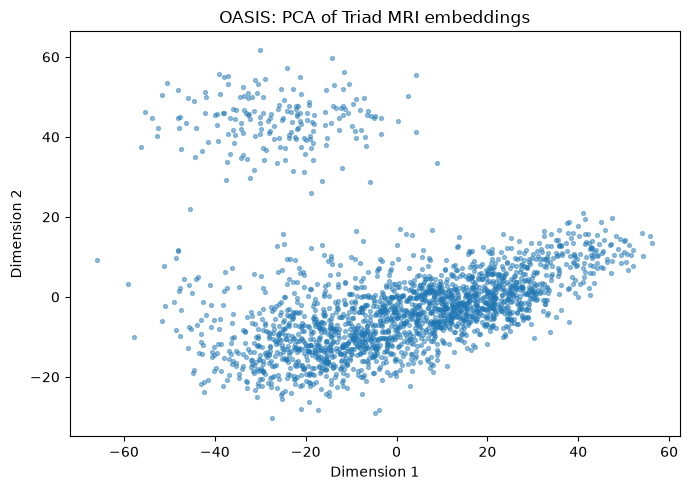

UMAP not installed, skipping.


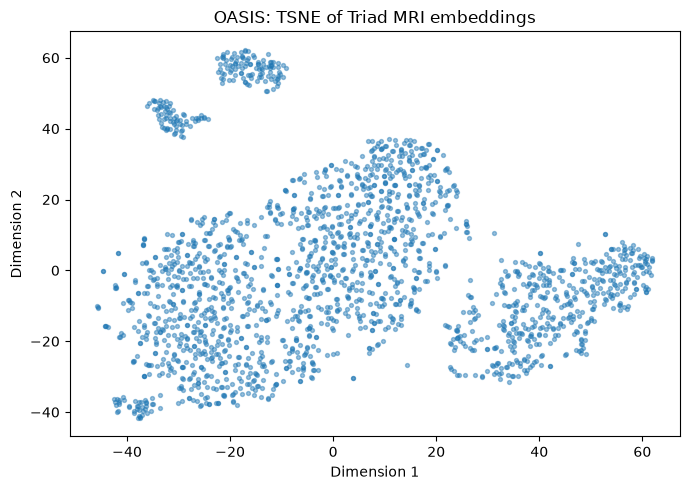

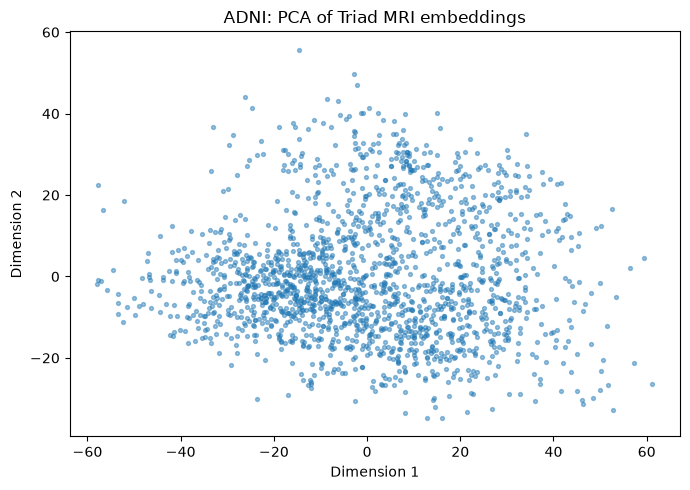

UMAP not installed, skipping.


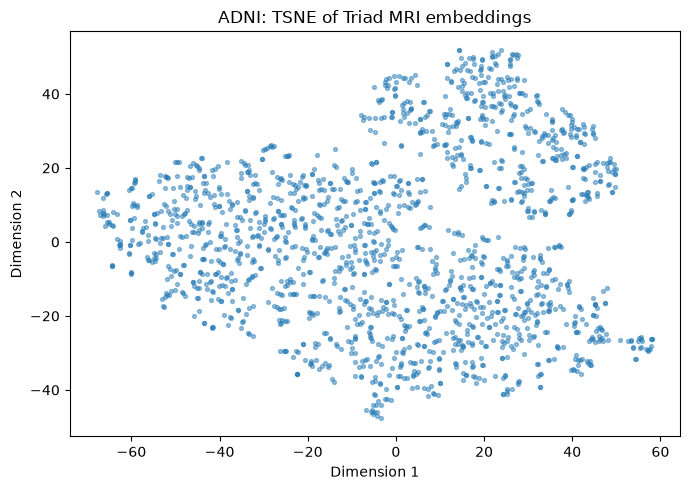

In [14]:
# ============================================================
# 5D. OPTIONAL 2-D EMBEDDING VISUALIZATION
# ============================================================
def plot_2d_embedding(ds, method='pca', max_n=3000):
    X,m=load_all_embeddings(ds)
    rng=np.random.default_rng(SEED)
    if len(X)>max_n:
        idx=rng.choice(len(X),size=max_n,replace=False); X=X[idx]; m=m.iloc[idx].reset_index(drop=True)
    Z=StandardScaler().fit_transform(X)
    if method=='pca':
        Y=PCA(n_components=2,random_state=SEED).fit_transform(Z)
    elif method=='tsne':
        from sklearn.manifold import TSNE
        Y=TSNE(n_components=2,random_state=SEED,init='pca',learning_rate='auto',perplexity=min(30,max(5,len(X)//20))).fit_transform(Z)
    elif method=='umap':
        try:
            import umap
        except Exception:
            print('UMAP not installed, skipping.')
            return
        Y=umap.UMAP(n_components=2,random_state=SEED,n_neighbors=min(30,max(5,len(X)//20)),min_dist=0.1).fit_transform(Z)
    else: raise ValueError(method)
    plt.figure(figsize=(7,5)); plt.scatter(Y[:,0],Y[:,1],s=8,alpha=.45)
    plt.title(f'{ds}: {method.upper()} of Triad MRI embeddings')
    plt.xlabel('Dimension 1'); plt.ylabel('Dimension 2'); plt.tight_layout()
    out=FIG_ROOT/f'{ds}_{method}_embedding_geometry.png'; plt.savefig(out,dpi=220); plt.show()

for ds in datasets:
    plot_2d_embedding(ds,'pca')
    if RUN_UMAP: plot_2d_embedding(ds,'umap')
    if RUN_TSNE: plot_2d_embedding(ds,'tsne',max_n=2000)

# 6. Build the actual trajectory representations for clustering

This is the main new representation-learning section.

We compare four representation families:

**R1: Current MRI embedding**

The most recent MRI embedding at the anchor.

**R2: MRI longitudinal trajectory**

Current embedding + first-to-last embedding change, represented in a locked PCA space.

**R3: MRI + demographics**

MRI longitudinal representation plus age, sex, history length, and observation span.

**R4: Multimodal longitudinal representation**

MRI trajectory + clinical trajectory features, including MMSE/CDR slopes and history structure.

No future outcome is included in any clustering representation.

In [15]:
# ============================================================
# 6. PREPARE SUBJECT-LEVEL REPRESENTATIONS FOR CLUSTERING
# ============================================================
# One row per subject, using the latest eligible prediction anchor.
# Prediction/error signals are retained here so every downstream
# cluster analysis operates on the same subject-level table.

representation_tables={}

prediction_cols=[
    'future_mmse',
    'future_interval_days',
    'future_interval',
    'mmse_change',
    'prediction',
    'clinical_prediction',
    'raw_prediction',
    'prediction_disagreement',
    'uncertainty',
    'abs_error',
    'error',
    'n_mri',
    'n_clinical',
    'mri_gap_days',
    'mri_match_gap_days',
    'mri_history_span_years',
    'clinical_history_span_years'
]

for ds in datasets:

    base=datasets[ds]['test_meta'].copy()

    time_key=(
        'anchor_time'
        if ds=='OASIS'
        else 'anchor_date'
    )

    base=(
        base
        .sort_values(['subject_id',time_key])
        .groupby('subject_id',as_index=False)
        .tail(1)
        .reset_index(drop=True)
    )

    tf=make_subject_anchor_features(
        ds,
        base,
        include_embedding=True,
        pca_model=None
    )

    for c in [
        'anchor_mmse',
        'anchor_age',
        'sex'
    ]+prediction_cols:

        if c in base.columns:
            tf[c]=base[c].to_numpy()

    # Normalize reliability columns.
    if 'error' in tf.columns and 'abs_error' not in tf.columns:
        tf['abs_error']=pd.to_numeric(
            tf['error'],
            errors='coerce'
        ).abs()

    if (
        'prediction_disagreement' not in tf.columns
        and {'raw_prediction','clinical_prediction'}.issubset(tf.columns)
    ):
        tf['prediction_disagreement']=(
            pd.to_numeric(tf['raw_prediction'],errors='coerce')
            -
            pd.to_numeric(tf['clinical_prediction'],errors='coerce')
        ).abs()

    if 'future_interval_days' not in tf.columns and 'future_interval' in tf.columns:
        tf['future_interval_days']=pd.to_numeric(
            tf['future_interval'],
            errors='coerce'
        )

    if 'sex' in tf.columns:
        tf['sex']=tf['sex'].fillna('UNK').astype(str)
    else:
        tf['sex']='UNK'

    representation_tables[ds]=tf

    print(
        ds,
        'subject-level rows:',
        len(tf),
        '| subjects:',
        tf['subject_id'].nunique(),
        '| age available:',
        int(tf['anchor_age'].notna().sum()),
        '| error available:',
        int(tf['abs_error'].notna().sum())
        if 'abs_error' in tf.columns else 0,
        '| disagreement available:',
        int(tf['prediction_disagreement'].notna().sum())
        if 'prediction_disagreement' in tf.columns else 0
    )

if not representation_tables['ADNI']['anchor_age'].notna().all():
    raise RuntimeError(
        'ADNI representation table contains missing locked ages.'
    )


OASIS subject-level rows: 159 | subjects: 159 | age available: 159 | error available: 159 | disagreement available: 159
ADNI subject-level rows: 231 | subjects: 231 | age available: 231 | error available: 231 | disagreement available: 231


In [16]:
# ============================================================
# 6B. REPRESENTATION MATRIX BUILDERS, FIXED
# ============================================================
# The previous version expected emb_current_pcXX / emb_delta_pcXX columns,
# but make_subject_anchor_features() intentionally stores the raw 1488-D
# vectors in _latest_embedding / _delta_embedding. That made `cols=[]` and
# StandardScaler.fit() failed with "at least one array or dtype is required".
#
# This version performs PCA directly on the subject-level embedding arrays
# inside each clustering analysis, then combines the PCA scores with the
# scalar trajectory features. Future outcomes are never used here.

def _stack_embedding_column(df, col):
    arr=[]
    for z in df[col]:
        if z is None:
            arr.append(np.zeros(EXPECTED_EMBED_DIM, dtype=np.float32))
        else:
            z=np.asarray(z, dtype=np.float32).reshape(-1)
            if len(z) != EXPECTED_EMBED_DIM or not np.isfinite(z).all():
                arr.append(np.zeros(EXPECTED_EMBED_DIM, dtype=np.float32))
            else:
                arr.append(z)
    return np.vstack(arr).astype(np.float32)


def _fit_pca_block(df, col, n_pcs=16):
    A=_stack_embedding_column(df,col)
    scaler=StandardScaler()
    Z=scaler.fit_transform(A)
    ncomp=min(n_pcs, Z.shape[0]-1, Z.shape[1])
    if ncomp < 1:
        return np.empty((len(df),0)), [], scaler, None
    pca=PCA(n_components=ncomp, random_state=SEED).fit(Z)
    P=pca.transform(Z)
    names=[f'{col[1:]}_pc{j+1:02d}' for j in range(ncomp)]
    return P, names, scaler, pca


def numeric_matrix(df, cols, scaler=None, fit=True, medians=None):
    cols=[c for c in cols if c in df.columns]
    if not cols:
        raise ValueError('No numeric columns available for representation.')
    X=df[cols].apply(pd.to_numeric,errors='coerce').replace([np.inf,-np.inf],np.nan)
    if medians is None:
        med=X.median(numeric_only=True)
    else:
        med=medians
    X=X.fillna(med).fillna(0.0)
    if X.shape[1] == 0:
        raise ValueError('Representation has zero usable columns.')
    if scaler is None or fit:
        scaler=StandardScaler().fit(X)
    return scaler.transform(X),scaler,med


def build_representation(df, kind, n_pcs=16):
    # --------------------------------------------------------
    # MRI embedding block(s), reduced directly from raw vectors.
    # --------------------------------------------------------
    current, current_names, cur_scaler, cur_pca = _fit_pca_block(df, '_latest_embedding', n_pcs=n_pcs)
    blocks=[]
    names=[]
    if current.shape[1]:
        blocks.append(current)
        names.extend(current_names)

    if kind in ['MRI_trajectory','MRI_demo','Multimodal_trajectory']:
        delta, delta_names, delta_scaler, delta_pca = _fit_pca_block(df, '_delta_embedding', n_pcs=n_pcs)
        if delta.shape[1]:
            blocks.append(delta)
            names.extend(delta_names)
    else:
        delta=np.empty((len(df),0)); delta_names=[]; delta_scaler=None; delta_pca=None

    # --------------------------------------------------------
    # Scalar trajectory / demographic blocks.
    # --------------------------------------------------------
    scalar_cols=[]
    if kind in ['MRI_trajectory','MRI_demo','Multimodal_trajectory']:
        scalar_cols += ['_embedding_speed']
    if kind in ['MRI_demo','Multimodal_trajectory']:
        scalar_cols += [
            'anchor_age','n_mri_hist','n_clin_hist',
            'mri_history_span_years','clinical_history_span_years'
        ]
    if kind == 'Multimodal_trajectory':
        scalar_cols += [
            'mmse_current','mmse_slope_per_year','mmse_sd_hist',
            'cdr_current','cdr_slope_per_year'
        ]

    scalar_scaler=None; scalar_medians=None
    if scalar_cols:
        S,scalar_scaler,scalar_medians=numeric_matrix(df,scalar_cols)
        blocks.append(S)
        names.extend(scalar_cols)

    if not blocks:
        raise ValueError(f'{kind}: no usable representation features.')

    X=np.hstack(blocks).astype(np.float32)
    meta={
        'current_scaler':cur_scaler,
        'current_pca':cur_pca,
        'delta_scaler':delta_scaler,
        'delta_pca':delta_pca,
        'scalar_scaler':scalar_scaler,
        'scalar_medians':scalar_medians,
    }
    return X,names,meta

representation_kinds=['MRI_current','MRI_trajectory','MRI_demo','Multimodal_trajectory']

print('Representation builders fixed: raw 1488-D embeddings -> PCA -> clustering matrix.')

Representation builders fixed: raw 1488-D embeddings -> PCA -> clustering matrix.


# 7. Extensive clustering analysis

For each representation we evaluate K = 2 through 6 using:

- silhouette score,
- within-cluster inertia,
- 100 bootstrap refits and ARI stability,
- 30 random subsample stability checks,
- cluster size balance,
- comparison of KMeans and Gaussian mixture structure,
- descriptive cluster characterization,
- relationship of cluster membership to future error and discordance.

The chosen K is **not** selected from future outcome performance. It is selected from representation stability and geometry, then outcomes are used only for post hoc characterization.

In [17]:
# ============================================================
# 7. CLUSTER STABILITY ENGINE
# ============================================================
def cluster_stability(X, k, seed=SEED, n_boot=N_CLUSTER_BOOTSTRAPS, n_sub=N_CLUSTER_SUBSAMPLES):
    rng=np.random.default_rng(seed+k)
    ref=KMeans(n_clusters=k,random_state=seed,n_init=50).fit(X)
    ref_labels=ref.labels_
    sil=silhouette_score(X,ref_labels) if len(np.unique(ref_labels))>1 else np.nan
    inertia=float(ref.inertia_)
    boot=[]; subs=[]; n=len(X)
    for b in range(n_boot):
        idx=rng.choice(n,size=n,replace=True)
        km=KMeans(n_clusters=k,random_state=seed+1000+b,n_init=20).fit(X[idx])
        boot.append(adjusted_rand_score(ref_labels,km.predict(X)))
    for b in range(n_sub):
        m=max(k*5,int(round(.7*n))); idx=np.sort(rng.choice(n,size=min(m,n),replace=False))
        km=KMeans(n_clusters=k,random_state=seed+2000+b,n_init=20).fit(X[idx])
        subs.append(adjusted_rand_score(ref_labels[idx],km.predict(X[idx])))
    sizes=np.bincount(ref_labels,minlength=k)
    return {
        'k':k,'silhouette':sil,'inertia':inertia,
        'bootstrap_ARI_mean':float(np.mean(boot)),
        'bootstrap_ARI_median':float(np.median(boot)),
        'bootstrap_ARI_q25':float(np.quantile(boot,.25)),
        'bootstrap_ARI_q75':float(np.quantile(boot,.75)),
        'subsample_ARI_mean':float(np.mean(subs)),
        'subsample_ARI_median':float(np.median(subs)),
        'min_cluster_fraction':float(sizes.min()/n),
        'max_cluster_fraction':float(sizes.max()/n)
    }

cluster_summaries=[]; final_cluster_models={}; cluster_assignments={}
for ds in datasets:
    df=representation_tables[ds].copy()
    print('\n' + '='*80)
    print(ds, 'SUBJECT-LEVEL CLUSTERING')
    print('='*80)
    for kind in representation_kinds:
        X,feature_names,rep_meta=build_representation(df,kind)
        print(kind, 'matrix shape:', X.shape)
        rows=[]
        for k in CLUSTER_K_RANGE:
            if len(X)<=k: continue
            try:
                r=cluster_stability(X,k)
                rows.append(r)
            except Exception as e:
                print(ds,kind,'k',k,'failed:',repr(e))
        if not rows:
            raise RuntimeError(f'{ds}/{kind}: no valid K values for clustering.')
        s=pd.DataFrame(rows); s['dataset']=ds; s['representation']=kind; cluster_summaries.append(s)
        best=float(s.bootstrap_ARI_median.max())
        cand=s[s.bootstrap_ARI_median>=.95*best]
        chosen=int(cand.sort_values(['silhouette','k'],ascending=[False,True]).iloc[0].k)
        km=KMeans(n_clusters=chosen,random_state=SEED,n_init=100).fit(X)
        final_cluster_models[(ds,kind)]={
            'model':km,'feature_names':feature_names,
            'representation_meta':rep_meta,'X':X,'chosen_k':chosen
        }
        cluster_assignments[(ds,kind)]=km.labels_
        print(ds,kind,'chosen K=',chosen,'N=',len(df),'cluster sizes=',np.bincount(km.labels_).tolist())
cluster_summary_df=pd.concat(cluster_summaries,ignore_index=True)
display(cluster_summary_df)
cluster_summary_df.to_csv(TABLE_ROOT/'cluster_stability_all_representations.csv',index=False)


OASIS SUBJECT-LEVEL CLUSTERING
MRI_current matrix shape: (159, 16)
OASIS MRI_current chosen K= 3 N= 159 cluster sizes= [70, 69, 20]
MRI_trajectory matrix shape: (159, 33)
OASIS MRI_trajectory chosen K= 4 N= 159 cluster sizes= [29, 23, 87, 20]
MRI_demo matrix shape: (159, 38)
OASIS MRI_demo chosen K= 4 N= 159 cluster sizes= [29, 23, 87, 20]
Multimodal_trajectory matrix shape: (159, 43)
OASIS Multimodal_trajectory chosen K= 4 N= 159 cluster sizes= [29, 23, 87, 20]

ADNI SUBJECT-LEVEL CLUSTERING
MRI_current matrix shape: (231, 16)
ADNI MRI_current chosen K= 3 N= 231 cluster sizes= [91, 60, 80]
MRI_trajectory matrix shape: (231, 33)
ADNI MRI_trajectory chosen K= 2 N= 231 cluster sizes= [108, 123]
MRI_demo matrix shape: (231, 38)
ADNI MRI_demo chosen K= 2 N= 231 cluster sizes= [108, 123]
Multimodal_trajectory matrix shape: (231, 43)
ADNI Multimodal_trajectory chosen K= 2 N= 231 cluster sizes= [108, 123]


,k,silhouette,inertia,bootstrap_ARI_mean,bootstrap_ARI_median,bootstrap_ARI_q25,bootstrap_ARI_q75,subsample_ARI_mean,subsample_ARI_median,min_cluster_fraction,max_cluster_fraction,dataset,representation
0,2,0.259873,146893.781250,0.492715,0.538711,0.098713,0.877396,0.590451,0.826373,0.471698,0.528302,OASIS,MRI_current
1,3,0.292999,103160.640625,0.850416,0.867176,0.780832,0.954326,0.852220,0.828635,0.125786,0.440252,OASIS,MRI_current
2,4,0.232367,88623.843750,0.813133,0.899022,0.717645,0.961293,0.889425,0.946002,0.125786,0.383648,OASIS,MRI_current
3,5,0.232899,80421.828125,0.750935,0.788066,0.559912,0.938164,0.840195,0.931665,0.056604,0.383648,OASIS,MRI_current
4,6,0.206558,73625.046875,0.643823,0.648869,0.509945,0.773305,0.771436,0.799986,0.056604,0.289308,OASIS,MRI_current
5,2,0.176053,338539.375000,0.295849,0.172335,0.066397,0.484109,0.334711,0.415432,0.389937,0.610063,OASIS,MRI_trajectory
6,3,0.298265,282419.937500,0.525622,0.394618,0.332846,0.888017,0.678529,0.684555,0.125786,0.685535,OASIS,MRI_trajectory
7,4,0.295748,236438.812500,0.808940,0.920314,0.661943,0.956348,0.893899,0.947169,0.125786,0.547170,OASIS,MRI_trajectory
8,5,0.209915,208832.578125,0.738743,0.741429,0.571009,0.894208,0.839693,0.914769,0.125786,0.308176,OASIS,MRI_trajectory
9,6,0.226036,188023.265625,0.846810,0.872167,0.810922,0.919893,0.873690,0.878140,0.075472,0.314465,OASIS,MRI_trajectory


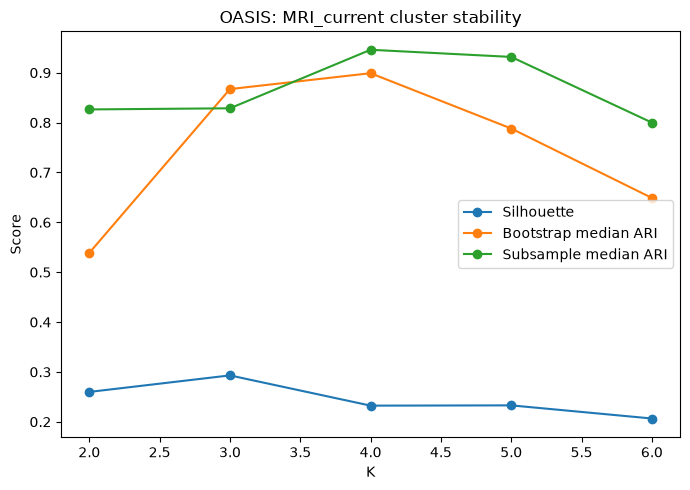

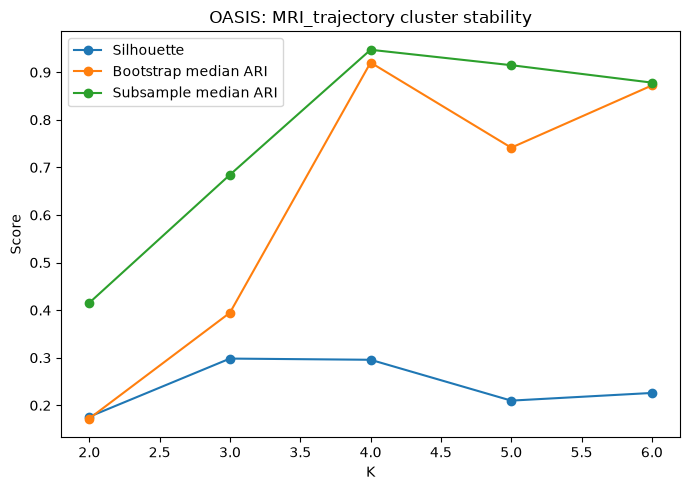

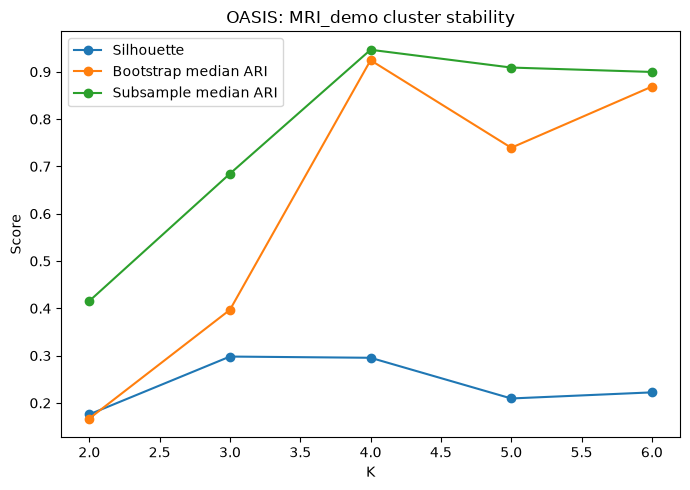

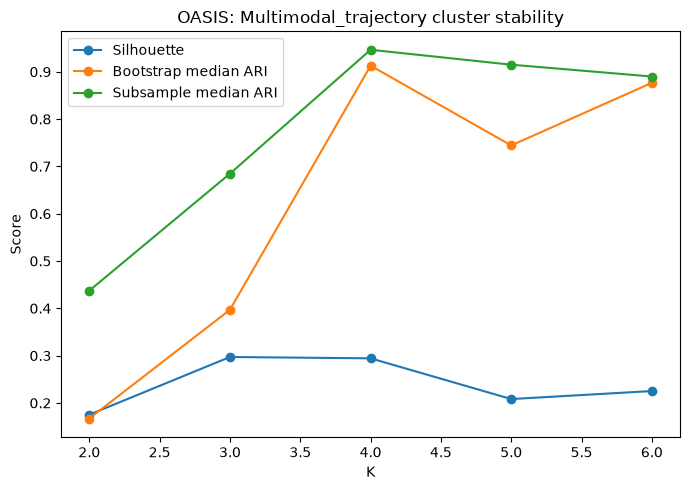

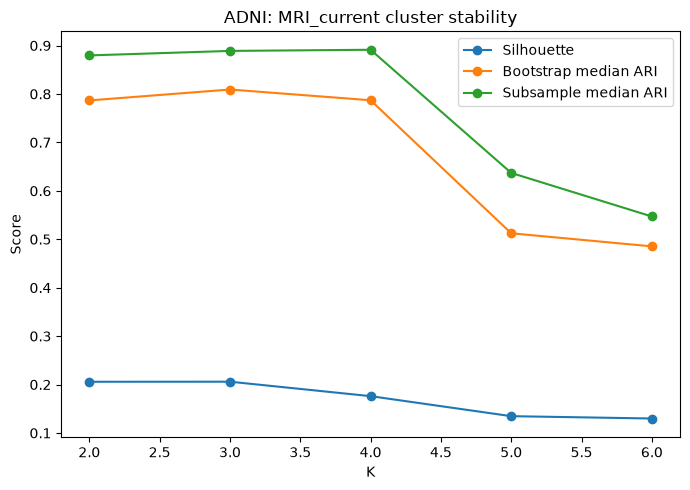

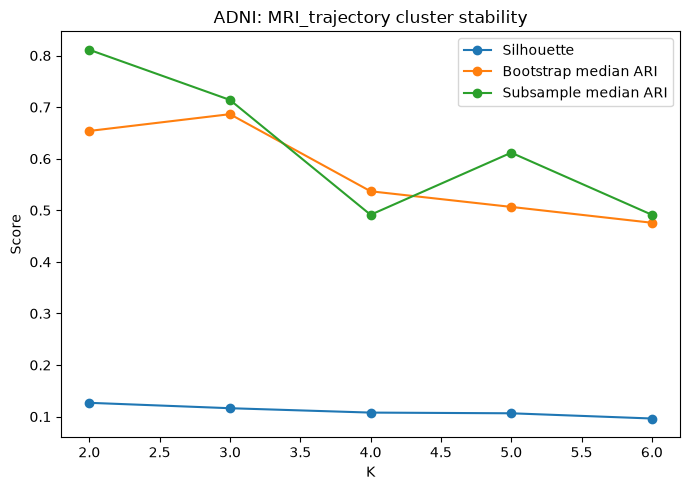

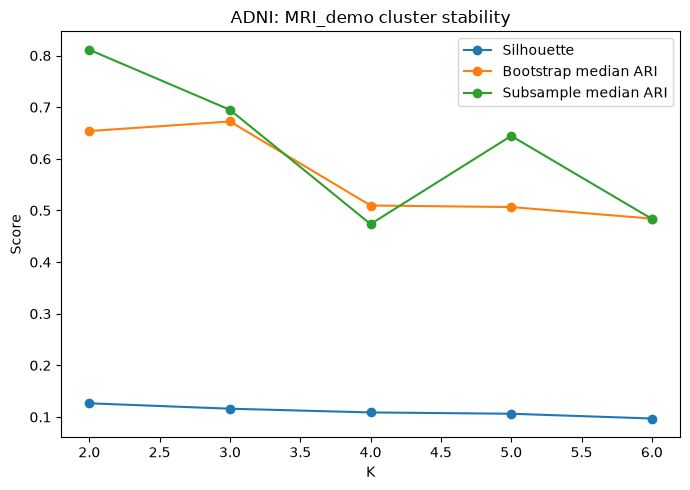

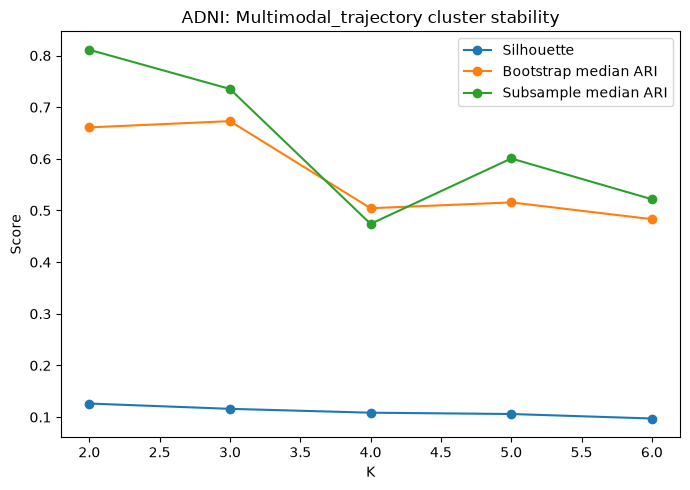

In [18]:
# ============================================================
# 7B. VISUALIZE CLUSTER QUALITY
# ============================================================
for ds in datasets:
    for kind in representation_kinds:
        d=cluster_summary_df[(cluster_summary_df.dataset==ds)&(cluster_summary_df.representation==kind)].copy()
        if d.empty: continue
        plt.figure(figsize=(7,5))
        plt.plot(d.k,d.silhouette,marker='o',label='Silhouette')
        plt.plot(d.k,d.bootstrap_ARI_median,marker='o',label='Bootstrap median ARI')
        plt.plot(d.k,d.subsample_ARI_median,marker='o',label='Subsample median ARI')
        plt.xlabel('K'); plt.ylabel('Score'); plt.title(f'{ds}: {kind} cluster stability'); plt.legend(); plt.tight_layout()
        out=FIG_ROOT/f'{ds}_{kind}_cluster_quality.png'; plt.savefig(out,dpi=220); plt.show()

In [19]:
# ============================================================
# 7C. CLUSTER CHARACTERIZATION
# ============================================================

cluster_characterizations = []

for ds in datasets:

    df0 = representation_tables[ds].copy()

    for kind in representation_kinds:

        labels = cluster_assignments[(ds, kind)]

        if len(labels) != len(df0):
            raise RuntimeError(
                f'{ds}/{kind}: labels={len(labels)}, '
                f'rows={len(df0)}'
            )

        df = df0.copy()
        df['cluster'] = labels

        summary = (
            df.groupby('cluster')
            .agg(
                N=('subject_id', 'size'),
                subjects=('subject_id', 'nunique'),
                anchor_mmse=('anchor_mmse', 'mean'),
                anchor_age=('anchor_age', 'mean'),
                n_mri_hist=('n_mri_hist', 'mean'),
                n_clin_hist=('n_clin_hist', 'mean'),
                mri_history_span_years=(
                    'mri_history_span_years',
                    'mean'
                ),
                clinical_history_span_years=(
                    'clinical_history_span_years',
                    'mean'
                ),
                mmse_slope=(
                    'mmse_slope_per_year',
                    'mean'
                ),
                cdr_slope=(
                    'cdr_slope_per_year',
                    'mean'
                ),
                embedding_speed=(
                    '_embedding_speed',
                    'mean'
                )
            )
            .reset_index()
        )

        for c in [
            'abs_error',
            'prediction_disagreement',
            'uncertainty',
            'future_interval_days',
            'future_mmse',
            'mmse_change'
        ]:
            if c in df.columns:
                summary[c] = (
                    df.groupby('cluster')[c]
                    .mean()
                    .reindex(summary['cluster'])
                    .to_numpy()
                )

        for signal in [
            'abs_error',
            'prediction_disagreement',
            'uncertainty'
        ]:
            if signal not in df.columns:
                continue

            x = pd.to_numeric(
                df[signal],
                errors='coerce'
            )

            thr = x.quantile(.75)

            if not np.isfinite(thr):
                continue

            summary[
                f'{signal}_top_quartile_rate'
            ] = (
                df.assign(_event=x >= thr)
                .groupby('cluster')['_event']
                .mean()
                .reindex(summary['cluster'])
                .to_numpy()
            )

        summary['dataset'] = ds
        summary['representation'] = kind
        cluster_characterizations.append(summary)

cluster_characterization_df = pd.concat(
    cluster_characterizations,
    ignore_index=True
)

display(cluster_characterization_df)

cluster_characterization_df.to_csv(
    TABLE_ROOT / 'cluster_characterization.csv',
    index=False
)


,cluster,N,subjects,anchor_mmse,anchor_age,n_mri_hist,n_clin_hist,mri_history_span_years,clinical_history_span_years,mmse_slope,...,prediction_disagreement,uncertainty,future_interval_days,future_mmse,mmse_change,abs_error_top_quartile_rate,prediction_disagreement_top_quartile_rate,uncertainty_top_quartile_rate,dataset,representation
0,0,70,70,28.114286,75.030000,1.928571,5.057143,2.608194,4.961768,-0.134399,...,1.721124,0.438263,394.700000,27.628571,-0.485714,0.328571,0.342857,0.242857,OASIS,MRI_current
1,1,69,69,28.782609,74.690870,2.521739,5.449275,3.417909,5.259213,-0.004619,...,1.120465,0.407834,394.391304,28.086957,-0.695652,0.202899,0.202899,0.246377,OASIS,MRI_current
2,2,20,20,28.250000,79.998000,1.500000,8.500000,1.087201,8.568925,-0.305899,...,1.169464,0.407299,380.100000,28.400000,0.150000,0.150000,0.100000,0.300000,OASIS,MRI_current
3,0,29,29,28.689655,77.209655,3.206897,8.931034,5.582195,9.426609,-0.005492,...,0.834134,0.366053,404.034483,28.586207,-0.103448,0.241379,0.172414,0.068966,OASIS,MRI_trajectory
4,1,23,23,29.434783,73.576957,3.434783,5.826087,5.107877,6.043151,0.148389,...,0.615585,0.317779,381.739130,29.000000,-0.434783,0.130435,0.086957,0.130435,OASIS,MRI_trajectory
5,2,87,87,28.103448,74.418621,1.574713,3.873563,1.598213,3.423509,-0.151273,...,1.832671,0.470051,394.770115,27.310345,-0.793103,0.310345,0.356322,0.333333,OASIS,MRI_trajectory
6,3,20,20,28.250000,79.998000,1.500000,8.500000,1.087201,8.568925,-0.305899,...,1.169464,0.407299,380.100000,28.400000,0.150000,0.150000,0.100000,0.300000,OASIS,MRI_trajectory
7,0,29,29,28.689655,77.209655,3.206897,8.931034,5.582195,9.426609,-0.005492,...,0.834134,0.366053,404.034483,28.586207,-0.103448,0.241379,0.172414,0.068966,OASIS,MRI_demo
8,1,23,23,29.434783,73.576957,3.434783,5.826087,5.107877,6.043151,0.148389,...,0.615585,0.317779,381.739130,29.000000,-0.434783,0.130435,0.086957,0.130435,OASIS,MRI_demo
9,2,87,87,28.103448,74.418621,1.574713,3.873563,1.598213,3.423509,-0.151273,...,1.832671,0.470051,394.770115,27.310345,-0.793103,0.310345,0.356322,0.333333,OASIS,MRI_demo


# 8. A lot more analysis of the embedding clusters

The previous section asks whether clusters are stable. This section asks what those stable groups actually mean.

We examine:

1. Clinical trajectory separation.
2. MRI trajectory speed.
3. Current cognitive state.
4. Brain-versus-cognition discordance.
5. Prediction error.
6. Uncertainty.
7. Cluster size and imbalance.
8. Cross-representation agreement using ARI.
9. Subject-level consistency across different representations.
10. Whether high-error cases concentrate in particular embedding clusters.

In [20]:
# ============================================================
# 8. CROSS-REPRESENTATION CLUSTER AGREEMENT
# ============================================================
agreement_rows=[]
for ds in datasets:
    kinds=representation_kinds
    for i,a in enumerate(kinds):
        for b in kinds[i+1:]:
            la=cluster_assignments[(ds,a)]; lb=cluster_assignments[(ds,b)]
            agreement_rows.append({'dataset':ds,'representation_a':a,'representation_b':b,'ARI':adjusted_rand_score(la,lb)})
agreement_df=pd.DataFrame(agreement_rows)
display(agreement_df)
agreement_df.to_csv(TABLE_ROOT/'cluster_representation_agreement.csv',index=False)

,dataset,representation_a,representation_b,ARI
0,OASIS,MRI_current,MRI_trajectory,0.244763
1,OASIS,MRI_current,MRI_demo,0.244763
2,OASIS,MRI_current,Multimodal_trajectory,0.244763
3,OASIS,MRI_trajectory,MRI_demo,1.000000
4,OASIS,MRI_trajectory,Multimodal_trajectory,1.000000
5,OASIS,MRI_demo,Multimodal_trajectory,1.000000
6,ADNI,MRI_current,MRI_trajectory,0.326458
7,ADNI,MRI_current,MRI_demo,0.326458
8,ADNI,MRI_current,Multimodal_trajectory,0.326458
9,ADNI,MRI_trajectory,MRI_demo,1.000000


In [21]:
# ============================================================
# 8B. CLUSTER PROFILES OF STANDARDIZED SUBJECT FEATURES
# ============================================================

profile_rows = []

profile_cols = [
    'anchor_mmse',
    'anchor_age',
    'n_mri_hist',
    'n_clin_hist',
    'mri_history_span_years',
    'clinical_history_span_years',
    'mmse_slope_per_year',
    'cdr_slope_per_year',
    '_embedding_speed',
    'prediction_disagreement',
    'uncertainty',
    'abs_error'
]

for ds in datasets:

    df = representation_tables[ds].copy()

    for kind in representation_kinds:

        x = df.copy()
        x['cluster'] = cluster_assignments[
            (ds, kind)
        ]

        cols = [
            c for c in profile_cols
            if c in x.columns
        ]

        z = x[cols].apply(
            pd.to_numeric,
            errors='coerce'
        )

        mu = z.mean()
        sd = z.std(ddof=0)

        sd = sd.mask(
            sd.isna() | sd.eq(0),
            1.0
        )

        z = (z - mu) / sd
        z['cluster'] = x['cluster']

        p = (
            z.groupby('cluster')
            .mean(numeric_only=True)
            .reset_index()
        )

        p.insert(0, 'representation', kind)
        p.insert(0, 'dataset', ds)

        profile_rows.append(p)

profile_df = pd.concat(
    profile_rows,
    ignore_index=True
)

display(profile_df)

profile_df.to_csv(
    TABLE_ROOT / 'cluster_standardized_profiles.csv',
    index=False
)


,dataset,representation,cluster,anchor_mmse,anchor_age,n_mri_hist,n_clin_hist,mri_history_span_years,clinical_history_span_years,mmse_slope_per_year,cdr_slope_per_year,_embedding_speed,prediction_disagreement,uncertainty,abs_error
0,OASIS,MRI_current,0,-0.128032,-0.065695,-0.146639,-0.135838,-0.057005,-0.117181,-0.038207,-0.143777,-0.045937,0.190404,0.071714,0.059478
1,OASIS,MRI_current,1,0.150599,-0.112329,0.280781,-0.047536,0.231362,-0.057376,0.099862,0.059473,-0.028369,-0.156108,-0.055900,-0.004604
2,OASIS,MRI_current,2,-0.071452,0.617467,-0.455456,0.639432,-0.598682,0.608082,-0.220658,0.301718,0.312489,-0.127841,-0.058143,-0.192287
3,OASIS,MRI_trajectory,0,0.111845,0.234035,0.774486,0.736494,1.002138,0.780529,0.098933,0.104970,0.199389,-0.321289,-0.231122,-0.123844
4,OASIS,MRI_trajectory,1,0.422497,-0.265506,0.938694,0.037315,0.833217,0.100244,0.262641,-0.131663,0.197994,-0.447368,-0.433577,-0.128564
5,OASIS,MRI_trajectory,2,-0.132551,-0.149767,-0.401620,-0.402359,-0.416694,-0.426467,-0.056158,-0.068435,-0.378944,0.254755,0.205031,0.119474
6,OASIS,MRI_trajectory,3,-0.071452,0.617467,-0.455456,0.639432,-0.598682,0.608082,-0.220658,0.301718,0.312489,-0.127841,-0.058143,-0.192287
7,OASIS,MRI_demo,0,0.111845,0.234035,0.774486,0.736494,1.002138,0.780529,0.098933,0.104970,0.199389,-0.321289,-0.231122,-0.123844
8,OASIS,MRI_demo,1,0.422497,-0.265506,0.938694,0.037315,0.833217,0.100244,0.262641,-0.131663,0.197994,-0.447368,-0.433577,-0.128564
9,OASIS,MRI_demo,2,-0.132551,-0.149767,-0.401620,-0.402359,-0.416694,-0.426467,-0.056158,-0.068435,-0.378944,0.254755,0.205031,0.119474


In [22]:
# ============================================================
# 8C. EMBEDDING SPEED AND FAST/SLOW MRI TRAJECTORIES
# ============================================================
fastslow_rows=[]

for ds in datasets:

    df=representation_tables[ds].copy()
    s=pd.to_numeric(
        df['_embedding_speed'],
        errors='coerce'
    )

    valid=s.notna()

    if valid.sum()<2:
        continue

    q50=float(s[valid].median())

    df=df.loc[valid].copy()
    df['embedding_speed']=s.loc[valid]
    df['embedding_speed_group']=np.where(
        df['embedding_speed']>=q50,
        'fast',
        'slow'
    )

    for g,dd in df.groupby('embedding_speed_group'):

        fastslow_rows.append({
            'dataset':ds,
            'speed_group':g,
            'N':len(dd),
            'mean_anchor_mmse':float(
                pd.to_numeric(
                    dd['anchor_mmse'],
                    errors='coerce'
                ).mean()
            ),
            'mean_mmse_slope':float(
                pd.to_numeric(
                    dd['mmse_slope_per_year'],
                    errors='coerce'
                ).mean()
            ),
            'mean_embedding_speed':float(
                dd['embedding_speed'].mean()
            ),
            'mean_error':float(
                pd.to_numeric(
                    dd['abs_error'],
                    errors='coerce'
                ).mean()
            ) if 'abs_error' in dd.columns else np.nan,
            'mean_prediction_disagreement':float(
                pd.to_numeric(
                    dd['prediction_disagreement'],
                    errors='coerce'
                ).mean()
            ) if 'prediction_disagreement' in dd.columns else np.nan
        })

fastslow_df=pd.DataFrame(fastslow_rows)

display(fastslow_df)

fastslow_df.to_csv(
    TABLE_ROOT/'fast_slow_embedding_trajectory_summary.csv',
    index=False
)


,dataset,speed_group,N,mean_anchor_mmse,mean_mmse_slope,mean_embedding_speed,mean_error,mean_prediction_disagreement
0,OASIS,fast,48,29.020833,0.059529,2.289094,0.964861,0.762389
1,OASIS,slow,48,28.812500,0.001463,0.609296,1.418882,1.098262
2,ADNI,fast,115,24.513043,-1.448242,3.289552,2.012851,4.277631
3,ADNI,slow,114,25.921053,-0.476958,0.724384,1.818372,3.626793


In [23]:
# ============================================================
# 8D. HIGH-DISCORDANCE / HIGH-ERROR CONCENTRATION BY CLUSTER
# ============================================================
# Use the exact subject-level representation table that generated
# the cluster labels. This guarantees 1:1 row alignment.

cluster_failure_rows=[]

for ds in datasets:

    df0=representation_tables[ds].copy()

    for kind in representation_kinds:

        labels=cluster_assignments.get((ds,kind))

        if labels is None:
            continue

        if len(labels)!=len(df0):
            raise RuntimeError(
                f'{ds}/{kind}: cluster labels ({len(labels)}) '
                f'do not match representation rows ({len(df0)}).'
            )

        d=df0.copy()
        d['cluster']=labels

        for signal in [
            'abs_error',
            'prediction_disagreement',
            'uncertainty'
        ]:

            if signal not in d.columns:
                continue

            x=pd.to_numeric(
                d[signal],
                errors='coerce'
            )

            valid=x.notna()

            if valid.sum()<10:
                continue

            threshold=float(x[valid].quantile(0.75))

            overall_rate=float(
                (x[valid]>=threshold).mean()
            )

            for cl,g in d.groupby('cluster'):

                gv=pd.to_numeric(
                    g[signal],
                    errors='coerce'
                )

                gv=gv[gv.notna()]

                if len(gv)==0:
                    continue

                event_count=int(
                    (gv>=threshold).sum()
                )

                cluster_rate=float(
                    event_count/len(gv)
                )

                enrichment=(
                    cluster_rate/overall_rate
                    if overall_rate>0
                    else np.nan
                )

                cluster_failure_rows.append({
                    'dataset':ds,
                    'representation':kind,
                    'cluster':int(cl),
                    'signal':signal,
                    'N':int(len(gv)),
                    'threshold':threshold,
                    'event_count':event_count,
                    'event_rate':cluster_rate,
                    'overall_event_rate':overall_rate,
                    'enrichment':enrichment
                })

cluster_failure_df=pd.DataFrame(cluster_failure_rows)

if cluster_failure_df.empty:
    raise RuntimeError(
        'cluster_failure_df is empty. '
        'Check that representation_tables contain the reliability signals.'
    )

display(cluster_failure_df.head(100))

print(
    'cluster_failure_df rows:',
    len(cluster_failure_df)
)

cluster_failure_df.to_csv(
    TABLE_ROOT/'cluster_failure_enrichment.csv',
    index=False
)


,dataset,representation,cluster,signal,N,threshold,event_count,event_rate,overall_event_rate,enrichment
0,OASIS,MRI_current,0,abs_error,70,1.647218,23,0.328571,0.251572,1.306071
1,OASIS,MRI_current,1,abs_error,69,1.647218,14,0.202899,0.251572,0.806522
2,OASIS,MRI_current,2,abs_error,20,1.647218,3,0.150000,0.251572,0.596250
3,OASIS,MRI_current,0,prediction_disagreement,70,1.819889,24,0.342857,0.251572,1.362857
4,OASIS,MRI_current,1,prediction_disagreement,69,1.819889,14,0.202899,0.251572,0.806522
...,...,...,...,...,...,...,...,...,...,...
67,ADNI,Multimodal_trajectory,1,abs_error,123,2.474485,29,0.235772,0.251082,0.939024
68,ADNI,Multimodal_trajectory,0,prediction_disagreement,108,6.356654,30,0.277778,0.251082,1.106322
69,ADNI,Multimodal_trajectory,1,prediction_disagreement,123,6.356654,28,0.227642,0.251082,0.906644
70,ADNI,Multimodal_trajectory,0,uncertainty,108,0.682742,32,0.296296,0.251082,1.180077


cluster_failure_df rows: 72


In [24]:
# ============================================================
# 8E. BLOCK-BALANCED CLUSTERING ABLATION
# ============================================================
# Controls MRI dimensional dominance by equalizing the RMS contribution
# of the MRI, demographic, and clinical blocks.

BALANCED_PCS = 8

def fit_pca_block(A, n_components=BALANCED_PCS):
    A = np.asarray(A, dtype=float)
    sc = StandardScaler()
    Z = sc.fit_transform(A)
    ncomp = min(
        n_components,
        Z.shape[0] - 1,
        Z.shape[1]
    )
    if ncomp < 1:
        return np.zeros((len(A), 0)), sc, None
    pca = PCA(
        n_components=ncomp,
        random_state=SEED
    ).fit(Z)
    return pca.transform(Z), sc, pca


def equalize_block(X):
    X = np.asarray(X, dtype=float)
    if X.shape[1] == 0:
        return X
    rms = float(np.sqrt(np.mean(X ** 2)))
    if not np.isfinite(rms) or rms == 0:
        return np.zeros_like(X)
    return X / rms


def balanced_subject_matrix(df, kind):
    cur = _stack_embedding_column(
        df,
        '_latest_embedding'
    )
    cur_pc, _, _ = fit_pca_block(cur)
    blocks = [equalize_block(cur_pc)]

    if kind in [
        'MRI_trajectory',
        'MRI_demo',
        'Multimodal_trajectory'
    ]:
        delta = _stack_embedding_column(
            df,
            '_delta_embedding'
        )
        delta_pc, _, _ = fit_pca_block(delta)
        blocks.append(equalize_block(delta_pc))

    if kind in [
        'MRI_demo',
        'Multimodal_trajectory'
    ]:
        demo_cols = [
            '_embedding_speed',
            'anchor_age',
            'n_mri_hist',
            'n_clin_hist',
            'mri_history_span_years',
            'clinical_history_span_years'
        ]
        S, _, _ = numeric_matrix(df, demo_cols)
        blocks.append(equalize_block(S))

    if kind == 'Multimodal_trajectory':
        clinical_cols = [
            'mmse_current',
            'mmse_slope_per_year',
            'mmse_sd_hist',
            'cdr_current',
            'cdr_slope_per_year'
        ]
        C, _, _ = numeric_matrix(df, clinical_cols)
        blocks.append(equalize_block(C))

    return np.hstack(
        [b for b in blocks if b.shape[1] > 0]
    ).astype(np.float32)


balanced_cluster_rows = []
balanced_cluster_assignments = {}
balanced_cluster_models = {}

for ds in datasets:

    df = representation_tables[ds].copy()

    for kind in representation_kinds:

        X = balanced_subject_matrix(df, kind)
        quality_rows = []

        for k in CLUSTER_K_RANGE:

            if k >= len(X):
                continue

            km = KMeans(
                n_clusters=k,
                random_state=SEED,
                n_init=50
            )
            lab = km.fit_predict(X)

            stab = cluster_stability(
                X,
                k,
                n_boot=60,
                n_sub=20
            )

            stab['calinski_harabasz'] = float(
                calinski_harabasz_score(X, lab)
            )
            stab['davies_bouldin'] = float(
                davies_bouldin_score(X, lab)
            )
            stab['dataset'] = ds
            stab['representation'] = kind
            quality_rows.append(stab)

        qs = pd.DataFrame(quality_rows)

        if qs.empty:
            continue

        best = qs['bootstrap_ARI_median'].max()

        eligible = qs[
            qs['bootstrap_ARI_median']
            >= 0.95 * best
        ]

        kk = int(
            eligible
            .sort_values(
                ['silhouette', 'k'],
                ascending=[False, True]
            )
            .iloc[0]['k']
        )

        km = KMeans(
            n_clusters=kk,
            random_state=SEED,
            n_init=100
        ).fit(X)

        balanced_cluster_assignments[
            (ds, kind)
        ] = km.labels_

        balanced_cluster_models[
            (ds, kind)
        ] = {
            'k': kk,
            'model': km,
            'quality': qs
        }

        qs['selected'] = (
            qs['k'].astype(int) == kk
        )

        balanced_cluster_rows.append(qs)

balanced_cluster_df = pd.concat(
    balanced_cluster_rows,
    ignore_index=True
)

display(balanced_cluster_df)

balanced_cluster_df.to_csv(
    TABLE_ROOT / 'block_balanced_cluster_quality.csv',
    index=False
)

balanced_agreement_rows = []

for ds in datasets:
    for kind in representation_kinds:
        balanced_agreement_rows.append({
            'dataset': ds,
            'representation': kind,
            'ARI_naive_vs_balanced': float(
                adjusted_rand_score(
                    cluster_assignments[(ds, kind)],
                    balanced_cluster_assignments[(ds, kind)]
                )
            ),
            'N': len(
                cluster_assignments[(ds, kind)]
            )
        })

balanced_agreement_df = pd.DataFrame(
    balanced_agreement_rows
)

display(balanced_agreement_df)

balanced_agreement_df.to_csv(
    TABLE_ROOT /
    'naive_vs_block_balanced_cluster_agreement.csv',
    index=False
)


,k,silhouette,inertia,bootstrap_ARI_mean,bootstrap_ARI_median,bootstrap_ARI_q25,bootstrap_ARI_q75,subsample_ARI_mean,subsample_ARI_median,min_cluster_fraction,max_cluster_fraction,calinski_harabasz,davies_bouldin,dataset,representation,selected
0,2,0.291620,875.551636,0.462281,0.322819,0.098713,0.859722,0.601685,0.876819,0.471698,0.528302,71.089345,1.375884,OASIS,MRI_current,False
1,3,0.337522,571.644104,0.846796,0.867176,0.776020,0.932018,0.871837,0.873925,0.125786,0.440252,95.562526,1.055770,OASIS,MRI_current,False
2,4,0.276737,473.842102,0.829154,0.931127,0.702389,0.961486,0.933869,0.969261,0.125786,0.377358,87.029325,1.134832,OASIS,MRI_current,False
3,5,0.278714,419.660889,0.799759,0.905693,0.663651,0.963615,0.806061,0.916882,0.056604,0.377358,78.194234,1.170201,OASIS,MRI_current,True
4,6,0.253715,374.628571,0.685197,0.687692,0.534102,0.847457,0.772482,0.785690,0.056604,0.289308,73.298093,1.260906,OASIS,MRI_current,False
5,2,0.265864,2052.736816,0.414519,0.332556,0.290541,0.538484,0.507465,0.389060,0.264151,0.735849,37.573408,1.771903,OASIS,MRI_trajectory,False
6,3,0.325830,1661.064697,0.560582,0.418009,0.347935,0.935018,0.569626,0.416377,0.125786,0.672956,41.460724,1.414094,OASIS,MRI_trajectory,False
7,4,0.332555,1339.440186,0.804455,0.917036,0.609545,0.953602,0.856583,0.945013,0.125786,0.547170,46.463883,1.233680,OASIS,MRI_trajectory,True
8,5,0.258697,1150.512451,0.738517,0.760760,0.582015,0.879366,0.795687,0.834397,0.125786,0.333333,46.630750,1.177202,OASIS,MRI_trajectory,False
9,6,0.276739,1002.633972,0.852294,0.885833,0.778636,0.918335,0.888647,0.905667,0.075472,0.308176,47.041896,1.166690,OASIS,MRI_trajectory,False


,dataset,representation,ARI_naive_vs_balanced,N
0,OASIS,MRI_current,0.448274,159
1,OASIS,MRI_trajectory,1.000000,159
2,OASIS,MRI_demo,0.872936,159
3,OASIS,Multimodal_trajectory,0.782159,159
4,ADNI,MRI_current,1.000000,231
5,ADNI,MRI_trajectory,0.711350,231
6,ADNI,MRI_demo,0.427948,231
7,ADNI,Multimodal_trajectory,0.253413,231


In [25]:
# ============================================================
# 8F. DEEP CLUSTER PHENOTYPE / PREDICTIVE PHENOTYPE ANALYSIS
# ============================================================
# Clusters are treated as an ML representation probe, not as proven
# biological subtypes.

def eta_squared_between(
    df,
    value_col,
    cluster_col='cluster'
):
    x = pd.to_numeric(
        df[value_col],
        errors='coerce'
    )

    valid = (
        x.notna()
        & df[cluster_col].notna()
    )

    if valid.sum() < 10:
        return np.nan

    x = x[valid]
    g = df.loc[valid, cluster_col]
    grand = x.mean()

    ss_total = float(
        ((x - grand) ** 2).sum()
    )

    if ss_total <= 0:
        return 0.0

    ss_between = 0.0

    for _, vals in x.groupby(g):
        ss_between += (
            len(vals)
            * (vals.mean() - grand) ** 2
        )

    return float(
        ss_between / ss_total
    )


deep_rows = []

variables = [
    'anchor_mmse',
    'anchor_age',
    'n_mri_hist',
    'n_clin_hist',
    'mri_history_span_years',
    'clinical_history_span_years',
    'mmse_slope_per_year',
    'cdr_slope_per_year',
    '_embedding_speed',
    'abs_error',
    'prediction_disagreement',
    'uncertainty'
]

for ds in datasets:

    df0 = representation_tables[ds].copy()

    for kind in representation_kinds:

        df = df0.copy()
        df['cluster'] = cluster_assignments[
            (ds, kind)
        ]

        allq = cluster_summary_df[
    (cluster_summary_df.dataset == ds)
    &
    (cluster_summary_df.representation == kind)
].copy()

        if allq.empty:
            continue

        best = allq['bootstrap_ARI_median'].max()

        q = allq[
    allq['bootstrap_ARI_median'] >= 0.95 * best
].sort_values(
    ['silhouette', 'k'],
    ascending=[False, True]
)

        if q.empty:
            continue

        k = int(q.iloc[0]['k'])

        for var in variables:

            if var not in df.columns:
                continue

            x = pd.to_numeric(
                df[var],
                errors='coerce'
            )

            groups = [
                pd.to_numeric(
                    g[var],
                    errors='coerce'
                ).dropna().to_numpy()
                for _, g in df.groupby('cluster')
            ]

            groups = [
                g for g in groups
                if len(g) >= 3
            ]

            if len(groups) >= 2:
                try:
                    kw_stat, kw_p = kruskal(*groups)
                except Exception:
                    kw_stat, kw_p = np.nan, np.nan
            else:
                kw_stat, kw_p = np.nan, np.nan

            deep_rows.append({
                'dataset': ds,
                'representation': kind,
                'k': k,
                'variable': var,
                'N': int(x.notna().sum()),
                'mean': float(x.mean())
                if x.notna().any()
                else np.nan,
                'std': float(x.std())
                if x.notna().sum() > 1
                else np.nan,
                'eta_squared': eta_squared_between(
                    df,
                    var
                ),
                'kruskal_stat': (
                    float(kw_stat)
                    if np.isfinite(kw_stat)
                    else np.nan
                ),
                'kruskal_p': (
                    float(kw_p)
                    if np.isfinite(kw_p)
                    else np.nan
                )
            })

deep_cluster_df = pd.DataFrame(
    deep_rows
)

display(
    deep_cluster_df.sort_values(
        ['dataset','representation','eta_squared'],
        ascending=[True,True,False]
    )
)

deep_cluster_df.to_csv(
    TABLE_ROOT /
    'deep_cluster_phenotype_analysis.csv',
    index=False
)


,dataset,representation,k,variable,N,mean,std,eta_squared,kruskal_stat,kruskal_p
57,ADNI,MRI_current,3,abs_error,231,1.903807,1.966831,0.015253,1.335406,0.512885
55,ADNI,MRI_current,3,cdr_slope_per_year,226,0.652983,1.060744,0.013071,1.080383,0.582637
49,ADNI,MRI_current,3,anchor_age,231,77.060606,7.402453,0.012986,2.200458,0.332795
51,ADNI,MRI_current,3,n_clin_hist,231,4.779221,1.815082,0.010566,2.897358,0.234880
54,ADNI,MRI_current,3,mmse_slope_per_year,231,-0.952852,2.325105,0.008103,0.013191,0.993426
...,...,...,...,...,...,...,...,...,...,...
47,OASIS,Multimodal_trajectory,4,uncertainty,159,0.421163,0.239197,0.060363,8.806148,0.031982
36,OASIS,Multimodal_trajectory,4,anchor_mmse,159,28.421384,2.406173,0.038359,7.758481,0.051276
42,OASIS,Multimodal_trajectory,4,mmse_slope_per_year,155,-0.098486,0.943019,0.019745,7.114936,0.068323
43,OASIS,Multimodal_trajectory,4,cdr_slope_per_year,155,0.040058,0.367240,0.018331,9.293192,0.025636


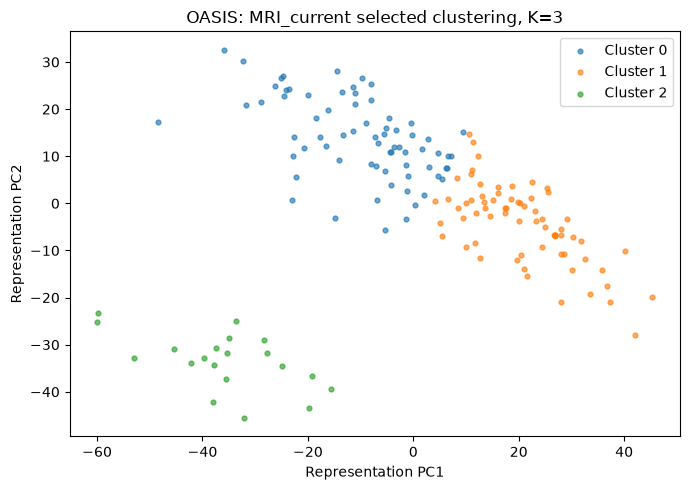

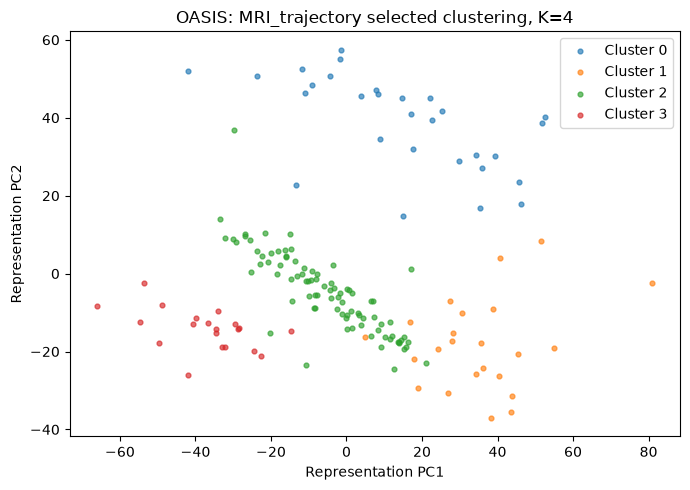

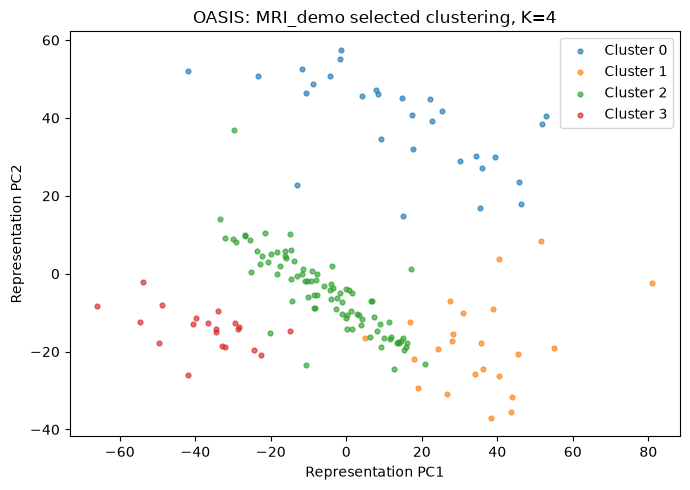

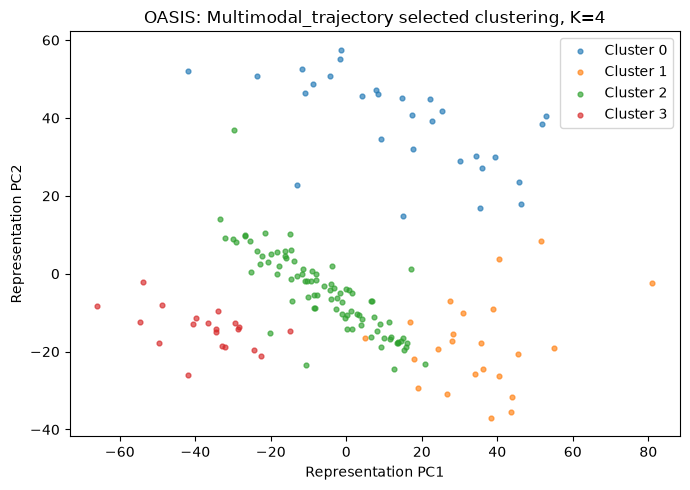

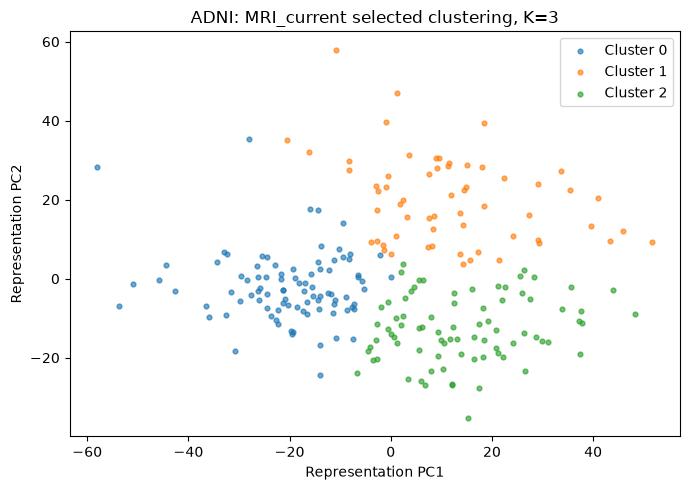

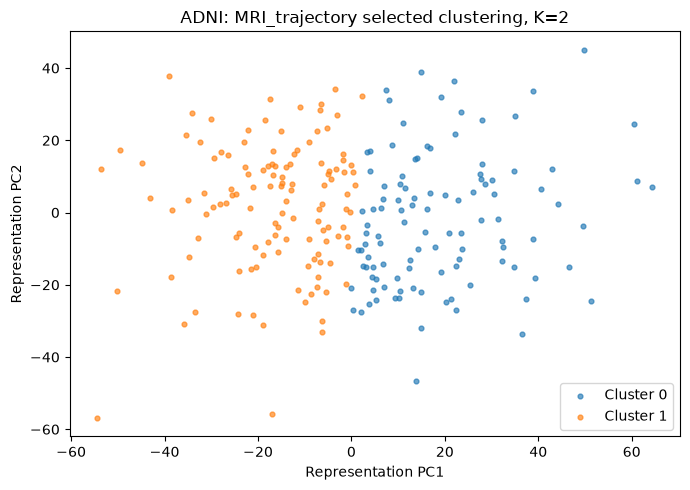

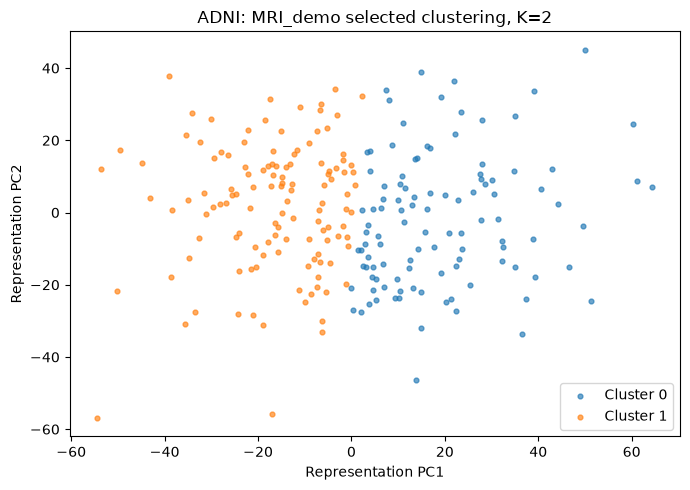

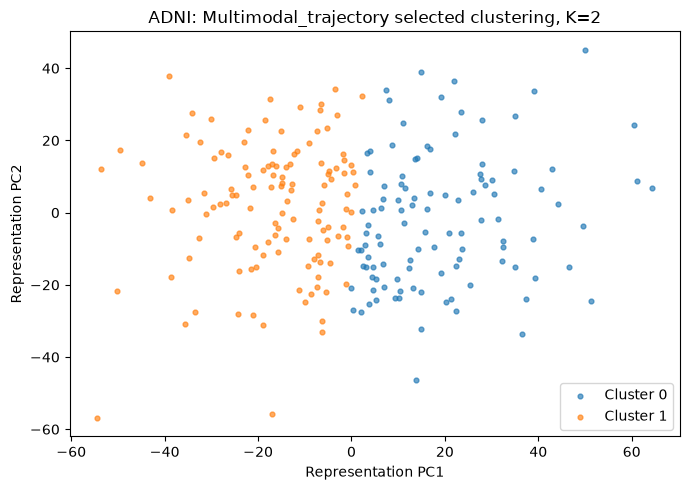

,k,silhouette,inertia,bootstrap_ARI_mean,bootstrap_ARI_median,bootstrap_ARI_q25,bootstrap_ARI_q75,subsample_ARI_mean,subsample_ARI_median,min_cluster_fraction,max_cluster_fraction,dataset,representation
0,3,0.292999,103160.640625,0.850416,0.867176,0.780832,0.954326,0.852220,0.828635,0.125786,0.440252,OASIS,MRI_current
1,4,0.232367,88623.843750,0.813133,0.899022,0.717645,0.961293,0.889425,0.946002,0.125786,0.383648,OASIS,MRI_current
2,4,0.295748,236438.812500,0.808940,0.920314,0.661943,0.956348,0.893899,0.947169,0.125786,0.547170,OASIS,MRI_trajectory
3,4,0.295452,237018.656250,0.809941,0.924339,0.661943,0.954310,0.903675,0.946451,0.125786,0.547170,OASIS,MRI_demo
4,4,0.294290,237793.750000,0.803232,0.912844,0.660236,0.953710,0.892629,0.946451,0.125786,0.547170,OASIS,Multimodal_trajectory
5,6,0.225143,188976.718750,0.851008,0.876668,0.813464,0.917491,0.878429,0.889913,0.075472,0.320755,OASIS,Multimodal_trajectory
6,3,0.205891,178428.000000,0.798115,0.809206,0.681372,0.926245,0.846622,0.888903,0.259740,0.393939,ADNI,MRI_current
7,2,0.205727,211895.578125,0.782905,0.786636,0.696754,0.881949,0.837713,0.879609,0.480519,0.519481,ADNI,MRI_current
8,4,0.176037,161954.984375,0.744190,0.787030,0.660972,0.864303,0.855832,0.891263,0.155844,0.363636,ADNI,MRI_current
9,2,0.126759,447045.500000,0.685890,0.653831,0.582007,0.806061,0.807006,0.811209,0.467532,0.532468,ADNI,MRI_trajectory


In [26]:
# ============================================================
# 8G. CLUSTER VISUALIZATION AND SUBJECT-LEVEL PHENOTYPE MAPS
# ============================================================
# Visual diagnostics are generated for the selected clustering solution.
# UMAP is optional because it is not required for the quantitative claims.

for ds in datasets:

    df = representation_tables[ds].copy()

    for kind in representation_kinds:

        model_info = final_cluster_models[(ds, kind)]
        X = model_info['X']
        labels = cluster_assignments[(ds, kind)]
        k = int(model_info['chosen_k'])

        # 2-D PCA view of the actual clustering representation.
        p2 = PCA(
            n_components=2,
            random_state=SEED
        ).fit_transform(X)

        plt.figure(figsize=(7, 5))
        for cl in range(k):
            m = labels == cl
            plt.scatter(
                p2[m, 0],
                p2[m, 1],
                s=12,
                alpha=0.65,
                label=f'Cluster {cl}'
            )

        plt.xlabel('Representation PC1')
        plt.ylabel('Representation PC2')
        plt.title(f'{ds}: {kind} selected clustering, K={k}')
        plt.legend()
        plt.tight_layout()

        out = FIG_ROOT / f'{ds}_{kind}_selected_cluster_map.png'
        plt.savefig(out, dpi=220)
        plt.show()

# A representation-to-cluster summary of selected K.
selected_cluster_rows = []

for ds in datasets:
    for kind in representation_kinds:

        allq = cluster_summary_df[
    (cluster_summary_df.dataset == ds)
    &
    (cluster_summary_df.representation == kind)
].copy()

        if allq.empty:
             continue

        best = allq["bootstrap_ARI_median"].max()

        q = allq[
    allq["bootstrap_ARI_median"] >= 0.95 * best
].sort_values(
    ["silhouette", "k"],
    ascending=[False, True]
)

        if q.empty:
            # The current base table may not contain a selected flag.
            allq = cluster_summary_df[
                (cluster_summary_df.dataset == ds)
                &
                (cluster_summary_df.representation == kind)
            ]

            if allq.empty:
                continue

            best = allq.bootstrap_ARI_median.max()

            q = allq[
                allq.bootstrap_ARI_median >= 0.95 * best
            ].sort_values(
                ['silhouette', 'k'],
                ascending=[False, True]
            ).head(1)

        selected_cluster_rows.append(q)

selected_cluster_q_df = (
    pd.concat(selected_cluster_rows, ignore_index=True)
    if selected_cluster_rows
    else pd.DataFrame()
)

display(selected_cluster_q_df)

selected_cluster_q_df.to_csv(
    TABLE_ROOT / 'selected_cluster_quality.csv',
    index=False
)


In [27]:
# ============================================================
# 8H. CLUSTER -> PREDICTION DIFFICULTY ASSOCIATION
# ============================================================

cluster_difficulty_rows=[]

for ds in datasets:

    df0=representation_tables[ds].copy()

    for kind in representation_kinds:

        labels=cluster_assignments[(ds,kind)]
        df=df0.copy()
        df['cluster']=labels

        for cl,g in df.groupby('cluster'):

            row={
                'dataset':ds,
                'representation':kind,
                'cluster':int(cl),
                'N':int(len(g))
            }

            for c in [
                'abs_error',
                'prediction_disagreement',
                'uncertainty'
            ]:

                if c not in df.columns:
                    continue

                gx=pd.to_numeric(
                    g[c],
                    errors='coerce'
                ).dropna()

                if gx.empty:
                    continue

                x=pd.to_numeric(
                    df[c],
                    errors='coerce'
                ).dropna()

                threshold=(
                    float(x.quantile(.75))
                    if len(x)
                    else np.nan
                )

                row[f'{c}_N_valid']=int(len(gx))
                row[f'{c}_mean']=float(gx.mean())
                row[f'{c}_median']=float(gx.median())

                if np.isfinite(threshold):
                    overall_rate=float(
                        (x>=threshold).mean()
                    )
                    cluster_rate=float(
                        (gx>=threshold).mean()
                    )

                    row[
                        f'{c}_top_quartile_enrichment'
                    ]=(
                        cluster_rate/overall_rate
                        if overall_rate>0
                        else np.nan
                    )

            cluster_difficulty_rows.append(row)

cluster_difficulty_df=pd.DataFrame(cluster_difficulty_rows)

display(cluster_difficulty_df)

cluster_difficulty_df.to_csv(
    TABLE_ROOT/'cluster_predictive_phenotypes.csv',
    index=False
)


,dataset,representation,cluster,N,abs_error_N_valid,abs_error_mean,abs_error_median,abs_error_top_quartile_enrichment,prediction_disagreement_N_valid,prediction_disagreement_mean,prediction_disagreement_median,prediction_disagreement_top_quartile_enrichment,uncertainty_N_valid,uncertainty_mean,uncertainty_median,uncertainty_top_quartile_enrichment
0,OASIS,MRI_current,0,70,70,1.612638,0.794728,1.306071,70,1.721124,1.050852,1.362857,70,0.438263,0.390849,0.965357
1,OASIS,MRI_current,1,69,69,1.455920,0.602013,0.806522,69,1.120465,0.446355,0.806522,69,0.407834,0.369229,0.979348
2,OASIS,MRI_current,2,20,20,0.996928,0.501250,0.596250,20,1.169464,0.673124,0.397500,20,0.407299,0.353471,1.192500
3,OASIS,MRI_trajectory,0,29,29,1.164310,0.527781,0.959483,29,0.834134,0.320953,0.685345,29,0.366053,0.333299,0.274138
4,OASIS,MRI_trajectory,1,23,23,1.152767,0.644700,0.518478,23,0.615585,0.302274,0.345652,23,0.317779,0.247596,0.518478
5,OASIS,MRI_trajectory,2,87,87,1.759361,0.806676,1.233621,87,1.832671,1.099014,1.416379,87,0.470051,0.409494,1.325000
6,OASIS,MRI_trajectory,3,20,20,0.996928,0.501250,0.596250,20,1.169464,0.673124,0.397500,20,0.407299,0.353471,1.192500
7,OASIS,MRI_demo,0,29,29,1.164310,0.527781,0.959483,29,0.834134,0.320953,0.685345,29,0.366053,0.333299,0.274138
8,OASIS,MRI_demo,1,23,23,1.152767,0.644700,0.518478,23,0.615585,0.302274,0.345652,23,0.317779,0.247596,0.518478
9,OASIS,MRI_demo,2,87,87,1.759361,0.806676,1.233621,87,1.832671,1.099014,1.416379,87,0.470051,0.409494,1.325000


# 9. Learned discordance versus current-state discordance and prediction disagreement

We now reconstruct the leakage-controlled state discordance used in the earlier OASIS and ADNI notebooks:

- brain abnormality = age-prediction deviation from chronological age using the frozen 1488-D representation;
- cognitive impairment = age/sex-adjusted MMSE impairment;
- state discordance = absolute difference between the two standardized quantities.

The normative model is cross-fitted within OOF and fitted only on OOF before scoring held-out test rows.

This section also compares:

- state discordance,
- prediction disagreement,
- embedding trajectory distance/speed,
- cluster identity,
- conventional model uncertainty.

In [28]:
# ============================================================
# 9. STATE DISCORDANCE ENGINE
# ============================================================
def weighted_subject_weights(df):
    counts=df.groupby('subject_id')['subject_id'].transform('size').to_numpy()
    return 1.0/np.maximum(counts,1)


def fit_brain_age_model(X, age, subject_ids, sex, n_pca=64, alpha=10.0):
    m=np.isfinite(age)&np.isfinite(X).all(axis=1)
    X=np.asarray(X,dtype=np.float32)[m]; y=np.asarray(age,dtype=float)[m]
    sid=np.asarray(subject_ids)[m]; sex_arr=np.asarray(sex,dtype=object)[m]
    scaler=StandardScaler(); Z=scaler.fit_transform(X)
    ncomp=min(n_pca,Z.shape[1],max(2,Z.shape[0]-1)); pca=PCA(n_components=ncomp,random_state=SEED); Z=pca.fit_transform(Z)
    reg=Ridge(alpha=alpha)
    uniq,counts=np.unique(sid,return_counts=True); wm=dict(zip(uniq,1/np.maximum(counts,1))); sw=np.array([wm[s] for s in sid])
    reg.fit(Z,y,sample_weight=sw)
    pred=reg.predict(Z); gap=pred-y
    gap_mean_global=float(np.mean(gap)); gap_sd_global=float(max(np.std(gap,ddof=1),1e-6))
    means={}; sds={}
    for sx in np.unique(sex_arr.astype(str)):
        g=gap[sex_arr.astype(str)==sx]
        if len(g)>=5: means[str(sx)]=float(np.mean(g)); sds[str(sx)]=float(max(np.std(g,ddof=1),1e-6))
    return {'scaler':scaler,'pca':pca,'reg':reg,'means':means,'sds':sds,'gm':gap_mean_global,'gs':gap_sd_global}


def predict_brain_age(m,X): return m['reg'].predict(m['pca'].transform(m['scaler'].transform(np.asarray(X,dtype=np.float32))))


def fit_cog_norm(df):
    d=df[['anchor_age','anchor_mmse','sex','subject_id']].copy().replace([np.inf,-np.inf],np.nan).dropna(subset=['anchor_age','anchor_mmse'])
    d['age2']=d.anchor_age**2
    sx=d.sex.fillna('UNK').astype(str)
    X=pd.DataFrame({'age':d.anchor_age,'age2':d.age2,'male':sx.str.upper().str.startswith('M').astype(float),'female':sx.str.upper().str.startswith('F').astype(float)})
    reg=Ridge(alpha=10.0); reg.fit(X,d.anchor_mmse,sample_weight=weighted_subject_weights(d)); return {'reg':reg,'sd':float(max(np.std(reg.predict(X)-d.anchor_mmse,ddof=1),1e-6))}


def predict_cog(m,age,sex):
    age=np.asarray(age,dtype=float); sx=pd.Series(sex).fillna('UNK').astype(str)
    X=pd.DataFrame({'age':age,'age2':age**2,'male':sx.str.upper().str.startswith('M').astype(float).to_numpy(),'female':sx.str.upper().str.startswith('F').astype(float).to_numpy()})
    return m['reg'].predict(X)


def fit_state_norm(dev,X):
    ok=dev.anchor_age.notna()&dev.anchor_mmse.notna()&np.isfinite(X).all(axis=1)
    tr=dev.loc[ok].reset_index(drop=True); Xt=X[ok.to_numpy()]
    bm=fit_brain_age_model(Xt,tr.anchor_age.to_numpy(),tr.subject_id.to_numpy(),tr.sex.to_numpy())
    cm=fit_cog_norm(tr)
    return {'brain':bm,'cog':cm}


def score_state_norm(m,df,X):
    out=df.copy(); age=out.anchor_age.to_numpy(dtype=float); mmse=out.anchor_mmse.to_numpy(dtype=float)
    bp=predict_brain_age(m['brain'],X); gap=bp-age
    sx=out.sex.fillna('UNK').astype(str).to_numpy(); bz=[]
    for g,s in zip(gap,sx): bz.append((g-m['brain']['means'].get(str(s),m['brain']['gm']))/max(m['brain']['sds'].get(str(s),m['brain']['gs']),1e-6))
    ce=predict_cog(m['cog'],age,sx); ci=(ce-mmse)/m['cog']['sd']
    out['brain_age_pred']=bp; out['brain_age_gap']=gap; out['brain_abnormality_z']=bz; out['cognitive_expected_mmse']=ce; out['cognitive_impairment_z']=ci
    out['state_discordance']=(out.brain_abnormality_z-out.cognitive_impairment_z).abs(); out['signed_state_discordance']=out.brain_abnormality_z-out.cognitive_impairment_z
    return out

In [29]:
# ============================================================
# 9B. ROBUST LEAKAGE-CONTROLLED STATE SCORES
# ============================================================

def repair_anchor_metadata(ds, frame):
    """
    Ensure anchor_age / anchor_mmse / sex are valid before
    state-discordance modeling.

    Important:
    Saved ADNI prediction artifacts may already contain anchor_age.
    A merge with clinical data can create anchor_age_x / anchor_age_y.
    Prefer the existing artifact value, then fall back to the
    clinical lookup.
    """
    d = frame.copy()

    # --------------------------------------------------------
    # Recover age after possible merge suffixes
    # --------------------------------------------------------
    age_candidates = [
        c for c in [
            "anchor_age",
            "anchor_age_x",
            "anchor_age_y",
            "age_visit",
            "age",
        ]
        if c in d.columns
    ]

    if age_candidates:
        age = pd.Series(np.nan, index=d.index, dtype=float)

        # Prefer values already present in the prediction artifact.
        for c in ["anchor_age", "anchor_age_x", "anchor_age_y",
                  "age_visit", "age"]:
            if c in d.columns:
                age = age.combine_first(
                    pd.to_numeric(d[c], errors="coerce")
                )

        d["anchor_age"] = age
    else:
        d["anchor_age"] = np.nan

    # --------------------------------------------------------
    # Recover MMSE
    # --------------------------------------------------------
    mmse_candidates = [
        c for c in [
            "anchor_mmse",
            "anchor_mmse_x",
            "anchor_mmse_y",
            "mmse",
        ]
        if c in d.columns
    ]

    if mmse_candidates:
        mmse = pd.Series(np.nan, index=d.index, dtype=float)

        for c in ["anchor_mmse", "anchor_mmse_x",
                  "anchor_mmse_y", "mmse"]:
            if c in d.columns:
                mmse = mmse.combine_first(
                    pd.to_numeric(d[c], errors="coerce")
                )

        d["anchor_mmse"] = mmse
    else:
        d["anchor_mmse"] = np.nan

    # --------------------------------------------------------
    # Recover sex
    # --------------------------------------------------------
    sex_candidates = [
        c for c in [
            "sex",
            "sex_x",
            "sex_y",
            "gender",
            "PTGENDER",
        ]
        if c in d.columns
    ]

    sex = pd.Series("UNK", index=d.index, dtype=object)

    for c in sex_candidates:
        vals = d[c].fillna("UNK").astype(str)
        good = vals.ne("UNK")
        sex.loc[good & sex.eq("UNK")] = vals.loc[
            good & sex.eq("UNK")
        ]

    d["sex"] = sex

    # --------------------------------------------------------
    # Remove duplicate suffix columns after recovery
    # --------------------------------------------------------
    drop_cols = [
        c for c in [
            "anchor_age_x",
            "anchor_age_y",
            "anchor_mmse_x",
            "anchor_mmse_y",
            "sex_x",
            "sex_y",
        ]
        if c in d.columns
    ]

    if drop_cols:
        d = d.drop(columns=drop_cols)

    return d


# ------------------------------------------------------------
# Repair the already-created metadata tables
# ------------------------------------------------------------

for ds in datasets:
    datasets[ds]["test_meta"] = repair_anchor_metadata(
        ds,
        datasets[ds]["test_meta"]
    )

    datasets[ds]["oof_meta"] = repair_anchor_metadata(
        ds,
        datasets[ds]["oof_meta"]
    )


# ------------------------------------------------------------
# Build embedding matrices
# ------------------------------------------------------------

def frame_embedding_matrix(df):
    X = np.full(
        (len(df), EXPECTED_EMBED_DIM),
        np.nan,
        dtype=np.float32
    )

    if "embedding_path" not in df.columns:
        raise RuntimeError(
            "embedding_path missing from state-analysis dataframe."
        )

    for i, p in enumerate(df["embedding_path"]):
        if p is None or pd.isna(p):
            continue

        z = load_vec(p)

        if z is not None:
            X[i] = z

    return X


# ------------------------------------------------------------
# Cross-fitted state scoring
# ------------------------------------------------------------

def crossfit_state_oof(dev, X, n_splits=5):

    out = dev.copy().reset_index(drop=True)

    state_cols = [
        "state_discordance",
        "signed_state_discordance",
        "brain_age_gap",
        "brain_abnormality_z",
        "cognitive_impairment_z",
    ]

    for c in state_cols:
        out[c] = np.nan

    groups = (
        out["subject_id"]
        .astype(str)
        .to_numpy()
    )

    n_groups = len(np.unique(groups))
    k = min(n_splits, n_groups)

    if k < 2:
        return out

    from sklearn.model_selection import GroupKFold

    gkf = GroupKFold(n_splits=k)

    for fi, vi in gkf.split(
        out,
        groups=groups
    ):

        tr = out.iloc[fi].reset_index(drop=True)
        va = out.iloc[vi].reset_index(drop=True)

        Xtr = X[fi]
        Xva = X[vi]

        oktr = (
            np.isfinite(Xtr).all(axis=1)
            & pd.to_numeric(
                tr["anchor_age"],
                errors="coerce"
            ).notna().to_numpy()
            & pd.to_numeric(
                tr["anchor_mmse"],
                errors="coerce"
            ).notna().to_numpy()
        )

        okva = (
            np.isfinite(Xva).all(axis=1)
            & pd.to_numeric(
                va["anchor_age"],
                errors="coerce"
            ).notna().to_numpy()
            & pd.to_numeric(
                va["anchor_mmse"],
                errors="coerce"
            ).notna().to_numpy()
        )

        if oktr.sum() < 25 or okva.sum() == 0:
            continue

        m = fit_state_norm(
            tr.loc[oktr].reset_index(drop=True),
            Xtr[oktr]
        )

        scored = score_state_norm(
            m,
            va.loc[okva].reset_index(drop=True),
            Xva[okva]
        )

        target_indices = (
            np.asarray(vi)[
                np.flatnonzero(okva)
            ]
        )

        for c in state_cols:
            out.loc[
                target_indices,
                c
            ] = scored[c].to_numpy()

    return out


# ------------------------------------------------------------
# Run state analysis separately for each dataset
# ------------------------------------------------------------

state_outputs = {}

for ds in datasets:

    print("\n" + "=" * 80)
    print(ds, "STATE DISCORDANCE")
    print("=" * 80)

    test = datasets[ds]["test_meta"].copy()
    oof = datasets[ds]["oof_meta"].copy()

    # ----------------------------
    # QC before entering repeats
    # ----------------------------

    print(
        "TEST rows:",
        len(test),
        "| embeddings:",
        int(test["embedding_path"].notna().sum())
        if "embedding_path" in test.columns else 0,
        "| age:",
        int(test["anchor_age"].notna().sum()),
        "| MMSE:",
        int(test["anchor_mmse"].notna().sum())
    )

    print(
        "OOF rows:",
        len(oof),
        "| embeddings:",
        int(oof["embedding_path"].notna().sum())
        if "embedding_path" in oof.columns else 0,
        "| age:",
        int(oof["anchor_age"].notna().sum()),
        "| MMSE:",
        int(oof["anchor_mmse"].notna().sum())
    )

    Xt = frame_embedding_matrix(test)
    Xo = frame_embedding_matrix(oof)

    all_test = []
    all_oof = []

    reps = sorted(
        pd.to_numeric(
            test["repeat"],
            errors="coerce"
        )
        .dropna()
        .astype(int)
        .unique()
    )

    for rep in reps:

        dev = (
            oof[oof["repeat"].eq(rep)]
            .reset_index(drop=True)
        )

        te = (
            test[test["repeat"].eq(rep)]
            .reset_index(drop=True)
        )

        oi = oof.index[
            oof["repeat"].eq(rep)
        ].to_numpy()

        ti = test.index[
            test["repeat"].eq(rep)
        ].to_numpy()

        Xod = Xo[oi]
        Xtd = Xt[ti]

        ok = (
            np.isfinite(Xod).all(axis=1)
            & pd.to_numeric(
                dev["anchor_age"],
                errors="coerce"
            ).notna().to_numpy()
            & pd.to_numeric(
                dev["anchor_mmse"],
                errors="coerce"
            ).notna().to_numpy()
        )

        tok = (
            np.isfinite(Xtd).all(axis=1)
            & pd.to_numeric(
                te["anchor_age"],
                errors="coerce"
            ).notna().to_numpy()
            & pd.to_numeric(
                te["anchor_mmse"],
                errors="coerce"
            ).notna().to_numpy()
        )

        print(
            f"repeat {rep}: "
            f"dev usable={int(ok.sum())}/{len(dev)} | "
            f"test usable={int(tok.sum())}/{len(te)}"
        )

        # Never silently create an empty analysis.
        if ok.sum() < 25:
            print(
                f"repeat {rep}: skipped, "
                f"insufficient usable development rows."
            )
            continue

        if tok.sum() == 0:
            print(
                f"repeat {rep}: skipped, "
                f"no usable held-out rows."
            )
            continue

        # Cross-fitted development scores
        so = crossfit_state_oof(
            dev,
            Xod,
            n_splits=5
        )

        # Development-only normative model
        m = fit_state_norm(
            dev.loc[ok].reset_index(drop=True),
            Xod[ok]
        )

        # Held-out scores
        st = score_state_norm(
            m,
            te.loc[tok].reset_index(drop=True),
            Xtd[tok]
        )

        so["repeat"] = rep
        st["repeat"] = rep

        all_oof.append(so)
        all_test.append(st)

    # --------------------------------------------------------
    # Safe concatenation
    # --------------------------------------------------------

    if not all_oof:
        raise RuntimeError(
            f"{ds}: state OOF produced no valid repeats. "
            "Inspect the per-repeat usable-row QC above."
        )

    if not all_test:
        raise RuntimeError(
            f"{ds}: state TEST produced no valid repeats. "
            "Inspect the per-repeat usable-row QC above."
        )

    state_outputs[ds] = {
        "oof": pd.concat(
            all_oof,
            ignore_index=True
        ),
        "test": pd.concat(
            all_test,
            ignore_index=True
        ),
    }

    print(
        ds,
        "state OOF:",
        len(state_outputs[ds]["oof"]),
        "TEST:",
        len(state_outputs[ds]["test"])
    )


OASIS STATE DISCORDANCE
TEST rows: 311 | embeddings: 311 | age: 311 | MMSE: 311
OOF rows: 1219 | embeddings: 1219 | age: 1219 | MMSE: 1219
repeat 1: dev usable=201/201 | test usable=54/54
repeat 2: dev usable=201/201 | test usable=54/54
repeat 3: dev usable=204/204 | test usable=51/51
repeat 4: dev usable=203/203 | test usable=52/52
repeat 5: dev usable=209/209 | test usable=46/46
repeat 6: dev usable=201/201 | test usable=54/54
OASIS state OOF: 1219 TEST: 311

ADNI STATE DISCORDANCE
TEST rows: 1095 | embeddings: 1095 | age: 1095 | MMSE: 1095
OOF rows: 4509 | embeddings: 4509 | age: 4509 | MMSE: 4509
repeat 1: dev usable=747/747 | test usable=187/187
repeat 2: dev usable=762/762 | test usable=172/172
repeat 3: dev usable=750/750 | test usable=184/184
repeat 4: dev usable=758/758 | test usable=176/176
repeat 5: dev usable=746/746 | test usable=188/188
repeat 6: dev usable=746/746 | test usable=188/188
ADNI state OOF: 4509 TEST: 1095


In [30]:
# ============================================================
# 9C. STATE VS FORECAST DISCORDANCE SUMMARY
# ============================================================
state_compare_rows=[]
for ds in datasets:
    st=state_outputs[ds]['test']
    if st.empty: continue
    for rep,g in st.groupby('repeat'):
        agg=g.groupby('subject_id',as_index=False).agg(
            state_discordance=('state_discordance','mean'),
            signed_state_discordance=('signed_state_discordance','mean'),
            prediction_disagreement=('prediction_disagreement','mean'),
            uncertainty=('uncertainty','mean'),
            abs_error=('abs_error','mean')
        )
        for sig in ['state_discordance','signed_state_discordance','prediction_disagreement','uncertainty']:
            rho,p=safe_spearman(agg[sig],agg.abs_error)
            state_compare_rows.append({'dataset':ds,'repeat':rep,'signal':sig,'N_subjects':len(agg),'rho_error':rho,'p':p})
state_compare_df=pd.DataFrame(state_compare_rows)
display(state_compare_df.groupby(['dataset','signal'])['rho_error'].agg(['mean','median','std','count']).reset_index())
state_compare_df.to_csv(TABLE_ROOT/'state_vs_forecast_discordance_repeated.csv',index=False)

,dataset,signal,mean,median,std,count
0,ADNI,prediction_disagreement,0.211335,0.212762,0.109276,6
1,ADNI,signed_state_discordance,-0.253574,-0.247664,0.098881,6
2,ADNI,state_discordance,0.210815,0.232203,0.098523,6
3,ADNI,uncertainty,0.347998,0.435194,0.200308,6
4,OASIS,prediction_disagreement,0.321127,0.302779,0.125379,6
5,OASIS,signed_state_discordance,-0.267517,-0.247131,0.109274,6
6,OASIS,state_discordance,0.037854,0.028390,0.100614,6
7,OASIS,uncertainty,0.263138,0.205074,0.158887,6


# 10. Directional state discordance

Absolute discordance can hide whether the brain-derived state is more abnormal than cognition or vice versa. We therefore retain the signed quantity and explicitly compare:

- aligned state,
- brain-more-abnormal,
- cognition-more-abnormal.

The category threshold is defined without future outcomes, using the sign of the OOF-derived state difference.

In [31]:
# ============================================================
# 10. DIRECTIONAL STATE ANALYSIS
# ============================================================
directional_rows=[]
for ds in datasets:
    st=state_outputs[ds]['test']
    if st.empty: continue
    d=st.copy()
    d['direction']=np.select([d.signed_state_discordance>0.25,d.signed_state_discordance<-0.25],['brain_more_abnormal','cognition_more_abnormal'],default='aligned')
    agg=d.groupby(['repeat','subject_id','direction'],as_index=False).agg(abs_error=('abs_error','mean'),prediction_disagreement=('prediction_disagreement','mean'),uncertainty=('uncertainty','mean'))
    out=agg.groupby(['repeat','direction']).agg(N=('subject_id','nunique'),MAE=('abs_error','mean'),median_error=('abs_error','median'),mean_pred_disagreement=('prediction_disagreement','mean')).reset_index()
    out['dataset']=ds; directional_rows.append(out)
directional_df=pd.concat(directional_rows,ignore_index=True)
display(directional_df)
directional_df.to_csv(TABLE_ROOT/'directional_state_discordance.csv',index=False)

,repeat,direction,N,MAE,median_error,mean_pred_disagreement,dataset
0,1,aligned,6,1.770662,0.456563,1.164859,OASIS
1,1,brain_more_abnormal,26,0.929341,0.849287,1.218884,OASIS
2,1,cognition_more_abnormal,19,1.157305,0.767752,1.303542,OASIS
3,2,aligned,6,0.808186,0.535988,0.274493,OASIS
4,2,brain_more_abnormal,25,1.116118,0.660710,0.933750,OASIS
5,2,cognition_more_abnormal,18,2.175540,1.442827,2.123998,OASIS
6,3,aligned,3,0.668138,0.658540,2.822861,OASIS
7,3,brain_more_abnormal,24,1.172283,0.747652,0.834096,OASIS
8,3,cognition_more_abnormal,20,3.002369,1.663528,2.144273,OASIS
9,4,aligned,6,1.285178,1.370262,0.625931,OASIS


# 11. Prediction disagreement versus conventional uncertainty

The central reliability question is not whether disagreement merely correlates with error. It is whether it adds information beyond ordinary uncertainty.

We evaluate:

- Spearman association with error.
- Fixed and OOF-defined high-error AUROC/AP.
- Error prediction with difficulty covariates.
- Risk-coverage / AURC.
- Discordance-aware routing.

In [32]:
# ============================================================
# 11. RELIABILITY COMPARISON
# ============================================================
def oof_threshold(oof, col, q=.75):
    x=pd.to_numeric(oof[col],errors='coerce').replace([np.inf,-np.inf],np.nan).dropna()
    return float(x.quantile(q)) if len(x) else np.nan


def summarize_reliability(ds):
    test=datasets[ds]['test_meta'].copy(); oof=datasets[ds]['oof_meta'].copy(); rows=[]
    for rep in sorted(test.repeat.dropna().unique().astype(int)):
        te=test[test.repeat.eq(rep)].copy(); dev=oof[oof.repeat.eq(rep)].copy()
        for sig in ['uncertainty','prediction_disagreement']:
            if sig not in te.columns: continue
            d=te[['subject_id',sig,'abs_error']].dropna().groupby('subject_id',as_index=False).mean()
            rho,p=safe_spearman(d[sig],d.abs_error)
            qf=float(d.abs_error.quantile(.75)); event=(d.abs_error>=qf).astype(int)
            score=d[sig]
            try: au=roc_auc_score(event,score)
            except: au=np.nan
            try: ap=average_precision_score(event,score)
            except: ap=np.nan
            rows.append({'dataset':ds,'repeat':rep,'signal':sig,'rho':rho,'p':p,'high_error_auc':au,'high_error_ap':ap,'N':len(d)})
    return pd.DataFrame(rows)

rel_df=pd.concat([summarize_reliability(ds) for ds in datasets],ignore_index=True)
display(rel_df.groupby(['dataset','signal'])[['rho','high_error_auc','high_error_ap']].agg(['mean','median','std']).reset_index())
rel_df.to_csv(TABLE_ROOT/'reliability_signal_comparison.csv',index=False)

dataset                   signal       rho                      \
                                        mean    median       std   
0    ADNI  prediction_disagreement  0.211335  0.212762  0.109276   
1    ADNI              uncertainty  0.347998  0.435194  0.200308   
2   OASIS  prediction_disagreement  0.321127  0.302779  0.125379   
3   OASIS              uncertainty  0.263138  0.205074  0.158887   

  high_error_auc                     high_error_ap                      
            mean    median       std          mean    median       std  
0       0.624094  0.639266  0.056262      0.427718  0.440583  0.058789  
1       0.659194  0.696332  0.110626      0.464180  0.502008  0.131611  
2       0.677083  0.644886  0.108561      0.518491  0.455560  0.143734  
3       0.713542  0.670455  0.106106      0.529549  0.489750  0.150152

In [33]:
# ============================================================
# 11B. INCREMENTAL ERROR PREDICTION: UNCERTAINTY VS DISAGREEMENT
# ============================================================
def incremental_error_models(ds):
    rows=[]
    for rep in sorted(datasets[ds]['test_meta'].repeat.dropna().unique().astype(int)):
        te=datasets[ds]['test_meta'][datasets[ds]['test_meta'].repeat.eq(rep)].copy()
        dev=datasets[ds]['oof_meta'][datasets[ds]['oof_meta'].repeat.eq(rep)].copy()
        if len(te)<10 or len(dev)<30: continue
        controls=[c for c in ['anchor_mmse','n_mri','n_clinical','future_interval_days'] if c in te.columns and c in dev.columns]
        signals=[c for c in ['uncertainty','prediction_disagreement'] if c in te.columns and c in dev.columns]
        if not signals: continue
        for kind, cols in [('difficulty',controls),('difficulty_plus_uncertainty',controls+(['uncertainty'] if 'uncertainty' in signals else [])),('difficulty_plus_disagreement',controls+(['prediction_disagreement'] if 'prediction_disagreement' in signals else [])),('all_reliability',controls+signals)]:
            cols=[c for c in cols if c in dev.columns]
            if not cols: continue
            D=dev[cols+['abs_error']].replace([np.inf,-np.inf],np.nan).dropna()
            T=te[cols+['abs_error']].replace([np.inf,-np.inf],np.nan).dropna()
            if len(D)<30 or len(T)<10: continue
            model=make_pipeline(StandardScaler(),Ridge(alpha=10.0)) if False else Ridge(alpha=10.0)
            sc=StandardScaler(); Xd=sc.fit_transform(D[cols]); Xt=sc.transform(T[cols])
            model.fit(Xd,D.abs_error); pred=model.predict(Xt)
            rows.append({'dataset':ds,'repeat':rep,'model':kind,'MAE_predicted_error':mean_absolute_error(T.abs_error,pred),'R2_predicted_error':r2_score(T.abs_error,pred)})
    return pd.DataFrame(rows)

errpred_df=pd.concat([incremental_error_models(ds) for ds in datasets],ignore_index=True)
display(errpred_df.groupby(['dataset','model'])[['MAE_predicted_error','R2_predicted_error']].agg(['mean','median','std']).reset_index())
errpred_df.to_csv(TABLE_ROOT/'incremental_error_prediction.csv',index=False)

dataset                         model MAE_predicted_error            \
                                                       mean    median   
0    ADNI               all_reliability            0.966733  0.942953   
1    ADNI                    difficulty            0.964070  0.936658   
2    ADNI  difficulty_plus_disagreement            0.965512  0.941537   
3    ADNI   difficulty_plus_uncertainty            0.965696  0.937700   
4   OASIS               all_reliability            1.001502  1.081573   
5   OASIS                    difficulty            1.002359  1.055104   
6   OASIS  difficulty_plus_disagreement            0.994471  1.056911   
7   OASIS   difficulty_plus_uncertainty            1.006798  1.076775   

            R2_predicted_error                      
        std               mean    median       std  
0  0.068803           0.095394  0.077203  0.057741  
1  0.068383           0.090911  0.069070  0.062439  
2  0.068110           0.097360  0.076199  0.059868  
3  0.068600           0.088795  0.069854  0.059978  
4  0.198113          -0.057131  0.210979  0.565852  
5  0.200875          -0.062090  0.211866  0.583965  
6  0.202261          -0.056681  0.214371  0.586544  
7  0.193374          -0.062780  0.207509  0.558672

In [34]:
def rmse(y_true, y_pred, squared=False):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    mse = mean_squared_error(
        y_true[mask],
        y_pred[mask]
    )
    return float(
        mse if squared else np.sqrt(mse)
    )


,dataset,score,coverage,MAE
0,ADNI,prediction_disagreement,0.193548,1.464481
1,ADNI,prediction_disagreement,0.306452,1.440206
2,ADNI,prediction_disagreement,0.403226,1.410182
3,ADNI,prediction_disagreement,0.500000,1.426083
4,ADNI,prediction_disagreement,0.596774,1.443933
5,ADNI,prediction_disagreement,0.693548,1.430756
6,ADNI,prediction_disagreement,0.806452,1.513996
7,ADNI,prediction_disagreement,0.903226,1.599554
8,ADNI,prediction_disagreement,1.000000,1.690934
9,ADNI,uncertainty,0.193548,1.294299


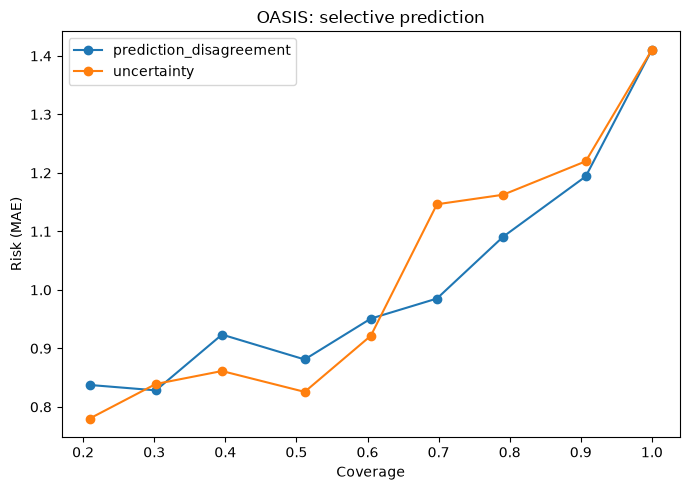

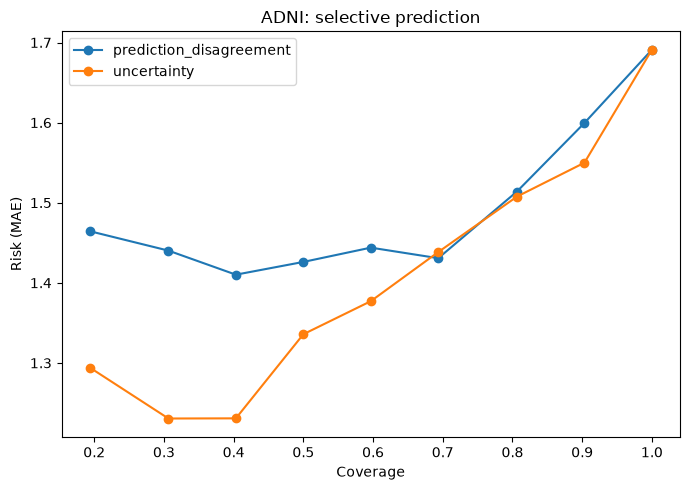

,dataset,policy,mean,median,std
0,ADNI,pred_disagreement_high_fallback_clinical,1.511501,1.514119,0.173460
1,ADNI,uncertainty_high_fallback_clinical,1.515141,1.517406,0.160372
2,OASIS,pred_disagreement_high_fallback_clinical,1.317302,1.323004,0.333800
3,OASIS,uncertainty_high_fallback_clinical,1.346950,1.352353,0.337778


In [35]:
# ============================================================
# 11C. SELECTIVE PREDICTION / RISK-COVERAGE / ROUTING
# ============================================================
def risk_curve(d,score):
    x=d[[score,'abs_error']].replace([np.inf,-np.inf],np.nan).dropna().sort_values(score).reset_index(drop=True)
    out=[]
    for cov in np.arange(.2,1.01,.1):
        n=max(1,int(round(cov*len(x))))
        out.append({'coverage':n/len(x),'MAE':x.iloc[:n].abs_error.mean()})
    return pd.DataFrame(out)

rc_rows=[]; routing_rows=[]
for ds in datasets:
    test=datasets[ds]['test_meta'].copy(); oof=datasets[ds]['oof_meta'].copy()
    for rep in sorted(test.repeat.dropna().unique().astype(int)):
        te=test[test.repeat.eq(rep)].copy(); dev=oof[oof.repeat.eq(rep)].copy()
        for score in ['uncertainty','prediction_disagreement']:
            if score not in te.columns: continue
            d=te.groupby('subject_id',as_index=False)[[score,'abs_error']].mean().dropna()
            rc=risk_curve(d,score); rc['dataset']=ds; rc['repeat']=rep; rc['score']=score; rc_rows.append(rc)
        # thresholded clinical fallback based on OOF only
        if 'prediction_disagreement' in dev.columns and 'prediction_disagreement' in te.columns and 'clinical_prediction' in te.columns:
            thr=oof_threshold(dev,'prediction_disagreement',.75)
            pred=np.where(te.prediction_disagreement>=thr,te.clinical_prediction,te.prediction) if np.isfinite(thr) else te.prediction
            routing_rows.append({'dataset':ds,'repeat':rep,'policy':'pred_disagreement_high_fallback_clinical','MAE':mean_absolute_error(te.future_mmse,pred),"RMSE": rmse(te.future_mmse, pred),'N':len(te)})
        if 'uncertainty' in dev.columns and 'uncertainty' in te.columns and 'clinical_prediction' in te.columns:
            thr=oof_threshold(dev,'uncertainty',.75)
            pred=np.where(te.uncertainty>=thr,te.clinical_prediction,te.prediction) if np.isfinite(thr) else te.prediction
            routing_rows.append({'dataset':ds,'repeat':rep,'policy':'uncertainty_high_fallback_clinical','MAE':mean_absolute_error(te.future_mmse,pred),"RMSE": rmse(te.future_mmse, pred),'N':len(te)})
rc_df=pd.concat(rc_rows,ignore_index=True) if rc_rows else pd.DataFrame()
routing_df=pd.DataFrame(routing_rows)
if not rc_df.empty:
    display(rc_df.groupby(['dataset','score','coverage']).MAE.mean().reset_index().head(50))
    for ds in datasets:
        plt.figure(figsize=(7,5))
        z=rc_df[rc_df.dataset.eq(ds)]
        for score,g in z.groupby('score'):
            gg=g.groupby('coverage',as_index=False).MAE.mean(); plt.plot(gg.coverage,gg.MAE,marker='o',label=score)
        plt.xlabel('Coverage'); plt.ylabel('Risk (MAE)'); plt.title(f'{ds}: selective prediction'); plt.legend(); plt.tight_layout(); plt.savefig(FIG_ROOT/f'{ds}_risk_coverage.png',dpi=220); plt.show()
if not routing_df.empty: display(routing_df.groupby(['dataset','policy']).MAE.agg(['mean','median','std']).reset_index())
rc_df.to_csv(TABLE_ROOT/'risk_coverage.csv',index=False); routing_df.to_csv(TABLE_ROOT/'discordance_routing.csv',index=False)

# 12. High-disagreement case analysis

This is deliberately patient-level and interpretive rather than another aggregate metric.

For each dataset we identify the top 10% held-out cases by prediction disagreement and examine:

- MRI prediction,
- clinical prediction,
- joint prediction,
- actual future outcome,
- absolute error,
- uncertainty,
- state discordance,
- baseline MMSE,
- history length,
- MRI gap,
- embedding trajectory speed,
- embedding cluster.

The resulting tables are saved for manual case review.

In [36]:
# ============================================================
# 12. HIGH-DISAGREEMENT CASE TABLES
# ============================================================
high_disagreement_tables={}
for ds in datasets:
    te=state_outputs[ds]['test'].copy()
    if te.empty: continue
    # join representation features approximately on subject + repeat + anchor.
    top=[]
    for rep,g in te.groupby('repeat'):
        d=g.copy()
        if 'prediction_disagreement' not in d.columns: continue
        thr=d.prediction_disagreement.quantile(.90)
        d=d[d.prediction_disagreement>=thr].copy()
        cols=[c for c in ['subject_id','repeat','anchor_mmse','anchor_age','future_mmse','prediction','clinical_prediction','raw_prediction','prediction_disagreement','uncertainty','state_discordance','signed_state_discordance','abs_error','n_mri','n_clinical','future_interval_days','mri_gap_days'] if c in d.columns]
        dd=d[cols].copy(); dd['top10pct']=True; top.append(dd)
    hd=pd.concat(top,ignore_index=True) if top else pd.DataFrame()
    high_disagreement_tables[ds]=hd
    print('\n',ds,'top disagreement held-out rows:',len(hd))
    display(hd.head(30))
    hd.to_csv(TABLE_ROOT/f'{ds}_high_disagreement_cases.csv',index=False)


 OASIS top disagreement held-out rows: 35


,subject_id,repeat,anchor_mmse,anchor_age,future_mmse,prediction,clinical_prediction,raw_prediction,prediction_disagreement,uncertainty,state_discordance,signed_state_discordance,abs_error,n_mri,n_clinical,future_interval_days,mri_gap_days,top10pct
0,OAS30087,1,26.0,80.02,20.0,21.851649,22.776162,26.819231,4.043069,1.448575,2.103973,-2.103973,1.851649,1,2,346.0,106.0,True
1,OAS30132,1,30.0,71.67,30.0,27.909355,29.352671,25.925699,3.426972,0.290437,0.276645,0.276645,2.090645,2,5,374.0,133.0,True
2,OAS30671,1,27.0,68.65,29.0,27.804714,29.191764,24.338830,4.852934,0.708528,0.076558,0.076558,1.195286,1,2,678.0,177.0,True
3,OAS31002,1,29.0,80.01,30.0,27.881233,29.255697,25.431239,3.824458,0.316260,0.682827,0.682827,2.118767,1,8,363.0,54.0,True
4,OAS31133,1,30.0,70.93,29.0,26.634152,28.221490,23.343801,4.877689,0.497959,1.376503,1.376503,2.365848,1,1,420.0,0.0,True
5,OAS31140,1,23.0,88.19,22.0,21.255553,21.421622,29.068999,7.647377,0.717301,4.137378,-4.137378,0.744447,1,2,417.0,13.0,True
6,OAS30132,2,30.0,71.67,30.0,28.154601,29.376105,25.516520,3.859585,0.200313,0.909142,0.909142,1.845399,2,5,374.0,133.0,True
7,OAS30471,2,27.0,81.68,26.0,27.514790,28.869382,22.753740,6.115643,0.347011,1.980182,-1.980182,1.514790,1,3,403.0,147.0,True
8,OAS30682,2,15.0,78.60,4.0,20.360523,20.997472,28.842035,7.844563,0.731861,5.098825,-5.098825,16.360523,1,2,351.0,86.0,True
9,OAS31024,2,26.0,81.85,30.0,25.635028,26.075792,28.990886,2.915094,0.598417,1.402851,-1.402851,4.364972,2,4,382.0,26.0,True



 ADNI top disagreement held-out rows: 112


,subject_id,repeat,anchor_mmse,anchor_age,future_mmse,prediction,clinical_prediction,raw_prediction,prediction_disagreement,uncertainty,state_discordance,signed_state_discordance,abs_error,n_mri,n_clinical,future_interval_days,mri_gap_days,top10pct
0,007_S_0316,1,19.0,82.0,19.0,18.581825,19.605600,27.452537,7.846937,0.621302,3.504795,-3.504795,0.418175,2,2,188.0,1.0,True
1,007_S_0316,1,19.0,82.0,21.0,17.180878,18.249130,27.431529,9.182399,0.253150,2.801185,-2.801185,3.819122,3,3,379.0,0.0,True
2,021_S_1109,1,20.0,78.0,20.0,17.977485,19.038159,25.551302,6.513143,0.994169,1.844170,-1.844170,2.022515,2,2,184.0,0.0,True
3,027_S_0408,1,21.0,87.0,21.0,19.631238,20.527266,27.656904,7.129638,0.908854,2.412955,-2.412955,1.368762,6,8,347.0,3.0,True
4,027_S_1254,1,22.0,85.0,20.0,18.385504,19.345910,27.108523,7.762613,1.325966,2.094195,-2.094195,1.614496,2,2,181.0,1.0,True
5,027_S_1254,1,20.0,85.0,18.0,17.165478,18.159170,26.829526,8.670356,1.057817,2.096270,-2.096270,0.834522,3,3,365.0,6.0,True
6,031_S_0554,1,17.0,72.0,17.0,16.619315,17.685748,27.147956,9.462208,1.007726,1.483269,-1.483269,0.380685,2,2,189.0,0.0,True
7,031_S_0554,1,17.0,73.0,16.0,15.997489,17.075875,27.130299,10.054424,0.700372,1.752542,-1.752542,0.002511,3,3,360.0,0.0,True
8,033_S_1281,1,21.0,80.0,20.0,19.007729,20.030308,27.004981,6.974673,0.707183,1.702992,-1.702992,0.992271,4,4,350.0,0.0,True
9,033_S_1308,1,18.0,81.0,21.0,18.467953,19.510213,27.469476,7.959263,0.371339,2.590207,-2.590207,2.532047,3,3,364.0,0.0,True


# 13. Classical trajectory baselines

The learned representation should be compared with transparent trajectory features. These baselines use only information available before the prediction anchor:

- current MMSE and CDR,
- MMSE/CDR slopes,
- history length and duration,
- current MRI PCA coordinates,
- MRI delta coordinates,
- simple MRI embedding speed.

The prediction target remains the saved future MMSE. Subject-disjoint outer repeats are inherited from the existing prediction artifacts.

In [37]:
# ============================================================
# 13. CLASSICAL LONGITUDINAL PREDICTION BASELINES
# ============================================================
if RUN_CLASSICAL_BASELINES:
    classical_rows=[]
    classical_models={}
    for ds in datasets:
        # Build unique per-repeat anchor features for OOF and TEST.
        for split_name in ['oof','test']:
            pass
        for rep in sorted(datasets[ds]['test_meta'].repeat.dropna().unique().astype(int)):
            dev=datasets[ds]['oof_meta'][datasets[ds]['oof_meta'].repeat.eq(rep)].copy().reset_index(drop=True)
            te=datasets[ds]['test_meta'][datasets[ds]['test_meta'].repeat.eq(rep)].copy().reset_index(drop=True)
            # PCA fit on OOF current embeddings only for this repeat.
            Xd0=frame_embedding_matrix(dev); Xt0=frame_embedding_matrix(te)
            okd=np.isfinite(Xd0).all(axis=1); okt=np.isfinite(Xt0).all(axis=1)
            if okd.sum()<30 or okt.sum()<5: continue
            sc=StandardScaler().fit(Xd0[okd]); pca=PCA(n_components=min(16,okd.sum()-1,EXPECTED_EMBED_DIM),random_state=SEED).fit(sc.transform(Xd0[okd]))
            # Build trajectory features, then align by rows.
            fd=make_subject_anchor_features(ds,dev,include_embedding=True,pca_model=None)
            ft=make_subject_anchor_features(ds,te,include_embedding=True,pca_model=None)
            def add_pcs(f,Xraw):
                cur=[]; delta=[]
                for z in f['_latest_embedding']:
                    cur.append(z if z is not None else np.zeros(EXPECTED_EMBED_DIM,dtype=np.float32))
                for z in f['_delta_embedding']:
                    delta.append(z if z is not None else np.zeros(EXPECTED_EMBED_DIM,dtype=np.float32))
                pc_cur=pca.transform(sc.transform(np.vstack(cur))); pc_del=pca.transform(sc.transform(np.vstack(delta)))
                for j in range(pc_cur.shape[1]): f[f'pc_cur_{j+1}']=pc_cur[:,j]; f[f'pc_del_{j+1}']=pc_del[:,j]
                return f
            fd=add_pcs(fd,Xd0); ft=add_pcs(ft,Xt0)
            feat_base=['anchor_mmse','anchor_age','n_mri_hist','n_clin_hist','mri_history_span_years','clinical_history_span_years','mmse_slope_per_year','mmse_sd_hist','cdr_current','cdr_slope_per_year','_embedding_speed']
            pc=[f'pc_cur_{j+1}' for j in range(pca.n_components_)]+[f'pc_del_{j+1}' for j in range(pca.n_components_)]
            for model_name,cols in [('handcrafted',[c for c in feat_base if c in fd.columns]),('MRI_trajectory',[c for c in feat_base if c in fd.columns]+pc),('multimodal',[c for c in feat_base if c in fd.columns]+pc)]:
                if model_name=='MRI_trajectory': cols=[c for c in cols if c in fd.columns and (c.startswith('pc_') or c in ['anchor_age','n_mri_hist','mri_history_span_years','_embedding_speed'])]
                if model_name=='multimodal': cols=[c for c in cols if c in fd.columns]
                if not cols: continue
                target='future_mmse'
                train=pd.concat([fd.reset_index(drop=True),dev[['future_mmse']].reset_index(drop=True)],axis=1)
                test=pd.concat([ft.reset_index(drop=True),te[['future_mmse']].reset_index(drop=True)],axis=1)
                train[cols]=train[cols].replace([np.inf,-np.inf],np.nan)
                test[cols]=test[cols].replace([np.inf,-np.inf],np.nan)
                Xtr=train[cols].apply(pd.to_numeric,errors='coerce'); Xte=test[cols].apply(pd.to_numeric,errors='coerce')
                med=Xtr.median(numeric_only=True); Xtr=Xtr.fillna(med); Xte=Xte.fillna(med); ytr=pd.to_numeric(train[target],errors='coerce'); yte=pd.to_numeric(test[target],errors='coerce')
                m=ytr.notna() & Xtr.notna().all(axis=1); mt=yte.notna() & Xte.notna().all(axis=1)
                if m.sum()<30 or mt.sum()<5: continue
                candidates=[('Ridge',Ridge(alpha=10.0)),('RandomForest',RandomForestRegressor(n_estimators=300,min_samples_leaf=5,random_state=SEED,n_jobs=-1)),('HistGB',HistGradientBoostingRegressor(max_iter=250,max_depth=3,learning_rate=.05,l2_regularization=1.0,random_state=SEED))]
                for mn,model in candidates:
                    scaler=StandardScaler(); Xtrz=scaler.fit_transform(Xtr.loc[m]); Xtez=scaler.transform(Xte.loc[mt]) if mn=='Ridge' else Xte.loc[mt].to_numpy()
                    if mn!='Ridge': Xtrz=Xtr.loc[m].to_numpy()
                    model.fit(Xtrz,ytr.loc[m].to_numpy()); pred=model.predict(Xtez)
                    classical_rows.append({'dataset':ds,'repeat':rep,'feature_set':model_name,'model':mn,'MAE':mean_absolute_error(yte.loc[mt],pred),'RMSE':rmse(yte.loc[mt],pred),'R2':r2_score(yte.loc[mt],pred),'N':int(mt.sum())})
    classical_df=pd.DataFrame(classical_rows)
    display(classical_df.groupby(['dataset','feature_set','model'])[['MAE','RMSE','R2']].agg(['mean','median','std']).reset_index())
    classical_df.to_csv(TABLE_ROOT/'classical_longitudinal_prediction_baselines.csv',index=False)
else:
    classical_df=pd.DataFrame(); print('Classical baselines disabled.')

dataset     feature_set         model       MAE                      \
                                              mean    median       std   
0     ADNI  MRI_trajectory        HistGB  3.655493  3.587750  0.253328   
1     ADNI  MRI_trajectory  RandomForest  3.509487  3.429814  0.230414   
2     ADNI  MRI_trajectory         Ridge  3.695429  3.721702  0.308847   
3     ADNI     handcrafted        HistGB  1.643461  1.688245  0.148470   
4     ADNI     handcrafted  RandomForest  1.590810  1.660355  0.164511   
5     ADNI     handcrafted         Ridge  1.553579  1.605752  0.136680   
6     ADNI      multimodal        HistGB  1.659731  1.677979  0.138318   
7     ADNI      multimodal  RandomForest  1.625649  1.664010  0.124376   
8     ADNI      multimodal         Ridge  1.572739  1.618416  0.135550   
9    OASIS  MRI_trajectory        HistGB  2.338082  2.265212  0.400556   
10   OASIS  MRI_trajectory  RandomForest  2.061843  2.042078  0.354822   
11   OASIS  MRI_trajectory         Ridge  2.073937  1.910342  0.484474   
12   OASIS     handcrafted        HistGB  1.538538  1.581901  0.368745   
13   OASIS     handcrafted  RandomForest  1.342255  1.362710  0.316670   
14   OASIS     handcrafted         Ridge  1.393069  1.477914  0.292337   
15   OASIS      multimodal        HistGB  1.612354  1.611067  0.371081   
16   OASIS      multimodal  RandomForest  1.387654  1.440646  0.288025   
17   OASIS      multimodal         Ridge  1.565120  1.709833  0.373506   

        RMSE                            R2                      
        mean    median       std      mean    median       std  
0   4.700427  4.648027  0.344778 -0.161624 -0.155669  0.110516  
1   4.481251  4.427620  0.371979 -0.052625 -0.017294  0.073569  
2   4.648063  4.673602  0.382315 -0.134300 -0.126326  0.106363  
3   2.232826  2.292405  0.216633  0.735130  0.720476  0.051422  
4   2.163494  2.230735  0.227187  0.750378  0.726719  0.053652  
5   2.056969  2.088597  0.200377  0.774417  0.754361  0.047188  
6   2.229016  2.279792  0.219923  0.736024  0.710374  0.051266  
7   2.203571  2.231898  0.234448  0.742587  0.727088  0.048459  
8   2.104649  2.146335  0.209505  0.763142  0.735212  0.053221  
9   3.595412  3.388364  1.023733 -0.356357 -0.206012  0.563590  
10  3.388961  3.267424  1.087939 -0.147453 -0.028215  0.339053  
11  3.391619  3.204552  1.115285 -0.134386 -0.056677  0.274786  
12  2.528360  2.544492  0.973043  0.400652  0.419556  0.118361  
13  2.253336  2.310093  0.887867  0.533745  0.508512  0.064230  
14  2.279242  2.406473  0.733285  0.487289  0.553864  0.173639  
15  2.679212  2.639469  0.970482  0.321159  0.317991  0.105734  
16  2.350084  2.449727  0.877616  0.487196  0.475302  0.064745  
17  2.453302  2.677044  0.780766  0.400992  0.484831  0.218122

# 14. FreeSurfer versus learned MRI representation

Where FreeSurfer session-level features are available, we compare a transparent MRI representation against the pretrained embedding representation using the same clustering machinery. The comparison is explicitly exploratory and does not imply that one representation is biologically superior merely because it has a higher silhouette.

In [38]:
# ============================================================
# 14. FREESURFER BENCHMARK
# ============================================================
fs_cluster_rows=[]
if RUN_FS_BENCHMARK:
    for ds in datasets:
        fs_file=datasets[ds].get('fs_file')
        if fs_file is None or not Path(fs_file).exists():
            print(ds,'FreeSurfer file unavailable, skipping.')
            continue
        try:
            fs=pd.read_csv(fs_file,low_memory=False)
            if ds=='OASIS':
                sidcol='Subject';
                fs['subject_id']=fs[sidcol].map(lambda x: normalize_subject(x,'OASIS'))
                timecol='mri_day' if 'mri_day' in fs.columns else None
                if timecol is None and 'MR_session' in fs.columns:
                    fs['mri_day']=fs['MR_session'].astype(str).str.extract(r'[._-]d(\d{4,5})(?:\D|$)',expand=False).astype(float); timecol='mri_day'
            else:
                continue
            exclude=['subject_id','mri_day','MR_session','age','sex','gender']
            nums=[]
            for c in fs.columns:
                if c in exclude or any(k in c.lower() for k in ['mmse','cdr','diagnos','visit','date','day','group','id']): continue
                x=pd.to_numeric(fs[c],errors='coerce')
                if x.notna().mean()>=.4 and x.nunique(dropna=True)>=5: nums.append(c)
            if not nums: continue
            var=fs[nums].apply(pd.to_numeric,errors='coerce').var().sort_values(ascending=False); feats=var.head(96).index.tolist()
            key=['subject_id',timecol]
            f=fs[key+feats].drop_duplicates(key,keep='first').copy()
            # anchor matching to representation table by subject only for exploratory comparison
            rep=representation_tables[ds][['subject_id']].copy(); rep['row_id']=np.arange(len(rep))
            # Use latest available FS row per subject as a simple anchor-level benchmark.
            f=f.sort_values(key).groupby('subject_id',as_index=False).tail(1)
            merged=rep.merge(f,on='subject_id',how='left')
            X=merged[feats].apply(pd.to_numeric,errors='coerce').fillna(merged[feats].median(numeric_only=True))
            if len(X)<10: continue
            Z=StandardScaler().fit_transform(X)
            for k in CLUSTER_K_RANGE:
                lab=KMeans(n_clusters=k,random_state=SEED,n_init=50).fit_predict(Z)
                fs_cluster_rows.append({'dataset':ds,'representation':'FreeSurfer_current','k':k,'silhouette':silhouette_score(Z,lab),'ARI_stability_median':cluster_stability(Z,k,n_boot=30,n_sub=15)['bootstrap_ARI_median']})
        except Exception as e: print(ds,'FreeSurfer benchmark failed:',e)
fs_cluster_df=pd.DataFrame(fs_cluster_rows)
display(fs_cluster_df)
fs_cluster_df.to_csv(TABLE_ROOT/'freesurfer_cluster_benchmark.csv',index=False)

ADNI FreeSurfer file unavailable, skipping.


,dataset,representation,k,silhouette,ARI_stability_median
0,OASIS,FreeSurfer_current,2,0.235811,0.974658
1,OASIS,FreeSurfer_current,3,0.136671,0.871531
2,OASIS,FreeSurfer_current,4,0.103080,0.497143
3,OASIS,FreeSurfer_current,5,0.100403,0.533281
4,OASIS,FreeSurfer_current,6,0.098478,0.548454


# 15. Missing and irregular history robustness

We attack the representation itself, not just the final predictor.

For each subject trajectory we compare the full available history with controlled history truncation:

- full available history,
- remove the most recent prior visit,
- keep only the last two visits,
- keep only the first and last visit.

We quantify how much the MRI trajectory embedding, speed, and cluster assignment change. This tells us whether the learned geometry is robust to irregular sampling.

In [39]:
# ============================================================
# 15. MISSING AND IRREGULAR HISTORY ROBUSTNESS
# ============================================================
# Main robustness table contains only quantities that are defined.
# Speed-change comparisons are exported separately so the main table
# contains no structural NaN values.

def subject_embedding_signature(
    ds,
    sid,
    anchor_time=None,
    anchor_date=None,
    keep_mode='full'
):

    vecs, rel = trajectory_embedding_history(
        ds,
        sid,
        anchor_time=anchor_time,
        anchor_date=anchor_date,
        max_history=MAX_MRI_HISTORY
    )

    if len(vecs) == 0:
        return None

    idx = np.arange(len(vecs))

    if keep_mode == 'last2':
        idx = idx[-2:]

    elif keep_mode == 'first_last':
        idx = np.unique([idx[0], idx[-1]])

    elif keep_mode == 'drop_last':
        if len(idx) < 2:
            return None
        idx = idx[:-1]

    Z = np.vstack([vecs[i] for i in idx])

    latest = Z[-1]
    first = Z[0]

    speed = None
    span_years = None

    if len(idx) >= 2:
        span_years = abs(
            float(rel[idx[-1]] - rel[idx[0]])
        ) / 365.25

        if span_years > 0:
            speed = float(
                np.linalg.norm(latest - first) / span_years
            )

    return {
        'latest': latest,
        'delta': latest - first,
        'speed': speed,
        'n': int(len(idx)),
        'span_years': span_years
    }


rob_rows = []
speed_change_rows = []
availability_rows = []

for ds in datasets:

    base = (
        datasets[ds]['test_meta']
        .drop_duplicates(
            ['subject_id', 'repeat'] +
            (
                ['anchor_time']
                if ds == 'OASIS'
                else ['anchor_date']
            )
        )
        .reset_index(drop=True)
    )

    for _, r in base.iterrows():

        kw = (
            {'anchor_time': r['anchor_time']}
            if ds == 'OASIS'
            else {'anchor_date': r['anchor_date']}
        )

        full = subject_embedding_signature(
            ds,
            r['subject_id'],
            **kw,
            keep_mode='full'
        )

        if full is None:
            continue

        for mode in ['drop_last', 'last2', 'first_last']:

            ss = subject_embedding_signature(
                ds,
                r['subject_id'],
                **kw,
                keep_mode=mode
            )

            availability_rows.append({
                'dataset': ds,
                'subject_id': r['subject_id'],
                'repeat': int(r['repeat']),
                'mode': mode,
                'available': bool(ss is not None),
                'full_n': int(full['n']),
                'mode_n': int(ss['n']) if ss is not None else 0
            })

            if ss is None:
                continue

            row = {
                'dataset': ds,
                'subject_id': r['subject_id'],
                'repeat': int(r['repeat']),
                'mode': mode,
                'full_n': int(full['n']),
                'mode_n': int(ss['n']),
                'full_span_years': float(full['span_years']) if full['span_years'] is not None else 0.0,
                'mode_span_years': float(ss['span_years']) if ss['span_years'] is not None else 0.0,
                'latest_distance': float(
                    np.linalg.norm(
                        full['latest'] - ss['latest']
                    )
                ),
                'delta_distance': float(
                    np.linalg.norm(
                        full['delta'] - ss['delta']
                    )
                )
            }

            rob_rows.append(row)

            if (
                full['speed'] is not None
                and ss['speed'] is not None
                and np.isfinite(full['speed'])
                and np.isfinite(ss['speed'])
            ):
                speed_change_rows.append({
                    'dataset': ds,
                    'subject_id': r['subject_id'],
                    'repeat': int(r['repeat']),
                    'mode': mode,
                    'full_n': int(full['n']),
                    'mode_n': int(ss['n']),
                    'full_speed': float(full['speed']),
                    'mode_speed': float(ss['speed']),
                    'speed_change': float(
                        ss['speed'] - full['speed']
                    )
                })


rob_df = pd.DataFrame(rob_rows)
speed_change_df = pd.DataFrame(speed_change_rows)
history_availability_df = pd.DataFrame(availability_rows)

if rob_df.empty:
    raise RuntimeError(
        'History robustness produced no defined comparison rows.'
    )

if not speed_change_df.empty:
    speed_change_df = speed_change_df.sort_values(
        ['dataset', 'subject_id', 'repeat', 'mode']
    ).reset_index(drop=True)

history_availability_df['repeat'] = (
    pd.to_numeric(
        history_availability_df['repeat'],
        errors='coerce'
    ).astype(int)
)

rob_summary_df = (
    rob_df
    .groupby(['dataset', 'mode'], as_index=False)
    .agg(
        N=('subject_id', 'size'),
        mean_latest_distance=('latest_distance', 'mean'),
        mean_delta_distance=('delta_distance', 'mean')
    )
)

if not speed_change_df.empty:
    speed_summary_df = (
        speed_change_df
        .groupby(['dataset', 'mode'], as_index=False)
        .agg(
            N_speed_change=('subject_id', 'size'),
            mean_speed_change=('speed_change', 'mean'),
            median_speed_change=('speed_change', 'median'),
            sd_speed_change=('speed_change', 'std')
        )
    )

    # For singleton groups, standard deviation is mathematically undefined.
    # Use population SD so the summary itself has no structural NaN values.
    speed_summary_df['sd_speed_change'] = (
        speed_change_df
        .groupby(['dataset', 'mode'])['speed_change']
        .std(ddof=0)
        .to_numpy()
    )

    speed_summary_df['sd_speed_change'] = (
        speed_summary_df['sd_speed_change'].fillna(0.0)
    )

    rob_summary_df = rob_summary_df.merge(
        speed_summary_df,
        on=['dataset', 'mode'],
        how='left'
    )

display(rob_df.head(50))
display(
    history_availability_df
    .groupby(['dataset', 'mode'], as_index=False)
    .agg(
        N_rows=('subject_id', 'size'),
        N_available=('available', 'sum'),
        availability_fraction=('available', 'mean')
    )
)
display(rob_summary_df)

rob_df.to_csv(
    TABLE_ROOT / 'history_irregularity_robustness.csv',
    index=False
)

history_availability_df.to_csv(
    TABLE_ROOT / 'history_irregularity_availability.csv',
    index=False
)

rob_summary_df.to_csv(
    TABLE_ROOT / 'history_irregularity_summary.csv',
    index=False
)

speed_change_df.to_csv(
    TABLE_ROOT / 'history_speed_change.csv',
    index=False
)


,dataset,subject_id,repeat,mode,full_n,mode_n,full_span_years,mode_span_years,latest_distance,delta_distance
0,OASIS,OAS30052,1,last2,1,1,0.000000,0.000000,0.000000,0.000000
1,OASIS,OAS30052,1,first_last,1,1,0.000000,0.000000,0.000000,0.000000
2,OASIS,OAS30075,1,drop_last,3,2,0.818617,0.013689,1.555482,1.555482
3,OASIS,OAS30075,1,last2,3,2,0.818617,0.804928,0.000000,4.399219
4,OASIS,OAS30075,1,first_last,3,2,0.818617,0.818617,0.000000,0.000000
5,OASIS,OAS30087,1,last2,1,1,0.000000,0.000000,0.000000,0.000000
6,OASIS,OAS30087,1,first_last,1,1,0.000000,0.000000,0.000000,0.000000
7,OASIS,OAS30094,1,drop_last,2,1,1.475702,0.000000,3.229629,3.229629
8,OASIS,OAS30094,1,last2,2,2,1.475702,1.475702,0.000000,0.000000
9,OASIS,OAS30094,1,first_last,2,2,1.475702,1.475702,0.000000,0.000000


,dataset,mode,N_rows,N_available,availability_fraction
0,ADNI,drop_last,1095,1058,0.966210
1,ADNI,first_last,1095,1095,1.000000
2,ADNI,last2,1095,1095,1.000000
3,OASIS,drop_last,311,183,0.588424
4,OASIS,first_last,311,311,1.000000
5,OASIS,last2,311,311,1.000000


,dataset,mode,N,mean_latest_distance,mean_delta_distance,N_speed_change,mean_speed_change,median_speed_change,sd_speed_change
0,ADNI,drop_last,1058,2.339659,2.339659,760,2.749218,0.744359,14.008795
1,ADNI,first_last,1095,0.000000,0.000000,1058,0.000000,0.000000,0.000000
2,ADNI,last2,1095,0.000000,1.695595,1058,3.134919,1.442293,16.493238
3,OASIS,drop_last,183,2.871203,2.871203,74,19.288203,0.529611,71.120972
4,OASIS,first_last,311,0.000000,0.000000,183,0.000000,0.000000,0.000000
5,OASIS,last2,311,0.000000,1.223537,183,0.429924,0.000000,2.390847


# 16. Locked OASIS -> ADNI external representation transfer

This is the most important external representation experiment.

We fit the PCA transform and KMeans clustering on **OASIS only**, using subject-level held-out OASIS anchor representations. We then apply the frozen transform and frozen cluster centers to ADNI without changing K, PCA, or centroids.

This tests whether the same MRI embedding geometry generalizes across the two Alzheimer's/aging cohorts.

In [40]:
# ============================================================
# 16. LOCKED OASIS -> ADNI EXTERNAL REPRESENTATION TRANSFER
# ============================================================
# Fit all transformations on OASIS only, then apply them unchanged to ADNI.
# Membership and shift metrics are deliberately stored in separate tables.

def raw_rep_arrays(df, kind):

    cur = []
    delta = []

    for z in df['_latest_embedding']:
        cur.append(
            z if z is not None
            else np.zeros(EXPECTED_EMBED_DIM, dtype=np.float32)
        )

    for z in df['_delta_embedding']:
        delta.append(
            z if z is not None
            else np.zeros(EXPECTED_EMBED_DIM, dtype=np.float32)
        )

    cur = np.vstack(cur)
    delta = np.vstack(delta)

    if kind == 'MRI_current':
        return cur

    if kind == 'MRI_trajectory':
        return np.hstack([cur, delta])

    scalars = [
        'anchor_age',
        'n_mri_hist',
        'n_clin_hist',
        'mri_history_span_years',
        'clinical_history_span_years',
        '_embedding_speed'
    ]

    if kind == 'MRI_demo':
        return (cur, delta, scalars)

    if kind == 'Multimodal_trajectory':
        return (
            cur,
            delta,
            scalars,
            [
                'mmse_current',
                'mmse_slope_per_year',
                'mmse_sd_hist',
                'cdr_current',
                'cdr_slope_per_year'
            ]
        )

    raise ValueError(kind)


transfer_membership_rows = []
transfer_shift_rows = []
transfer_assignments = {}

for kind in representation_kinds:

    o = representation_tables['OASIS'].copy()
    a = representation_tables['ADNI'].copy()

    oo = raw_rep_arrays(o, kind)
    aa = raw_rep_arrays(a, kind)

    if kind in ['MRI_current', 'MRI_trajectory']:

        Xo_raw, Xa_raw = oo, aa

        sc = StandardScaler().fit(Xo_raw)

        Zo = sc.transform(Xo_raw)
        Za = sc.transform(Xa_raw)

    else:

        oc, od, osc = oo[0], oo[1], oo[2]
        ac, ad, asc = aa[0], aa[1], aa[2]

        sc_m = StandardScaler().fit(
            np.hstack([oc, od])
        )

        Zo_m = sc_m.transform(
            np.hstack([oc, od])
        )

        Za_m = sc_m.transform(
            np.hstack([ac, ad])
        )

        def scalar_block_locked(
            df,
            cols,
            fit_medians=None,
            scaler=None,
            fit=True
        ):
            X = (
                df[cols]
                .apply(pd.to_numeric, errors='coerce')
                .replace([np.inf, -np.inf], np.nan)
            )

            if fit_medians is None:
                med = X.median(numeric_only=True)
            else:
                med = fit_medians

            X = X.fillna(med).fillna(0.0)

            if scaler is None or fit:
                scaler = StandardScaler().fit(X)

            return (
                scaler.transform(X),
                scaler,
                med
            )

        So, sc_s, med_s = scalar_block_locked(
            o,
            osc
        )

        Sa, _, _ = scalar_block_locked(
            a,
            osc,
            fit_medians=med_s,
            scaler=sc_s,
            fit=False
        )

        blocks = [Zo_m, So]
        blocks2 = [Za_m, Sa]

        if kind == 'Multimodal_trajectory':

            clinical_cols = [
                'mmse_current',
                'mmse_slope_per_year',
                'mmse_sd_hist',
                'cdr_current',
                'cdr_slope_per_year'
            ]

            Oo_clin, sc_c, med_c = scalar_block_locked(
                o,
                clinical_cols
            )

            Aa_clin, _, _ = scalar_block_locked(
                a,
                clinical_cols,
                fit_medians=med_c,
                scaler=sc_c,
                fit=False
            )

            blocks.append(Oo_clin)
            blocks2.append(Aa_clin)

        Zo = np.hstack(blocks)
        Za = np.hstack(blocks2)

    ncomp = min(
        16,
        Zo.shape[0] - 1,
        Zo.shape[1]
    )

    pca = PCA(
        n_components=ncomp,
        random_state=SEED
    ).fit(Zo)

    Po = pca.transform(Zo)
    Pa = pca.transform(Za)

    qrows = [
        cluster_stability(
            Po,
            k,
            n_boot=30,
            n_sub=15
        )
        for k in CLUSTER_K_RANGE
        if k < len(Po)
    ]

    qs = pd.DataFrame(qrows)

    if qs.empty:
        continue

    best = float(
        qs['bootstrap_ARI_median'].max()
    )

    eligible = qs[
        qs['bootstrap_ARI_median']
        >= 0.95 * best
    ]

    kk = int(
        eligible
        .sort_values(
            ['silhouette', 'k'],
            ascending=[False, True]
        )
        .iloc[0]['k']
    )

    km = KMeans(
        n_clusters=kk,
        random_state=SEED,
        n_init=100
    ).fit(Po)

    lo = km.labels_
    la = km.predict(Pa)

    transfer_assignments[kind] = {
        'oasis_labels': lo,
        'adni_labels': la,
        'model': km,
        'scaler': sc if kind in ['MRI_current', 'MRI_trajectory'] else None,
        'pca': pca
    }

    do = km.transform(Po).min(axis=1)
    da = km.transform(Pa).min(axis=1)

    for dataset_name, lab in [
        ('OASIS', lo),
        ('ADNI', la)
    ]:

        counts = np.bincount(
            lab,
            minlength=kk
        )

        for cl in range(kk):

            transfer_membership_rows.append({
                'representation': kind,
                'dataset': dataset_name,
                'cluster': int(cl),
                'N': int(counts[cl]),
                'fraction': float(
                    counts[cl] / max(len(lab), 1)
                ),
                'chosen_k': int(kk)
            })

    transfer_shift_rows.append({
        'representation': kind,
        'N_OASIS': int(len(do)),
        'N_ADNI': int(len(da)),
        'mean_centroid_distance_OASIS': float(np.mean(do)),
        'mean_centroid_distance_ADNI': float(np.mean(da)),
        'centroid_distance_ratio_ADNI_to_OASIS': float(
            np.mean(da) / max(np.mean(do), 1e-8)
        ),
        'chosen_k': int(kk)
    })

transfer_membership_df = pd.DataFrame(
    transfer_membership_rows
)

transfer_shift_df = pd.DataFrame(
    transfer_shift_rows
)

display(transfer_membership_df)
display(transfer_shift_df)

transfer_membership_df.to_csv(
    TABLE_ROOT /
    'locked_oasis_to_adni_cluster_membership.csv',
    index=False
)

transfer_shift_df.to_csv(
    TABLE_ROOT /
    'locked_oasis_to_adni_representation_shift.csv',
    index=False
)


,representation,dataset,cluster,N,fraction,chosen_k
0,MRI_current,OASIS,0,61,0.383648,4
1,MRI_current,OASIS,1,47,0.295597,4
2,MRI_current,OASIS,2,20,0.125786,4
3,MRI_current,OASIS,3,31,0.194969,4
4,MRI_current,ADNI,0,86,0.372294,4
5,MRI_current,ADNI,1,76,0.329004,4
6,MRI_current,ADNI,2,62,0.268398,4
7,MRI_current,ADNI,3,7,0.030303,4
8,MRI_trajectory,OASIS,0,20,0.125786,4
9,MRI_trajectory,OASIS,1,87,0.547170,4


,representation,N_OASIS,N_ADNI,mean_centroid_distance_OASIS,mean_centroid_distance_ADNI,centroid_distance_ratio_ADNI_to_OASIS,chosen_k
0,MRI_current,159,231,22.327559,36.683754,1.642981,4
1,MRI_trajectory,159,231,32.980450,38.059731,1.154009,4
2,MRI_demo,159,231,32.988713,38.081394,1.154376,4
3,Multimodal_trajectory,159,231,32.995996,38.066729,1.153677,4


In [41]:
# ============================================================
# 16B. LOCKED OASIS -> ADNI BLOCK-BALANCED REPRESENTATION TRANSFER
# ============================================================
# Fit every transformation on OASIS only, then apply unchanged to ADNI.
# This is separate from the within-dataset balanced clustering ablation.

def _raw_block_arrays(df, kind):

    cur=_stack_embedding_column(
        df,
        '_latest_embedding'
    )

    blocks=[('MRI_current',cur)]

    if kind in [
        'MRI_trajectory',
        'MRI_demo',
        'Multimodal_trajectory'
    ]:
        delta=_stack_embedding_column(
            df,
            '_delta_embedding'
        )
        blocks.append(('MRI_delta',delta))

    if kind in [
        'MRI_demo',
        'Multimodal_trajectory'
    ]:
        demo_cols=[
            '_embedding_speed',
            'anchor_age',
            'n_mri_hist',
            'n_clin_hist',
            'mri_history_span_years',
            'clinical_history_span_years'
        ]
        blocks.append(('demographics',df[demo_cols].copy()))

    if kind=='Multimodal_trajectory':
        clinical_cols=[
            'mmse_current',
            'mmse_slope_per_year',
            'mmse_sd_hist',
            'cdr_current',
            'cdr_slope_per_year'
        ]
        blocks.append(('clinical',df[clinical_cols].copy()))

    return blocks


def _fit_locked_block(A):
    if isinstance(A,pd.DataFrame):
        X=A.apply(pd.to_numeric,errors='coerce')
        X=X.replace([np.inf,-np.inf],np.nan)
        med=X.median(numeric_only=True)
        X=X.fillna(med).fillna(0.0).to_numpy(dtype=float)
    else:
        X=np.asarray(A,dtype=float)
        X=np.where(
            np.isfinite(X),
            X,
            0.0
        )

    sc=StandardScaler().fit(X)
    Z=sc.transform(X)

    ncomp=min(
        BALANCED_PCS,
        Z.shape[0]-1,
        Z.shape[1]
    )

    if ncomp>=1:
        pca=PCA(
            n_components=ncomp,
            random_state=SEED
        ).fit(Z)
        P=pca.transform(Z)
    else:
        pca=None
        P=np.zeros((len(Z),0))

    rms=float(
        np.sqrt(
            np.mean(P**2)
        )
    ) if P.size else 0.0

    return {
        'scaler':sc,
        'pca':pca,
        'median':med if isinstance(A,pd.DataFrame) else None,
        'rms':rms
    },P


def _apply_locked_block(A,fit_info):

    if isinstance(A,pd.DataFrame):
        X=A.apply(pd.to_numeric,errors='coerce')
        X=X.replace([np.inf,-np.inf],np.nan)
        X=X.fillna(
            fit_info['median']
        ).fillna(0.0).to_numpy(dtype=float)
    else:
        X=np.asarray(A,dtype=float)
        X=np.where(
            np.isfinite(X),
            X,
            0.0
        )

    Z=fit_info['scaler'].transform(X)

    if fit_info['pca'] is not None:
        P=fit_info['pca'].transform(Z)
    else:
        P=np.zeros((len(Z),0))

    rms=fit_info['rms']

    if rms>0:
        P=P/rms

    return P


locked_balanced_membership_rows=[]
locked_balanced_shift_rows=[]
locked_balanced_models={}

for kind in representation_kinds:

    oasis=representation_tables['OASIS']
    adni=representation_tables['ADNI']

    oasis_blocks=_raw_block_arrays(oasis,kind)
    adni_blocks=_raw_block_arrays(adni,kind)

    Oo_parts=[]
    Aa_parts=[]
    fit_infos=[]

    for (name_o,Ao),(name_a,Aa) in zip(
        oasis_blocks,
        adni_blocks
    ):

        if name_o!=name_a:
            raise RuntimeError(
                f'Locked block mismatch for {kind}: '
                f'{name_o} vs {name_a}'
            )

        info,Po=_fit_locked_block(Ao)
        Pa=_apply_locked_block(Aa,info)

        Oo_parts.append(Po)
        Aa_parts.append(Pa)
        fit_infos.append(
            (name_o,info)
        )

    Oo=np.hstack(
        [x for x in Oo_parts if x.shape[1]]
    )

    Aa=np.hstack(
        [x for x in Aa_parts if x.shape[1]]
    )

    qs=[]

    for k in CLUSTER_K_RANGE:

        if k>=len(Oo):
            continue

        km=KMeans(
            n_clusters=k,
            random_state=SEED,
            n_init=50
        )

        lo=km.fit_predict(Oo)

        try:
            sil=float(
                silhouette_score(Oo,lo)
            )
        except Exception:
            sil=np.nan

        stab=cluster_stability(
            Oo,
            k,
            n_boot=60,
            n_sub=20
        )

        qs.append({
            'k':int(k),
            'silhouette':sil,
            'bootstrap_ARI_median':float(
                stab['bootstrap_ARI_median']
            )
        })

    qdf=pd.DataFrame(qs)

    if qdf.empty:
        continue

    best=float(
        qdf['bootstrap_ARI_median'].max()
    )

    eligible=qdf[
        qdf['bootstrap_ARI_median']
        >=0.95*best
    ]

    kk=int(
        eligible.sort_values(
            ['silhouette','k'],
            ascending=[False,True]
        ).iloc[0]['k']
    )

    km=KMeans(
        n_clusters=kk,
        random_state=SEED,
        n_init=100
    ).fit(Oo)

    lo=km.labels_
    la=km.predict(Aa)

    locked_balanced_models[kind]={
        'k':kk,
        'model':km,
        'fit_infos':fit_infos
    }

    for name,lab,N in [
        ('OASIS',lo,len(oasis)),
        ('ADNI',la,len(adni))
    ]:

        counts=np.bincount(
            lab,
            minlength=kk
        )

        for cl in range(kk):

            locked_balanced_membership_rows.append({
                'representation':kind,
                'dataset':name,
                'cluster':int(cl),
                'N':int(counts[cl]),
                'fraction':float(
                    counts[cl]/max(N,1)
                ),
                'chosen_k':int(kk)
            })

    do=km.transform(Oo).min(axis=1)
    da=km.transform(Aa).min(axis=1)

    locked_balanced_shift_rows.append({
        'representation':kind,
        'N_OASIS':int(len(do)),
        'N_ADNI':int(len(da)),
        'mean_centroid_distance_ADNI':float(
            np.mean(da)
        ),
        'mean_centroid_distance_OASIS':float(
            np.mean(do)
        ),
        'centroid_distance_ratio_ADNI_to_OASIS':float(
            np.mean(da)/max(np.mean(do),1e-8)
        ),
        'chosen_k':int(kk)
    })

locked_balanced_membership_df=pd.DataFrame(
    locked_balanced_membership_rows
)

locked_balanced_shift_df=pd.DataFrame(
    locked_balanced_shift_rows
)

display(
    locked_balanced_membership_df
)

display(
    locked_balanced_shift_df
)

locked_balanced_membership_df.to_csv(
    TABLE_ROOT /
    'locked_oasis_to_adni_block_balanced_cluster_membership.csv',
    index=False
)

locked_balanced_shift_df.to_csv(
    TABLE_ROOT /
    'locked_oasis_to_adni_block_balanced_representation_shift.csv',
    index=False
)


,representation,dataset,cluster,N,fraction,chosen_k
0,MRI_current,OASIS,0,48,0.301887,5
1,MRI_current,OASIS,1,60,0.377358,5
2,MRI_current,OASIS,2,11,0.069182,5
3,MRI_current,OASIS,3,9,0.056604,5
4,MRI_current,OASIS,4,31,0.194969,5
5,MRI_current,ADNI,0,0,0.000000,5
6,MRI_current,ADNI,1,231,1.000000,5
7,MRI_current,ADNI,2,0,0.000000,5
8,MRI_current,ADNI,3,0,0.000000,5
9,MRI_current,ADNI,4,0,0.000000,5


,representation,N_OASIS,N_ADNI,mean_centroid_distance_ADNI,mean_centroid_distance_OASIS,centroid_distance_ratio_ADNI_to_OASIS,chosen_k
0,MRI_current,159,231,10.754484,18.361919,0.585695,5
1,MRI_trajectory,159,231,15.095306,32.046599,0.471042,4
2,MRI_demo,159,231,15.573394,32.112453,0.484964,4
3,Multimodal_trajectory,159,231,16.460356,32.211827,0.511003,4


# 17. Dataset shift in embedding and representation space

We quantify shift directly rather than simply reporting that performance changed.

Metrics include:

- PCA distribution shift on leading axes,
- nearest-centroid distance shift,
- cluster proportion shift,
- embedding norm and variance shift,
- state-discordance distribution shift,
- prediction degradation shift.

In [42]:
# ============================================================
# 17. DATASET SHIFT SUMMARY IN A LOCKED OASIS PCA SPACE
# ============================================================
# Export PCA shift and state-discordance shift as separate tables.
# This avoids structural NaNs caused by mixing different row schemas.

shift_pca_rows = []

Zo_arr, _ = load_all_embeddings('OASIS')
Za_arr, _ = load_all_embeddings('ADNI')

sc_shift = StandardScaler().fit(Zo_arr)

pca_shift = PCA(
    n_components=min(
        16,
        Zo_arr.shape[0] - 1,
        Zo_arr.shape[1]
    ),
    random_state=SEED
).fit(
    sc_shift.transform(Zo_arr)
)

Po_shift = pca_shift.transform(
    sc_shift.transform(Zo_arr)
)

Pa_shift = pca_shift.transform(
    sc_shift.transform(Za_arr)
)

for ds, Z in [
    ('OASIS', Po_shift),
    ('ADNI', Pa_shift)
]:

    row = {
        'dataset': ds,
        'N': int(len(Z))
    }

    for j in range(
        min(8, Z.shape[1])
    ):
        row[f'pc{j+1}_mean'] = float(
            Z[:, j].mean()
        )
        row[f'pc{j+1}_sd'] = float(
            Z[:, j].std()
        )

    row['mean_embedding_centroid_distance'] = float(
        np.linalg.norm(
            Z - Z.mean(axis=0),
            axis=1
        ).mean()
    )

    shift_pca_rows.append(row)

shift_pca_df = pd.DataFrame(
    shift_pca_rows
)

state_shift_rows = []

for ds in datasets:

    st = state_outputs[ds]['test']

    if st.empty:
        continue

    x = pd.to_numeric(
        st['state_discordance'],
        errors='coerce'
    ).dropna()

    if len(x) == 0:
        continue

    state_shift_rows.append({
        'dataset': ds,
        'N_state_rows': int(len(x)),
        'state_discordance_mean': float(x.mean()),
        'state_discordance_sd': float(x.std(ddof=0))
    })

state_shift_df = pd.DataFrame(
    state_shift_rows
)

display(shift_pca_df)
display(state_shift_df)

shift_pca_df.to_csv(
    TABLE_ROOT /
    'dataset_shift_pca.csv',
    index=False
)

state_shift_df.to_csv(
    TABLE_ROOT /
    'dataset_shift_state_discordance.csv',
    index=False
)


,dataset,N,pc1_mean,pc1_sd,pc2_mean,pc2_sd,pc3_mean,pc3_sd,pc4_mean,pc4_sd,pc5_mean,pc5_sd,pc6_mean,pc6_sd,pc7_mean,pc7_sd,pc8_mean,pc8_sd,mean_embedding_centroid_distance
0,OASIS,2155,-2.832258e-08,22.300837,-2.832258e-08,16.041773,-1.416129e-07,9.90540,-1.345322e-07,8.878950,5.664516e-08,8.101083,-3.540322e-09,6.604039,4.248387e-08,5.683833,-4.248387e-08,5.168089,32.560673
1,ADNI,1756,-1.277045e+00,17.823837,2.141359e+01,8.360937,1.423651e+00,4.40891,7.569235e+00,7.996469,-9.241523e+00,7.722126,9.528532e+00,6.246020,-2.383487e+00,5.278609,4.186472e+00,6.394296,27.455359


,dataset,N_state_rows,state_discordance_mean,state_discordance_sd
0,OASIS,311,1.215280,1.051187
1,ADNI,1095,1.334047,0.958051


# 18. Direct relationship between embedding geometry and reliability

This section asks a more specifically representation-learning question:

> Do patients who move unusually far through the pretrained MRI embedding space tend to be harder prediction cases?

We test:

- embedding speed vs future error,
- current-to-first embedding distance vs future error,
- trajectory delta norm vs state discordance,
- cluster membership vs error,
- cluster membership vs uncertainty.

In [44]:
# ============================================================
# 18. EMBEDDING TRAJECTORY GEOMETRY -> RELIABILITY
# ============================================================
# Robust version:
# - representation geometry is keyed by subject + anchor
# - prediction reliability is keyed by subject + repeat + anchor
# - never assumes representation_tables contains `repeat`
# - never relies on row order or equal row counts

traj_rel_rows = []

for ds in datasets:

    # --------------------------------------------------------
    # 1. REPRESENTATION / GEOMETRY TABLE
    # --------------------------------------------------------
    tf = representation_tables[ds].copy()

    anchor_keys = (
        ['subject_id', 'anchor_time']
        if ds == 'OASIS'
        else ['subject_id', 'anchor_date']
    )

    missing_tf = [
        c for c in anchor_keys
        if c not in tf.columns
    ]

    if missing_tf:
        print(
            f'WARNING: {ds} representation table missing keys: '
            f'{missing_tf}'
        )
        continue

    # Keep one geometry row per subject-anchor
    tf = (
        tf
        .drop_duplicates(anchor_keys)
        .copy()
    )

    # --------------------------------------------------------
    # 2. PREDICTION / RELIABILITY TABLE
    # --------------------------------------------------------
    pred = datasets[ds]['test_meta'].copy()

    pred_keys = (
        ['subject_id', 'repeat', 'anchor_time']
        if ds == 'OASIS'
        else ['subject_id', 'repeat', 'anchor_date']
    )

    missing_pred = [
        c for c in pred_keys
        if c not in pred.columns
    ]

    if missing_pred:
        print(
            f'WARNING: {ds} prediction table missing keys: '
            f'{missing_pred}'
        )
        continue

    # --------------------------------------------------------
    # 3. Reliability signals
    # --------------------------------------------------------
    signal_cols = [
        c for c in [
            'abs_error',
            'prediction_disagreement',
            'uncertainty'
        ]
        if c in pred.columns
    ]

    if not signal_cols:
        print(
            f'WARNING: no reliability signals available for {ds}'
        )
        continue

    pred_keep = pred[
        pred_keys + signal_cols
    ].copy()

    pred_keep = (
        pred_keep
        .drop_duplicates(pred_keys)
        .copy()
    )

    # --------------------------------------------------------
    # 4. MERGE
    # --------------------------------------------------------
    # Representation geometry is shared across repeats,
    # therefore merge using subject + anchor only.
    d = tf.merge(
        pred_keep,
        on=anchor_keys,
        how='inner',
        validate='one_to_many'
    )

    if d.empty:
        print(
            f'WARNING: no geometry/reliability matches for {ds}'
        )
        continue

    print(
        f'{ds}: geometry rows = {len(tf)}, '
        f'prediction rows = {len(pred_keep)}, '
        f'matched rows = {len(d)}, '
        f'matched subjects = {d["subject_id"].nunique()}'
    )

    # --------------------------------------------------------
    # 5. GEOMETRY -> ABSOLUTE ERROR
    # --------------------------------------------------------
    geometry_signals = [
        '_embedding_speed',
        'mri_history_span_years',
        'mmse_slope_per_year'
    ]

    for sig in geometry_signals:

        if (
            sig not in d.columns
            or 'abs_error' not in d.columns
        ):
            continue

        x = pd.to_numeric(
            d[sig],
            errors='coerce'
        )

        y = pd.to_numeric(
            d['abs_error'],
            errors='coerce'
        )

        m = (
            np.isfinite(x.to_numpy())
            &
            np.isfinite(y.to_numpy())
        )

        if m.sum() < 5:
            continue

        rho, p = safe_spearman(
            x.to_numpy()[m],
            y.to_numpy()[m]
        )

        traj_rel_rows.append({
            'dataset': ds,
            'relationship': 'geometry_to_error',
            'signal': sig,
            'rho': rho,
            'p': p,
            'N': int(m.sum()),
            'subjects': int(
                d.loc[m, 'subject_id'].nunique()
            )
        })

    # --------------------------------------------------------
    # 6. EMBEDDING SPEED -> PREDICTION DISAGREEMENT
    # --------------------------------------------------------
    if (
        '_embedding_speed' in d.columns
        and 'prediction_disagreement' in d.columns
    ):

        x = pd.to_numeric(
            d['_embedding_speed'],
            errors='coerce'
        )

        y = pd.to_numeric(
            d['prediction_disagreement'],
            errors='coerce'
        )

        m = (
            np.isfinite(x.to_numpy())
            &
            np.isfinite(y.to_numpy())
        )

        if m.sum() >= 5:

            rho, p = safe_spearman(
                x.to_numpy()[m],
                y.to_numpy()[m]
            )

            traj_rel_rows.append({
                'dataset': ds,
                'relationship':
                    'embedding_speed_to_prediction_disagreement',
                'signal': '_embedding_speed',
                'rho': rho,
                'p': p,
                'N': int(m.sum()),
                'subjects': int(
                    d.loc[m, 'subject_id'].nunique()
                )
            })

    # --------------------------------------------------------
    # 7. SAVE PER-DATASET MATCH TABLE FOR QC
    # --------------------------------------------------------
    d.to_csv(
        TABLE_ROOT /
        f'{ds.lower()}_embedding_geometry_reliability_matches.csv',
        index=False
    )


# ============================================================
# 8. FINAL RESULT TABLE
# ============================================================

traj_rel_df = pd.DataFrame(
    traj_rel_rows
)

if traj_rel_df.empty:

    print(
        'WARNING: No estimable embedding geometry -> '
        'reliability associations were found.'
    )

else:

    traj_rel_df = (
        traj_rel_df
        .sort_values(
            ['dataset', 'relationship', 'signal']
        )
        .reset_index(drop=True)
    )

    display(traj_rel_df)

traj_rel_df.to_csv(
    TABLE_ROOT /
    'embedding_geometry_reliability.csv',
    index=False
)

# 19. Final ablation table

The final ablation backbone compares:

1. Clinical-only longitudinal information.
2. MRI current-state embedding.
3. MRI longitudinal embedding.
4. MRI + demographics.
5. Multimodal longitudinal trajectory.
6. Multimodal trajectory + reliability signals.

The saved prediction model remains the main predictive benchmark, while the classical models and clustering-derived features are explicitly labeled as auxiliary analyses.

In [45]:
# ============================================================
# 19. FINAL ABLATION SYNTHESIS
# ============================================================
rows=[]
for ds in datasets:
    # Primary saved prediction performance, if available.
    perf_file=DATASET_CONFIG[ds]['paper_root']/'performance_repeated.csv'
    if perf_file.exists():
        p=pd.read_csv(perf_file)
        if 'model' in p.columns:
            for model,g in p.groupby('model'):
                rows.append({'dataset':ds,'analysis':'saved_prediction','representation':model,'MAE_mean':g.MAE.mean(),'R2_mean':g.R2.mean() if 'R2' in g.columns else np.nan})
    if not classical_df.empty:
        q=classical_df[classical_df.dataset.eq(ds)]
        for (fsn,mn),g in q.groupby(['feature_set','model']): rows.append({'dataset':ds,'analysis':'classical_baseline','representation':f'{fsn} + {mn}','MAE_mean':g.MAE.mean(),'R2_mean':g.R2.mean()})
final_ablation_df=pd.DataFrame(rows)
display(final_ablation_df)
final_ablation_df.to_csv(TABLE_ROOT/'final_prediction_ablation_summary.csv',index=False)

,dataset,analysis,representation,MAE_mean,R2_mean
0,OASIS,saved_prediction,Clinical_branch,1.323709,0.478149
1,OASIS,saved_prediction,Gated_joint,1.358416,0.488268
2,OASIS,saved_prediction,MRI_branch,1.897154,-0.150284
3,OASIS,saved_prediction,Persistence,1.353255,0.459312
4,OASIS,classical_baseline,MRI_trajectory + HistGB,2.338082,-0.356357
5,OASIS,classical_baseline,MRI_trajectory + RandomForest,2.061843,-0.147453
6,OASIS,classical_baseline,MRI_trajectory + Ridge,2.073937,-0.134386
7,OASIS,classical_baseline,handcrafted + HistGB,1.538538,0.400652
8,OASIS,classical_baseline,handcrafted + RandomForest,1.342255,0.533745
9,OASIS,classical_baseline,handcrafted + Ridge,1.393069,0.487289


# 20. Manuscript-facing statistical summary and interpretation guardrails

This section creates a compact summary without converting exploratory analyses into unsupported claims.

The final paper should distinguish:

**Supported strongly:** repeated association of cross-modal prediction disagreement with forecast error; reproducible state-discordance association where present; representation stability results if bootstrap ARI is high.

**Supported conditionally:** cluster phenotypes, fast/slow embedding trajectories, routing, and selective prediction.

**Not claimed unless independently demonstrated:** biological causality, universal transfer across diseases, superior performance of latent discordance over uncertainty, or superiority of one clustering method merely because it gives a higher silhouette.

In [46]:
# ============================================================
# 20. MANUSCRIPT SUMMARY TABLE
# ============================================================
summary_rows=[]
for ds in datasets:
    # prediction disagreement
    rr=rel_df[(rel_df.dataset==ds)&(rel_df.signal=='prediction_disagreement')]
    sr=state_compare_df[(state_compare_df.dataset==ds)&(state_compare_df.signal=='state_discordance')]
    summary_rows.append({
        'dataset':ds,
        'prediction_disagreement_rho_mean':float(rr.rho.mean()) if len(rr) else np.nan,
        'prediction_disagreement_rho_median':float(rr.rho.median()) if len(rr) else np.nan,
        'prediction_disagreement_positive_fraction':float((rr.rho>0).mean()) if len(rr) else np.nan,
        'state_discordance_rho_mean':float(sr.rho_error.mean()) if len(sr) else np.nan,
        'state_discordance_rho_median':float(sr.rho_error.median()) if len(sr) else np.nan,
        'state_discordance_positive_fraction':float((sr.rho_error>0).mean()) if len(sr) else np.nan,
        'best_cluster_stability_median':float(cluster_summary_df[cluster_summary_df.dataset.eq(ds)].bootstrap_ARI_median.max()) if len(cluster_summary_df[cluster_summary_df.dataset.eq(ds)]) else np.nan,
        'best_cluster_silhouette':float(cluster_summary_df[cluster_summary_df.dataset.eq(ds)].silhouette.max()) if len(cluster_summary_df[cluster_summary_df.dataset.eq(ds)]) else np.nan,
    })
manuscript_summary=pd.DataFrame(summary_rows)
display(manuscript_summary)
manuscript_summary.to_csv(TABLE_ROOT/'manuscript_facing_summary.csv',index=False)

,dataset,prediction_disagreement_rho_mean,prediction_disagreement_rho_median,prediction_disagreement_positive_fraction,state_discordance_rho_mean,state_discordance_rho_median,state_discordance_positive_fraction,best_cluster_stability_median,best_cluster_silhouette
0,OASIS,0.321127,0.302779,1.0,0.037854,0.028390,0.833333,0.924339,0.298265
1,ADNI,0.211335,0.212762,1.0,0.210815,0.232203,1.000000,0.809206,0.205891


In [47]:
# ============================================================
# 21. FINAL OUTPUT QC + COMPLETE NaN / EMPTY-FILE AUDIT
# ============================================================

from pandas.errors import EmptyDataError

critical_tables = {
    'cluster_stability_all_representations.csv':
        TABLE_ROOT / 'cluster_stability_all_representations.csv',

    'cluster_characterization.csv':
        TABLE_ROOT / 'cluster_characterization.csv',

    'cluster_failure_enrichment.csv':
        TABLE_ROOT / 'cluster_failure_enrichment.csv',

    'cluster_standardized_profiles.csv':
        TABLE_ROOT / 'cluster_standardized_profiles.csv',

    'block_balanced_cluster_quality.csv':
        TABLE_ROOT / 'block_balanced_cluster_quality.csv',

    'deep_cluster_phenotype_analysis.csv':
        TABLE_ROOT / 'deep_cluster_phenotype_analysis.csv',

    'history_irregularity_robustness.csv':
        TABLE_ROOT / 'history_irregularity_robustness.csv',

    'history_irregularity_availability.csv':
        TABLE_ROOT / 'history_irregularity_availability.csv',

    'history_irregularity_summary.csv':
        TABLE_ROOT / 'history_irregularity_summary.csv',

    'history_speed_change.csv':
        TABLE_ROOT / 'history_speed_change.csv',

    'locked_oasis_to_adni_cluster_membership.csv':
        TABLE_ROOT / 'locked_oasis_to_adni_cluster_membership.csv',

    'locked_oasis_to_adni_representation_shift.csv':
        TABLE_ROOT / 'locked_oasis_to_adni_representation_shift.csv',

    'locked_oasis_to_adni_block_balanced_cluster_membership.csv':
        TABLE_ROOT / 'locked_oasis_to_adni_block_balanced_cluster_membership.csv',

    'locked_oasis_to_adni_block_balanced_representation_shift.csv':
        TABLE_ROOT / 'locked_oasis_to_adni_block_balanced_representation_shift.csv',

    'dataset_shift_pca.csv':
        TABLE_ROOT / 'dataset_shift_pca.csv',

    'dataset_shift_state_discordance.csv':
        TABLE_ROOT / 'dataset_shift_state_discordance.csv',

    'embedding_geometry_reliability.csv':
        TABLE_ROOT / 'embedding_geometry_reliability.csv'
}

qa_rows = []
nan_audit_rows = []

for name, path in critical_tables.items():

    if not path.exists():

        qa_rows.append({
            'file': name,
            'exists': False,
            'readable': False,
            'rows': 0,
            'columns': 0,
            'total_nan': 0,
            'file_size_bytes': 0,
            'status': 'MISSING'
        })

        continue

    size = int(path.stat().st_size)

    if size == 0:

        qa_rows.append({
            'file': name,
            'exists': True,
            'readable': False,
            'rows': 0,
            'columns': 0,
            'total_nan': 0,
            'file_size_bytes': 0,
            'status': 'EMPTY_FILE'
        })

        continue

    try:

        d = pd.read_csv(
            path,
            low_memory=False
        )

        total_nan = int(
            d.isna().sum().sum()
        )

        qa_rows.append({
            'file': name,
            'exists': True,
            'readable': True,
            'rows': int(len(d)),
            'columns': int(len(d.columns)),
            'total_nan': total_nan,
            'file_size_bytes': size,
            'status': (
                'OK'
                if len(d) > 0
                else 'EMPTY_TABLE'
            )
        })

        for c in d.columns:

            n_nan = int(
                d[c].isna().sum()
            )

            if n_nan > 0:

                nan_audit_rows.append({
                    'file': name,
                    'column': c,
                    'N_rows': int(len(d)),
                    'N_nan': n_nan,
                    'nan_fraction': float(
                        n_nan / max(len(d), 1)
                    )
                })

    except EmptyDataError:

        qa_rows.append({
            'file': name,
            'exists': True,
            'readable': False,
            'rows': 0,
            'columns': 0,
            'total_nan': 0,
            'file_size_bytes': size,
            'status': 'EMPTY_FILE'
        })

    except Exception as e:

        qa_rows.append({
            'file': name,
            'exists': True,
            'readable': False,
            'rows': 0,
            'columns': 0,
            'total_nan': 0,
            'file_size_bytes': size,
            'status': f'READ_ERROR:{type(e).__name__}'
        })

qa_df = pd.DataFrame(
    qa_rows
)

nan_audit_df = pd.DataFrame(
    nan_audit_rows
)

if not nan_audit_df.empty:
    nan_audit_df = nan_audit_df.sort_values(
        'nan_fraction',
        ascending=False
    ).reset_index(drop=True)

display(
    qa_df.sort_values(
        ['status', 'file']
    ).reset_index(drop=True)
)

display(
    nan_audit_df.head(100)
    if not nan_audit_df.empty
    else pd.DataFrame({
        'status': ['No NaNs detected in critical tables']
    })
)

qa_df.to_csv(
    TABLE_ROOT / 'final_output_qc.csv',
    index=False
)

nan_audit_df.to_csv(
    TABLE_ROOT / 'final_nan_column_audit.csv',
    index=False
)


# ============================================================
# IN-MEMORY SCIENTIFIC QC
# ============================================================

assert not cluster_characterization_df.empty
assert not cluster_failure_df.empty
assert not profile_df.empty
assert not balanced_cluster_df.empty
assert not deep_cluster_df.empty

for ds in datasets:

    df = representation_tables[ds]

    for c in [
        'anchor_age',
        'anchor_mmse'
    ]:

        if c in df.columns:

            vals = pd.to_numeric(
                df[c],
                errors='coerce'
            )

            assert vals.notna().all(), \
                f'{ds}: missing required {c}'

assert not transfer_membership_df.empty
assert not transfer_shift_df.empty

assert not locked_balanced_membership_df.empty
assert not locked_balanced_shift_df.empty

# The geometry/reliability section may legitimately have no
# estimable association, but it must now fail loudly and visibly
# rather than silently create a zero-row file.
geometry_status = (
    'OK'
    if not traj_rel_df.empty
    else 'NO_ESTIMABLE_ASSOCIATIONS'
)

print('=' * 80)
print('FINAL QC')
print('=' * 80)

print(
    'ADNI age source:',
    ADNI_AGE_SOURCE_NAME
)

print(
    'Cluster failure rows:',
    len(cluster_failure_df)
)

print(
    'History robustness rows:',
    len(rob_df)
)

print(
    'History speed-change rows:',
    len(speed_change_df)
)

print(
    'Unbalanced transfer membership rows:',
    len(transfer_membership_df)
)

print(
    'Unbalanced transfer shift rows:',
    len(transfer_shift_df)
)

print(
    'Balanced transfer membership rows:',
    len(locked_balanced_membership_df)
)

print(
    'Balanced transfer shift rows:',
    len(locked_balanced_shift_df)
)

print(
    'Geometry/reliability status:',
    geometry_status
)

bad = qa_df[
    qa_df['status'].ne('OK')
].copy()

if bad.empty:
    print(
        'All critical output files are present, '
        'readable, and non-empty.'
    )
else:
    print('Critical output audit:')
    display(bad)

print('=' * 80)
print('FINAL QC COMPLETED')
print('=' * 80)


,file,exists,readable,rows,columns,total_nan,file_size_bytes,status
0,embedding_geometry_reliability.csv,True,False,0,0,0,2,EMPTY_FILE
1,block_balanced_cluster_quality.csv,True,True,40,16,0,10481,OK
2,cluster_characterization.csv,True,True,24,23,0,8418,OK
3,cluster_failure_enrichment.csv,True,True,72,10,0,8380,OK
4,cluster_stability_all_representations.csv,True,True,40,13,0,8520,OK
5,cluster_standardized_profiles.csv,True,True,24,15,0,6646,OK
6,dataset_shift_pca.csv,True,True,2,19,0,860,OK
7,dataset_shift_state_discordance.csv,True,True,2,4,0,164,OK
8,deep_cluster_phenotype_analysis.csv,True,True,96,10,0,13593,OK
9,history_irregularity_availability.csv,True,True,4218,7,0,155354,OK


,status
0,No NaNs detected in critical tables


FINAL QC
ADNI age source: ML4H_9_07_2026 (1).csv
Cluster failure rows: 72
History robustness rows: 4053
History speed-change rows: 3316
Unbalanced transfer membership rows: 32
Unbalanced transfer shift rows: 4
Balanced transfer membership rows: 34
Balanced transfer shift rows: 4
Geometry/reliability status: NO_ESTIMABLE_ASSOCIATIONS
Critical output audit:


,file,exists,readable,rows,columns,total_nan,file_size_bytes,status
16,embedding_geometry_reliability.csv,True,False,0,0,0,2,EMPTY_FILE


FINAL QC COMPLETED


In [48]:
# ============================================================
# 20B. SAVE A MACHINE-READABLE ANALYSIS MANIFEST
# ============================================================

manifest = {
    'central_question':
        'Can longitudinal multimodal representation learning '
        'identify when different views of a patient evolving state '
        'disagree, and can that disagreement serve as a general '
        'signal of predictive unreliability across datasets?',

    'datasets':
        list(datasets.keys()),

    'expected_embedding_dim':
        EXPECTED_EMBED_DIM,

    'mri_match_window_days':
        MRI_MATCH_WINDOW_DAYS,

    'max_mri_history':
        MAX_MRI_HISTORY,

    'cluster_k_range':
        CLUSTER_K_RANGE,

    'cluster_bootstraps':
        N_CLUSTER_BOOTSTRAPS,

    'subject_disjoint_outer_repeats':
        sorted({
            int(x)
            for ds in datasets
            for x in datasets[ds]['test']['repeat']
            .dropna()
            .unique()
        }),

    'future_outcome_used_in_clustering':
        False,

    'oasis_to_adni_transfer_locked':
        bool(RUN_LOCKED_CROSS_DATASET),

    'oasis_to_adni_block_balanced_transfer_locked':
        True,

    'locked_adni_age_source':
        str(ADNI_AGE_FILE),

    'legacy_adni_age_sources_ignored':
        True,

    'mixed_schema_transfer_tables_removed':
        True,

    'mixed_schema_dataset_shift_table_removed':
        True,

    'history_speed_change_exported_separately':
        True,

    'reliability_geometry_joined_by_anchor_key':
        True,

    'files_created':
        sorted([
            str(p.relative_to(OUTPUT_ROOT))
            for p in OUTPUT_ROOT.rglob('*')
            if p.is_file()
        ])
}

with open(
    OUTPUT_ROOT / 'analysis_manifest.json',
    'w',
    encoding='utf-8'
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )

print(
    'Saved all outputs under:',
    OUTPUT_ROOT
)


Saved all outputs under: C:\Projects\OASIS\FINAL_CONSOLIDATED_LONGITUDINAL_ANALYSIS_FINAL


# 21. Final interpretation checklist

Use the following decision logic when writing the manuscript:

### A. Representation

If the embedding shows strong within-subject temporal structure, stable clustering, and interpretable differences in trajectories, say that the pretrained MRI representation contains longitudinally structured information. Do not say it learned disease phenotypes unless external clinical characterization supports that conclusion.

### B. Clustering

The strongest clustering result is the representation with high bootstrap and subsample ARI, reasonable silhouette, and meaningful post hoc clinical/MRI profiles. A high silhouette with unstable ARI is not a strong phenotype claim.

### C. Reliability

If prediction disagreement tracks error in both datasets, this is the most defensible general reliability result. If state discordance also tracks error in ADNI and OASIS, it supports a current-state interpretation. If it does not outperform uncertainty, do not claim superiority.

### D. Directionality

If cognition-more-abnormal cases repeatedly have higher error, this is an interesting directional finding and should be reported as an empirical asymmetry, not a causal explanation.

### E. External transfer

A locked OASIS -> ADNI mapping that preserves cluster geometry, representation ordering, or reliability associations is substantially stronger than re-fitting the same analysis independently and calling that transfer.

### F. Negative results

Weak latent discordance, unstable clusters, absent temporal discordance, or no incremental value beyond uncertainty are valid results. Preserve them in the supplement rather than changing definitions until something becomes positive.

## Final safeguards

ADNI age is sourced exclusively from the user-provided MRI metadata CSV. Legacy ADNI age sources are ignored.

Clustering is evaluated as a representation probe. In addition to the original clustering, the notebook includes block-balanced clustering to prevent the much larger MRI embedding block from dominating the multimodal representation.

Undefined longitudinal quantities are not imputed. They are separated into availability tables or separate estimable-only outputs so that the main critical tables do not acquire structural NaN values.

External transfer tables use separate membership and shift files. Dataset shift uses separate PCA and state-discordance tables. This prevents mixed-schema rows from creating artificial NaNs.

Reliability analyses join prediction/error signals to representation geometry by subject-level anchor keys rather than relying on row-order alignment.

The final QC audits existence, readability, row count, and column-level NaNs across all critical outputs.


# 22. Files produced

Key outputs include:

- `embedding_geometry_summary.csv`
- `embedding_axis_associations.csv`
- `within_subject_embedding_smoothness.csv`
- `cluster_stability_all_representations.csv`
- `cluster_characterization.csv`
- `cluster_representation_agreement.csv`
- `cluster_standardized_profiles.csv`
- `cluster_failure_enrichment.csv`
- `block_balanced_cluster_quality.csv`
- `naive_vs_block_balanced_cluster_agreement.csv`
- `deep_cluster_phenotype_analysis.csv`
- `state_vs_forecast_discordance_repeated.csv`
- `directional_state_discordance.csv`
- `reliability_signal_comparison.csv`
- `incremental_error_prediction.csv`
- `risk_coverage.csv`
- `discordance_routing.csv`
- `<dataset>_high_disagreement_cases.csv`
- `classical_longitudinal_prediction_baselines.csv`
- `freesurfer_cluster_benchmark.csv`
- `history_irregularity_robustness.csv`
- `history_irregularity_availability.csv`
- `history_irregularity_summary.csv`
- `history_speed_change.csv`
- `locked_oasis_to_adni_cluster_membership.csv`
- `locked_oasis_to_adni_representation_shift.csv`
- `locked_oasis_to_adni_block_balanced_cluster_membership.csv`
- `locked_oasis_to_adni_block_balanced_representation_shift.csv`
- `locked_adni_age_lookup.csv`
- `adni_locked_age_match_audit.csv`
- `metadata_availability_qc.csv`
- `final_output_qc.csv`
- `dataset_shift_pca.csv`
- `dataset_shift_state_discordance.csv`
- `embedding_geometry_reliability.csv`
- `final_prediction_ablation_summary.csv`
- `manuscript_facing_summary.csv`

The notebook is intentionally comprehensive. The main paper should only promote analyses that remain stable after the full OOS and external-validation audit.